# Section 1 - Importing Libraries

This section imports the necessary libraries for data manipulation, machine learning, and visualization.

In [2]:
# Section 1: Importing Libraries
import sys
import subprocess
import pkg_resources
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import joblib
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error, explained_variance_score

# Machine Learning Models
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.ensemble import AdaBoostClassifier, AdaBoostRegressor
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB

# Advanced Models
import xgboost as xgb
import lightgbm as lgb

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Imbalanced learning
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek


# Section 2 - Loading and Preparing the Dataset

## Section 2.1: Dataset Loading and Checking


SECTION 2.1: DATASET LOADING AND CHECKING
✅ Dataset found at /kaggle/input/datasets/primeoptimuzz/agri-business-idea-dataset/business_idea_dataset_40000.csv

📂 Loading dataset...
✅ Dataset loaded successfully with 40,000 rows and 39 columns

📋 First 5 rows of the dataset:
------------------------------------------------------------
     user_id         timestamp      role purpose_code profession  monthly_income income_source marital_status  family_members  children_under_16  available_budget budget_source  loan_amount  loan_rate loan_start_date  loan_period_months loan_purpose loan_settlement_status  location_lat  location_lon cultivation_item  cultivation_profitability  cultivation_risk  optimal_month season      market_name  predicted_price  distance_km  transport_cost  net_advantage recommended_business_code  feasibility_score  expected_monthly_profit  break_even_months  roi_6_months  roi_12_months  roi_24_months risk_level  success
0  USR_00000    8/21/2024 9:28    seller      PUR

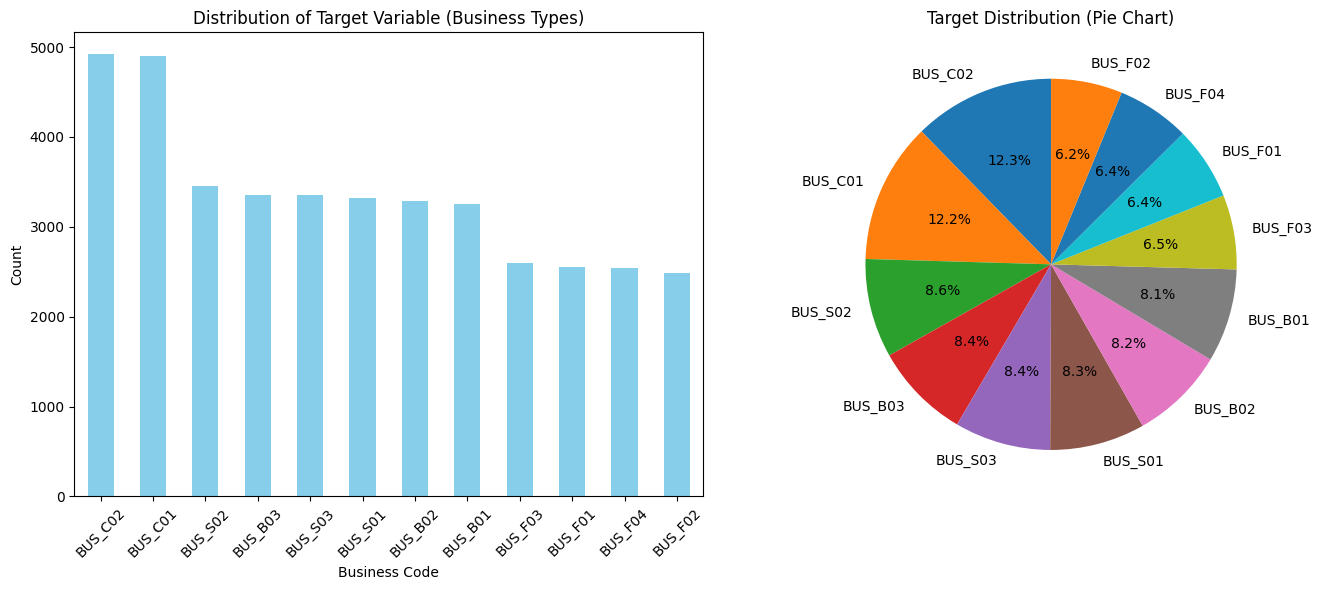


✅ Section 2.1 completed


In [3]:
print("\n" + "="*80)
print("SECTION 2.1: DATASET LOADING AND CHECKING")
print("="*80)

# Define dataset path
DATASET_PATH = '/kaggle/input/datasets/primeoptimuzz/agri-business-idea-dataset/business_idea_dataset_40000.csv'  # Update this path as needed

# Check if dataset exists
if not os.path.exists(DATASET_PATH):
    print(f"❌ Dataset not found at {DATASET_PATH}")
    print("Please provide the correct path.")
    
    # Try to find any CSV file in current directory
    csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
    if csv_files:
        DATASET_PATH = csv_files[0]
        print(f"✅ Found alternative dataset: {DATASET_PATH}")
    else:
        print("❌ No CSV files found in current directory")
        sys.exit(1)
else:
    print(f"✅ Dataset found at {DATASET_PATH}")

# Load dataset
print("\n📂 Loading dataset...")
df = pd.read_csv(DATASET_PATH)
print(f"✅ Dataset loaded successfully with {df.shape[0]:,} rows and {df.shape[1]} columns")

# Display first few rows
print("\n📋 First 5 rows of the dataset:")
print("-"*60)
print(df.head().to_string())

# Display basic information
print("\n📊 Dataset Information:")
print("-"*60)
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Display column data types
print("\n📋 Column Data Types:")
print("-"*60)
dtype_df = pd.DataFrame({
    'Column': df.dtypes.index,
    'Data Type': df.dtypes.values,
    'Non-Null Count': df.count().values,
    'Null Count': df.isnull().sum().values,
    'Unique Values': [df[col].nunique() for col in df.columns]
})
print(dtype_df.to_string(index=False))

# Display statistical summary
print("\n📈 Statistical Summary (Numerical Columns):")
print("-"*60)
numerical_cols = df.select_dtypes(include=[np.number]).columns
print(df[numerical_cols].describe().to_string())

# Display categorical columns info
print("\n📊 Categorical Columns Summary:")
print("-"*60)
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col} (Top 5 values):")
    print(df[col].value_counts().head(5).to_string())

# Check for missing values
print("\n🔍 Missing Values Analysis:")
print("-"*60)
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Count': missing_values.values,
    'Missing Percentage': missing_percent.values
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Percentage', ascending=False)

if len(missing_df) > 0:
    print("⚠️ Missing values detected:")
    print(missing_df.to_string(index=False))
else:
    print("✅ No missing values found in the dataset")

# Check for duplicate rows
duplicates = df.duplicated().sum()
if duplicates > 0:
    print(f"\n⚠️ Found {duplicates:,} duplicate rows ({duplicates/len(df)*100:.2f}%)")
else:
    print(f"\n✅ No duplicate rows found")

# Identify target column
target_column = 'recommended_business_code'
if target_column not in df.columns:
    # Try to find alternative target column
    possible_targets = [col for col in df.columns if 'business' in col.lower() or 'recommended' in col.lower()]
    if possible_targets:
        target_column = possible_targets[0]
        print(f"\nℹ️ Using '{target_column}' as target column instead")
    else:
        print(f"\n⚠️ No target column found. Using first column as target.")
        target_column = df.columns[0]

print(f"\n🎯 Target variable: {target_column}")

# Target variable analysis
print(f"\n📊 Target Variable '{target_column}' Analysis:")
print("-"*60)
target_counts = df[target_column].value_counts()
target_percentages = (target_counts / len(df)) * 100

target_df = pd.DataFrame({
    'Class': target_counts.index,
    'Count': target_counts.values,
    'Percentage': target_percentages.values
})
print(target_df.to_string(index=False))

print(f"\nNumber of classes: {df[target_column].nunique()}")

# Plot target distribution
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
df[target_column].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Target Variable (Business Types)')
plt.xlabel('Business Code')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
df[target_column].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Target Distribution (Pie Chart)')
plt.ylabel('')
plt.tight_layout()
plt.show()

print("\n✅ Section 2.1 completed")

## Section 2.2: Dataset Balance/Imbalance Checking


SECTION 2.2: DATASET BALANCE/IMBALANCE CHECKING

📊 Class Distribution Analysis:
------------------------------------------------------------
  Class  Count  Percentage  Cumulative %
BUS_B01   3251      8.1275        8.1275
BUS_B02   3287      8.2175       16.3450
BUS_B03   3355      8.3875       24.7325
BUS_C01   4896     12.2400       36.9725
BUS_C02   4919     12.2975       49.2700
BUS_F01   2556      6.3900       55.6600
BUS_F02   2482      6.2050       61.8650
BUS_F03   2595      6.4875       68.3525
BUS_F04   2542      6.3550       74.7075
BUS_S01   3317      8.2925       83.0000
BUS_S02   3450      8.6250       91.6250
BUS_S03   3350      8.3750      100.0000

📈 Imbalance Metrics:
------------------------------------------------------------
Number of classes: 12
Minimum class size: 2,482 (BUS_F02)
Maximum class size: 4,919 (BUS_C02)
Average class size: 3333.33
Standard deviation: 824.63
Imbalance ratio (max/min): 1.98
Imbalance ratio (max/avg): 1.48

📊 Imbalance Severity: ✅ LOW 

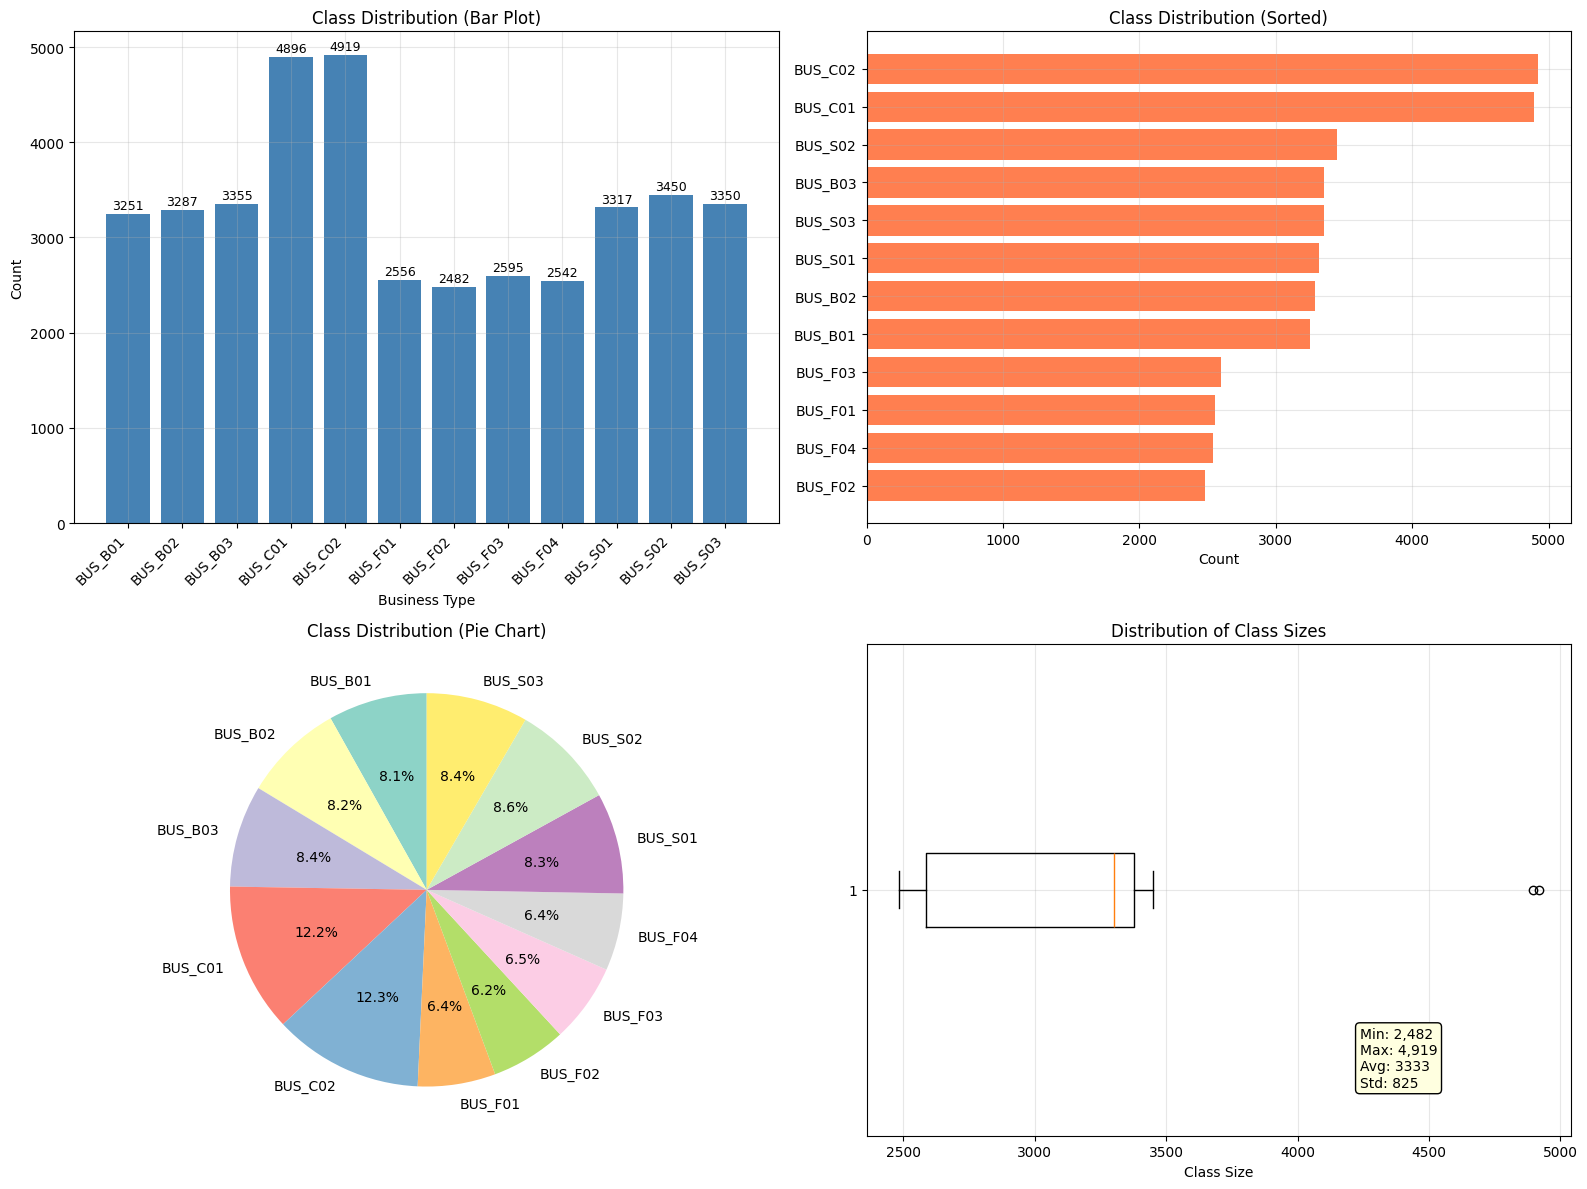


✅ Balance analysis saved to 'balance_analysis.json'

✅ Section 2.2 completed


In [4]:
print("\n" + "="*80)
print("SECTION 2.2: DATASET BALANCE/IMBALANCE CHECKING")
print("="*80)

# Calculate class distribution
class_counts = df[target_column].value_counts().sort_index()
class_percentages = (class_counts / len(df)) * 100

# Create balance analysis dataframe
balance_df = pd.DataFrame({
    'Class': class_counts.index,
    'Count': class_counts.values,
    'Percentage': class_percentages.values,
    'Cumulative %': class_percentages.cumsum().values
})

print("\n📊 Class Distribution Analysis:")
print("-"*60)
print(balance_df.to_string(index=False))

# Calculate imbalance metrics
n_classes = len(class_counts)
min_class_count = class_counts.min()
max_class_count = class_counts.max()
avg_class_count = class_counts.mean()
std_class_count = class_counts.std()
min_class_name = class_counts.idxmin()
max_class_name = class_counts.idxmax()

# Imbalance ratios
imbalance_ratio_max_min = max_class_count / min_class_count
imbalance_ratio_max_avg = max_class_count / avg_class_count

print("\n📈 Imbalance Metrics:")
print("-"*60)
print(f"Number of classes: {n_classes}")
print(f"Minimum class size: {min_class_count:,} ({min_class_name})")
print(f"Maximum class size: {max_class_count:,} ({max_class_name})")
print(f"Average class size: {avg_class_count:.2f}")
print(f"Standard deviation: {std_class_count:.2f}")
print(f"Imbalance ratio (max/min): {imbalance_ratio_max_min:.2f}")
print(f"Imbalance ratio (max/avg): {imbalance_ratio_max_avg:.2f}")

# Determine imbalance severity
proceed_with_dataset = True
if imbalance_ratio_max_min < 2:
    imbalance_severity = "✅ LOW - Dataset is well balanced"
    recommendation = "No balancing required. Proceed with original dataset."
    balance_status = "BALANCED"
elif imbalance_ratio_max_min < 5:
    imbalance_severity = "⚠️ MEDIUM - Moderate imbalance detected"
    recommendation = "Consider applying balancing techniques for better model performance"
    balance_status = "MODERATELY IMBALANCED"
elif imbalance_ratio_max_min < 10:
    imbalance_severity = "⚠️⚠️ HIGH - Significant imbalance detected"
    recommendation = "Balancing techniques recommended before proceeding"
    balance_status = "HIGHLY IMBALANCED"
    proceed_with_dataset = False
else:
    imbalance_severity = "❌❌ SEVERE - Extreme imbalance detected"
    recommendation = "Balancing techniques mandatory. Consider class reduction or data augmentation."
    balance_status = "SEVERELY IMBALANCED"
    proceed_with_dataset = False

print(f"\n📊 Imbalance Severity: {imbalance_severity}")
print(f"📝 Recommendation: {recommendation}")
print(f"🔄 Proceed with current dataset: {proceed_with_dataset}")

# Visualize class distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Bar plot
axes[0, 0].bar(range(len(class_counts)), class_counts.values, color='steelblue')
axes[0, 0].set_xticks(range(len(class_counts)))
axes[0, 0].set_xticklabels(class_counts.index, rotation=45, ha='right')
axes[0, 0].set_xlabel('Business Type')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Class Distribution (Bar Plot)')
axes[0, 0].grid(True, alpha=0.3)

# Add value labels
for i, v in enumerate(class_counts.values):
    axes[0, 0].text(i, v + 50, str(v), ha='center', fontsize=9)

# Horizontal bar plot (sorted)
sorted_counts = class_counts.sort_values(ascending=True)
axes[0, 1].barh(range(len(sorted_counts)), sorted_counts.values, color='coral')
axes[0, 1].set_yticks(range(len(sorted_counts)))
axes[0, 1].set_yticklabels(sorted_counts.index)
axes[0, 1].set_xlabel('Count')
axes[0, 1].set_title('Class Distribution (Sorted)')
axes[0, 1].grid(True, alpha=0.3)

# Pie chart
axes[1, 0].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', 
               startangle=90, colors=plt.cm.Set3(range(len(class_counts))))
axes[1, 0].set_title('Class Distribution (Pie Chart)')

# Box plot of class sizes
axes[1, 1].boxplot(class_counts.values, vert=False)
axes[1, 1].set_xlabel('Class Size')
axes[1, 1].set_title('Distribution of Class Sizes')
axes[1, 1].grid(True, alpha=0.3)

# Add statistics
stats_text = f"Min: {min_class_count:,}\nMax: {max_class_count:,}\nAvg: {avg_class_count:.0f}\nStd: {std_class_count:.0f}"
axes[1, 1].text(0.7, 0.1, stats_text, transform=axes[1, 1].transAxes,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow"))

plt.tight_layout()
plt.show()

# Save balance analysis
balance_analysis = {
    'balance_status': balance_status,
    'imbalance_ratio': imbalance_ratio_max_min,
    'min_class': {'name': min_class_name, 'count': int(min_class_count)},
    'max_class': {'name': max_class_name, 'count': int(max_class_count)},
    'avg_class_size': float(avg_class_count),
    'proceed_with_dataset': proceed_with_dataset,
    'recommendation': recommendation
}

with open('balance_analysis.json', 'w') as f:
    json.dump(balance_analysis, f, indent=2)

print("\n✅ Balance analysis saved to 'balance_analysis.json'")
print("\n✅ Section 2.2 completed")

## Section 2.3: Dataset Balancing Checking for the Process

In [5]:
"""
========================================================
SECTION 2.3: DATASET BALANCING WITH TARGET GROUPING
========================================================
This section groups similar business types to improve classification.
"""

print("\n" + "="*80)
print("SECTION 2.3: DATASET BALANCING WITH TARGET GROUPING")
print("="*80)

# Load balance analysis
try:
    with open('balance_analysis.json', 'r') as f:
        balance_analysis = json.load(f)
    print("✅ Balance analysis loaded")
except:
    print("⚠️ Using current data")

# Group business types logically
print("\n1️⃣ GROUPING BUSINESS TYPES:")
print("-"*60)

# Create business group mapping
business_group_mapping = {
    # Retail/Wholesale group
    'BUS_B01': 'RETAIL_WHOLESALE',
    'BUS_B02': 'RETAIL_WHOLESALE',
    'BUS_B03': 'RETAIL_WHOLESALE',
    'BUS_S01': 'RETAIL_WHOLESALE',
    'BUS_S02': 'RETAIL_WHOLESALE',
    'BUS_S03': 'RETAIL_WHOLESALE',
    
    # Farming group
    'BUS_F01': 'FARMING',
    'BUS_F02': 'FARMING',
    'BUS_F03': 'FARMING',
    'BUS_F04': 'FARMING',
    
    # Consumer group
    'BUS_C01': 'CONSUMER',
    'BUS_C02': 'CONSUMER'
}

# Create reverse mapping for decoding
reverse_group_mapping = {
    'RETAIL_WHOLESALE': ['BUS_B01', 'BUS_B02', 'BUS_B03', 'BUS_S01', 'BUS_S02', 'BUS_S03'],
    'FARMING': ['BUS_F01', 'BUS_F02', 'BUS_F03', 'BUS_F04'],
    'CONSUMER': ['BUS_C01', 'BUS_C02']
}

# Apply grouping
df['business_group'] = df[target_column].map(business_group_mapping)

print("\n📊 Business Group Distribution:")
group_dist = df['business_group'].value_counts()
for group, count in group_dist.items():
    print(f"  {group}: {count:,} samples ({count/len(df)*100:.1f}%)")

print(f"\n✅ Reduced from 12 classes to {len(group_dist)} logical groups")

# Check balance of grouped target
print("\n2️⃣ CHECKING GROUP BALANCE:")
print("-"*60)

group_counts = df['business_group'].value_counts()
min_group = group_counts.min()
max_group = group_counts.max()
imbalance_ratio = max_group / min_group

print(f"  RETAIL_WHOLESALE: {group_counts.get('RETAIL_WHOLESALE', 0):,}")
print(f"  FARMING: {group_counts.get('FARMING', 0):,}")
print(f"  CONSUMER: {group_counts.get('CONSUMER', 0):,}")
print(f"  Imbalance ratio: {imbalance_ratio:.2f}")

if imbalance_ratio < 2:
    print("✅ Groups are well balanced")
else:
    print("⚠️ Groups are imbalanced, will balance")

# Update target column to grouped version
original_target = target_column
target_column = 'business_group'
print(f"\n✅ Using '{target_column}' as new target")

# Save mapping for later use
group_mapping = {
    'business_group_mapping': business_group_mapping,
    'reverse_group_mapping': reverse_group_mapping
}

with open('business_group_mapping.json', 'w') as f:
    json.dump(group_mapping, f, indent=2)

print("✅ Business group mapping saved")

# Now proceed with balancing if needed
X = df.drop(columns=[original_target, target_column])
y = df[target_column]

if imbalance_ratio > 2:
    print("\n3️⃣ BALANCING GROUPS:")
    print("-"*60)
    
    # Apply SMOTE on grouped target
    try:
        smote = SMOTE(random_state=42)
        X_balanced, y_balanced = smote.fit_resample(
            X.select_dtypes(include=[np.number]), y
        )
        print("✅ SMOTE balancing completed")
        
        # Create balanced dataframe
        balanced_df = pd.concat([
            pd.DataFrame(X_balanced, columns=X.select_dtypes(include=[np.number]).columns),
            pd.Series(y_balanced, name=target_column)
        ], axis=1)
        
        # Add back original target for reference
        balanced_df[original_target] = 'MIXED'  # Placeholder
        
        print(f"\n📊 Original dataset: {len(df):,}")
        print(f"📊 Balanced dataset: {len(balanced_df):,}")
        
        df = balanced_df.copy()
        
    except Exception as e:
        print(f"⚠️ SMOTE failed: {e}")
        print("Proceeding with original grouped data")
else:
    print("\n✅ Groups already balanced, skipping SMOTE")

print(f"\n📊 Final dataset shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print("\n📊 Final group distribution:")
print(df[target_column].value_counts())

# Save balanced dataset info
balance_info = {
    'final_size': len(df),
    'group_distribution': df[target_column].value_counts().to_dict(),
    'group_mapping': business_group_mapping
}

with open('balanced_dataset_info.json', 'w') as f:
    json.dump(balance_info, f, indent=2)

print("\n✅ Section 2.3 completed")


SECTION 2.3: DATASET BALANCING WITH TARGET GROUPING
✅ Balance analysis loaded

1️⃣ GROUPING BUSINESS TYPES:
------------------------------------------------------------

📊 Business Group Distribution:
  RETAIL_WHOLESALE: 20,010 samples (50.0%)
  FARMING: 10,175 samples (25.4%)
  CONSUMER: 9,815 samples (24.5%)

✅ Reduced from 12 classes to 3 logical groups

2️⃣ CHECKING GROUP BALANCE:
------------------------------------------------------------
  RETAIL_WHOLESALE: 20,010
  FARMING: 10,175
  CONSUMER: 9,815
  Imbalance ratio: 2.04
⚠️ Groups are imbalanced, will balance

✅ Using 'business_group' as new target
✅ Business group mapping saved

3️⃣ BALANCING GROUPS:
------------------------------------------------------------
✅ SMOTE balancing completed

📊 Original dataset: 40,000
📊 Balanced dataset: 60,030

📊 Final dataset shape: 60,030 rows, 25 columns

📊 Final group distribution:
business_group
RETAIL_WHOLESALE    20010
CONSUMER            20010
FARMING             20010
Name: count, dty

# Section 3: 1st Data Preprocessing

In [6]:

print("\n" + "="*80)
print("SECTION 3: FIRST DATA PREPROCESSING")
print("="*80)

# Create a copy of the dataframe
df_processed = df.copy()
print(f"📊 Initial dataset shape: {df_processed.shape[0]:,} rows, {df_processed.shape[1]} columns")

# 1. Handle missing values
print("\n1️⃣ HANDLING MISSING VALUES:")
print("-"*60)

missing_before = df_processed.isnull().sum().sum()
print(f"Missing values before: {missing_before}")

# For numerical columns - fill with median
numerical_cols = df_processed.select_dtypes(include=[np.number]).columns.tolist()
for col in numerical_cols:
    if df_processed[col].isnull().sum() > 0:
        median_val = df_processed[col].median()
        df_processed[col].fillna(median_val, inplace=True)
        print(f"  ✓ Filled '{col}' with median: {median_val:.2f}")

# For categorical columns - fill with mode
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    if df_processed[col].isnull().sum() > 0:
        mode_val = df_processed[col].mode()[0] if len(df_processed[col].mode()) > 0 else 'unknown'
        df_processed[col].fillna(mode_val, inplace=True)
        print(f"  ✓ Filled '{col}' with mode: {mode_val}")

missing_after = df_processed.isnull().sum().sum()
print(f"Missing values after: {missing_after}")
print(f"✅ Missing values handled: {missing_before - missing_after}")

# 2. Handle duplicates
print("\n2️⃣ HANDLING DUPLICATES:")
print("-"*60)

duplicates_before = df_processed.duplicated().sum()
print(f"Duplicate rows before: {duplicates_before:,}")

df_processed.drop_duplicates(inplace=True)

duplicates_after = df_processed.duplicated().sum()
rows_removed = duplicates_before - duplicates_after
print(f"Duplicate rows after: {duplicates_after}")
print(f"✅ Rows removed: {rows_removed:,} ({rows_removed/len(df_processed)*100:.2f}% of data)")

# 3. Handle outliers using IQR method
print("\n3️⃣ HANDLING OUTLIERS (IQR Method):")
print("-"*60)

outlier_counts = {}
outlier_stats = []

for col in numerical_cols:
    if col in df_processed.columns:
        Q1 = df_processed[col].quantile(0.25)
        Q3 = df_processed[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df_processed[(df_processed[col] < lower_bound) | (df_processed[col] > upper_bound)]
        outlier_count = len(outliers)
        outlier_percent = (outlier_count / len(df_processed)) * 100
        outlier_counts[col] = outlier_count
        
        if outlier_count > 0:
            outlier_stats.append({
                'Column': col,
                'Outliers': outlier_count,
                'Percentage': f"{outlier_percent:.2f}%",
                'Lower Bound': f"{lower_bound:.2f}",
                'Upper Bound': f"{upper_bound:.2f}"
            })
            # Cap outliers instead of removing
            df_processed[col] = df_processed[col].clip(lower_bound, upper_bound)

if outlier_stats:
    outlier_df = pd.DataFrame(outlier_stats)
    print(outlier_df.to_string(index=False))
else:
    print("✅ No outliers detected")

total_outliers = sum(outlier_counts.values())
print(f"Total outliers handled: {total_outliers:,}")

# 4. Data type verification and conversion
print("\n4️⃣ DATA TYPE VERIFICATION:")
print("-"*60)

# Convert date columns to datetime
date_columns = [col for col in df_processed.columns if 'date' in col.lower() or 'timestamp' in col.lower()]
for col in date_columns:
    try:
        df_processed[col] = pd.to_datetime(df_processed[col])
        print(f"  ✓ Converted '{col}' to datetime")
    except:
        print(f"  ⚠️ Could not convert '{col}' to datetime")

# Ensure numerical columns are float/int
for col in numerical_cols:
    if col in df_processed.columns:
        if df_processed[col].dtype not in ['int64', 'float64']:
            try:
                df_processed[col] = pd.to_numeric(df_processed[col])
                print(f"  ✓ Converted '{col}' to numeric")
            except:
                print(f"  ⚠️ Could not convert '{col}' to numeric")

# 5. Feature validation
print("\n5️⃣ FEATURE VALIDATION:")
print("-"*60)

# Check for constant columns
constant_cols = [col for col in df_processed.columns if df_processed[col].nunique() == 1]
if constant_cols:
    print(f"⚠️ Found constant columns: {constant_cols}")
    df_processed.drop(columns=constant_cols, inplace=True)
    print(f"  ✓ Removed {len(constant_cols)} constant columns")

# Check for columns with too many missing values
high_missing = [col for col in df_processed.columns if df_processed[col].isnull().sum() / len(df_processed) > 0.5]
if high_missing:
    print(f"⚠️ Found columns with >50% missing: {high_missing}")
    df_processed.drop(columns=high_missing, inplace=True)
    print(f"  ✓ Removed {len(high_missing)} high-missing columns")

# 6. Final dataset info
print("\n6️⃣ FINAL DATASET INFORMATION:")
print("-"*60)
print(f"Final shape: {df_processed.shape[0]:,} rows, {df_processed.shape[1]} columns")
print(f"Memory usage: {df_processed.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Display data types after preprocessing
dtype_summary = pd.DataFrame({
    'Column': df_processed.dtypes.index,
    'Data Type': df_processed.dtypes.values,
    'Unique Values': [df_processed[col].nunique() for col in df_processed.columns]
})
print("\n📊 Data Types After Preprocessing:")
print(dtype_summary.to_string(index=False))

# Save preprocessed data
df_processed.to_csv('business_idea_preprocessed.csv', index=False)
print("\n✅ Preprocessed data saved to 'business_idea_preprocessed.csv'")

# Save preprocessing metadata with proper type conversion
print("\n💾 Saving preprocessing metadata...")

# Convert numpy types to Python native types for JSON serialization
preprocessing_metadata = {
    'original_shape': [int(df.shape[0]), int(df.shape[1])],
    'final_shape': [int(df_processed.shape[0]), int(df_processed.shape[1])],
    'rows_removed': int(rows_removed),
    'outliers_handled': int(total_outliers),
    'constant_columns_removed': [str(col) for col in constant_cols] if constant_cols else [],
    'high_missing_columns_removed': [str(col) for col in high_missing] if high_missing else [],
    'numerical_columns': [str(col) for col in numerical_cols if col in df_processed.columns],
    'categorical_columns': [str(col) for col in categorical_cols if col in df_processed.columns],
    'missing_values_handled': int(missing_before - missing_after)
}

# Convert any remaining numpy types to Python native types
def convert_to_serializable(obj):
    if isinstance(obj, (np.int64, np.int32, np.int16, np.int8)):
        return int(obj)
    elif isinstance(obj, (np.float64, np.float32, np.float16)):
        return float(obj)
    elif isinstance(obj, np.bool_):
        return bool(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, pd.Timestamp):
        return obj.isoformat()
    elif isinstance(obj, pd.Series):
        return obj.tolist()
    else:
        return obj

# Apply conversion recursively
def convert_dict(obj):
    if isinstance(obj, dict):
        return {key: convert_dict(value) for key, value in obj.items()}
    elif isinstance(obj, list):
        return [convert_dict(item) for item in obj]
    else:
        return convert_to_serializable(obj)

preprocessing_metadata = convert_dict(preprocessing_metadata)

with open('preprocessing_metadata.json', 'w') as f:
    json.dump(preprocessing_metadata, f, indent=2)

print("✅ Preprocessing metadata saved to 'preprocessing_metadata.json'")

# Also save a quick summary as text file for easy viewing
with open('preprocessing_summary.txt', 'w') as f:
    f.write("PREPROCESSING SUMMARY\n")
    f.write("="*50 + "\n")
    f.write(f"Initial shape: {df.shape[0]:,} rows, {df.shape[1]} columns\n")
    f.write(f"Final shape: {df_processed.shape[0]:,} rows, {df_processed.shape[1]} columns\n")
    f.write(f"Rows removed: {rows_removed:,}\n")
    f.write(f"Outliers handled: {total_outliers:,}\n")
    f.write(f"Constant columns removed: {len(constant_cols)}\n")
    f.write(f"Missing values handled: {missing_before - missing_after}\n")

print("✅ Preprocessing summary saved to 'preprocessing_summary.txt'")
print("\n✅ Section 3 completed")


SECTION 3: FIRST DATA PREPROCESSING
📊 Initial dataset shape: 60,030 rows, 25 columns

1️⃣ HANDLING MISSING VALUES:
------------------------------------------------------------
Missing values before: 0
Missing values after: 0
✅ Missing values handled: 0

2️⃣ HANDLING DUPLICATES:
------------------------------------------------------------
Duplicate rows before: 0
Duplicate rows after: 0
✅ Rows removed: 0 (0.00% of data)

3️⃣ HANDLING OUTLIERS (IQR Method):
------------------------------------------------------------
                 Column  Outliers Percentage Lower Bound Upper Bound
         monthly_income      1737      2.89%    -1795.59   249970.66
      children_under_16      1492      2.49%       -3.00        5.00
            loan_amount      1256      2.09% -2822040.48  4703400.79
       cultivation_risk      5753      9.58%       -0.25        0.41
          optimal_month      2318      3.86%       -6.00       10.00
      feasibility_score       128      0.21%        0.14        

# Section 4: Exploratory Data Analysis (EDA) and Learning Method Selection


## Section 4.1: Exploratory Data Analysis (EDA


SECTION 4.1: EXPLORATORY DATA ANALYSIS (EDA)

1️⃣ NUMERICAL FEATURES DISTRIBUTION:
------------------------------------------------------------
Total numerical features: 23


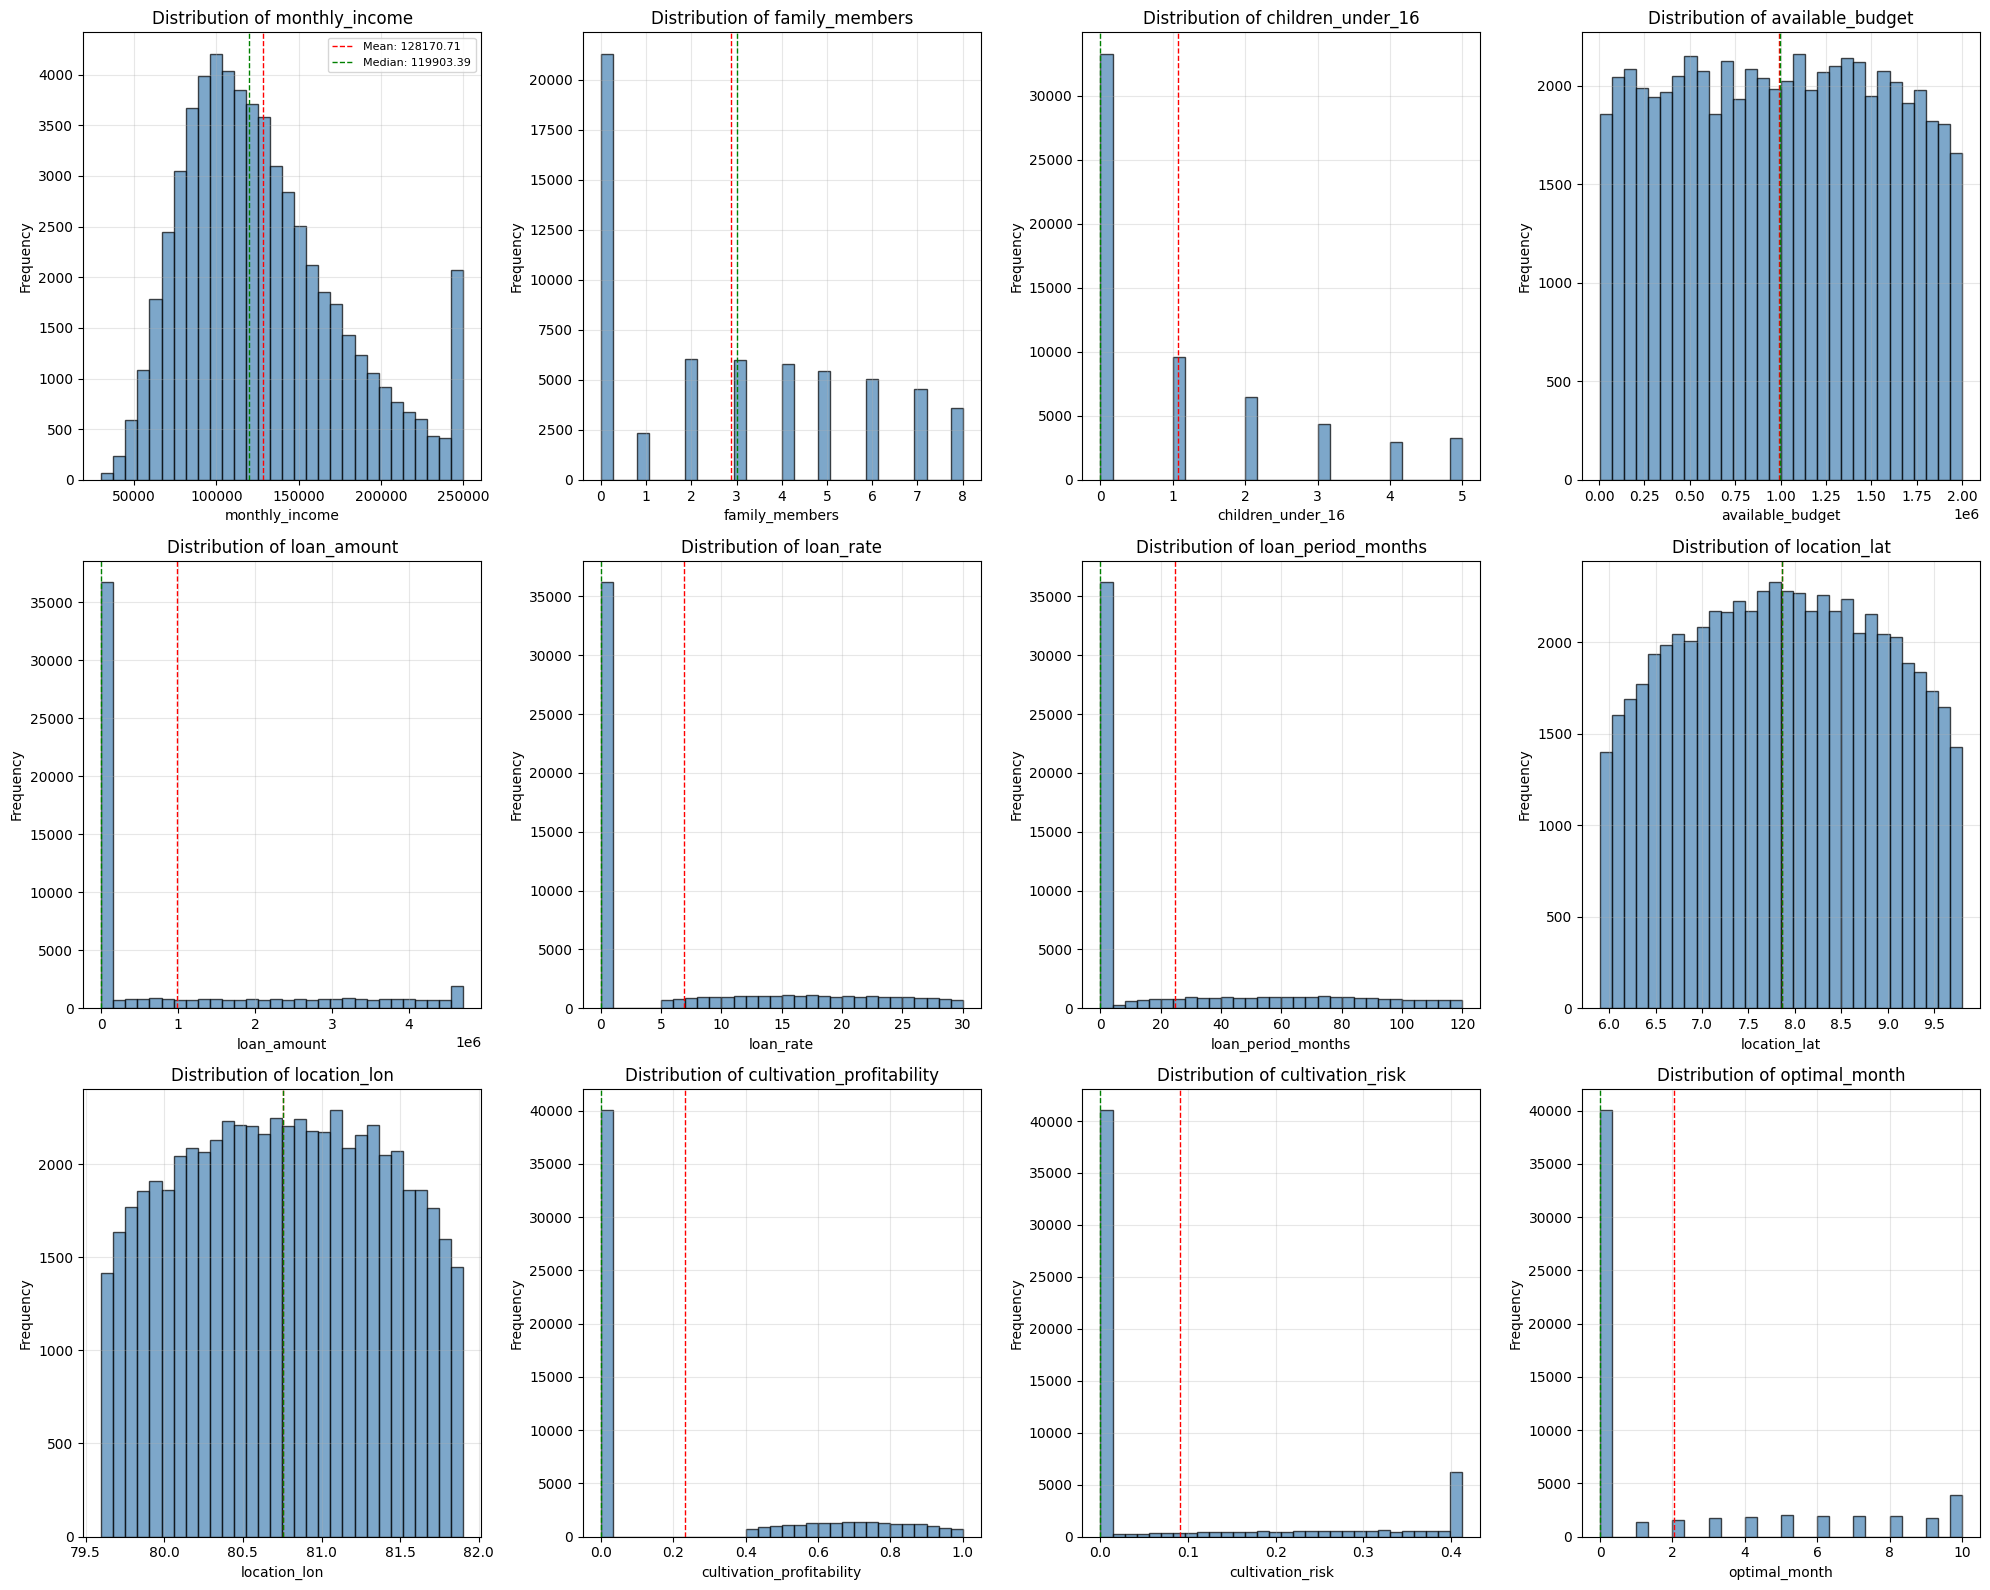


2️⃣ CATEGORICAL FEATURES ANALYSIS:
------------------------------------------------------------
Total categorical features: 1

📊 'business_group' - Top 10 categories:
        Category  Count Percentage
RETAIL_WHOLESALE  20010     33.33%
        CONSUMER  20010     33.33%
         FARMING  20010     33.33%


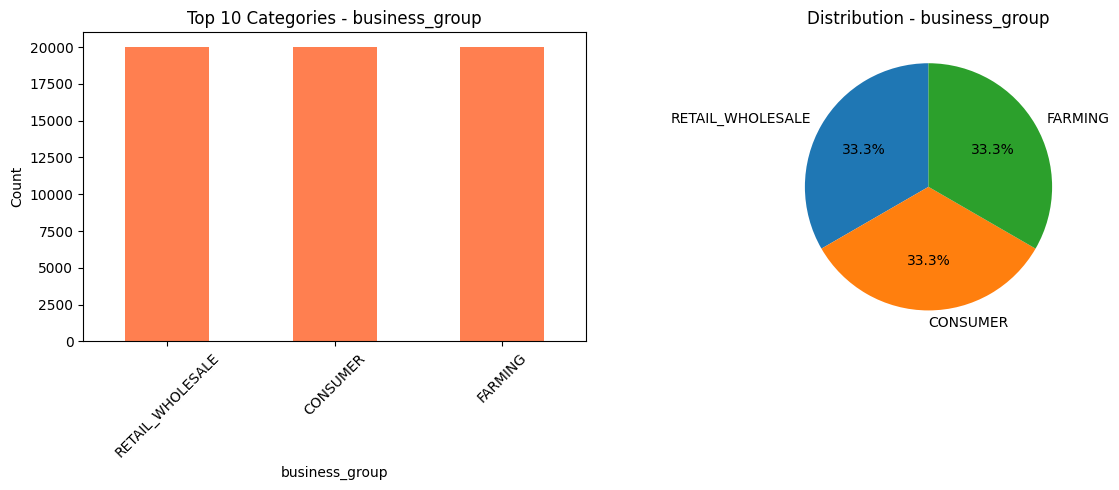


3️⃣ CORRELATION ANALYSIS:
------------------------------------------------------------


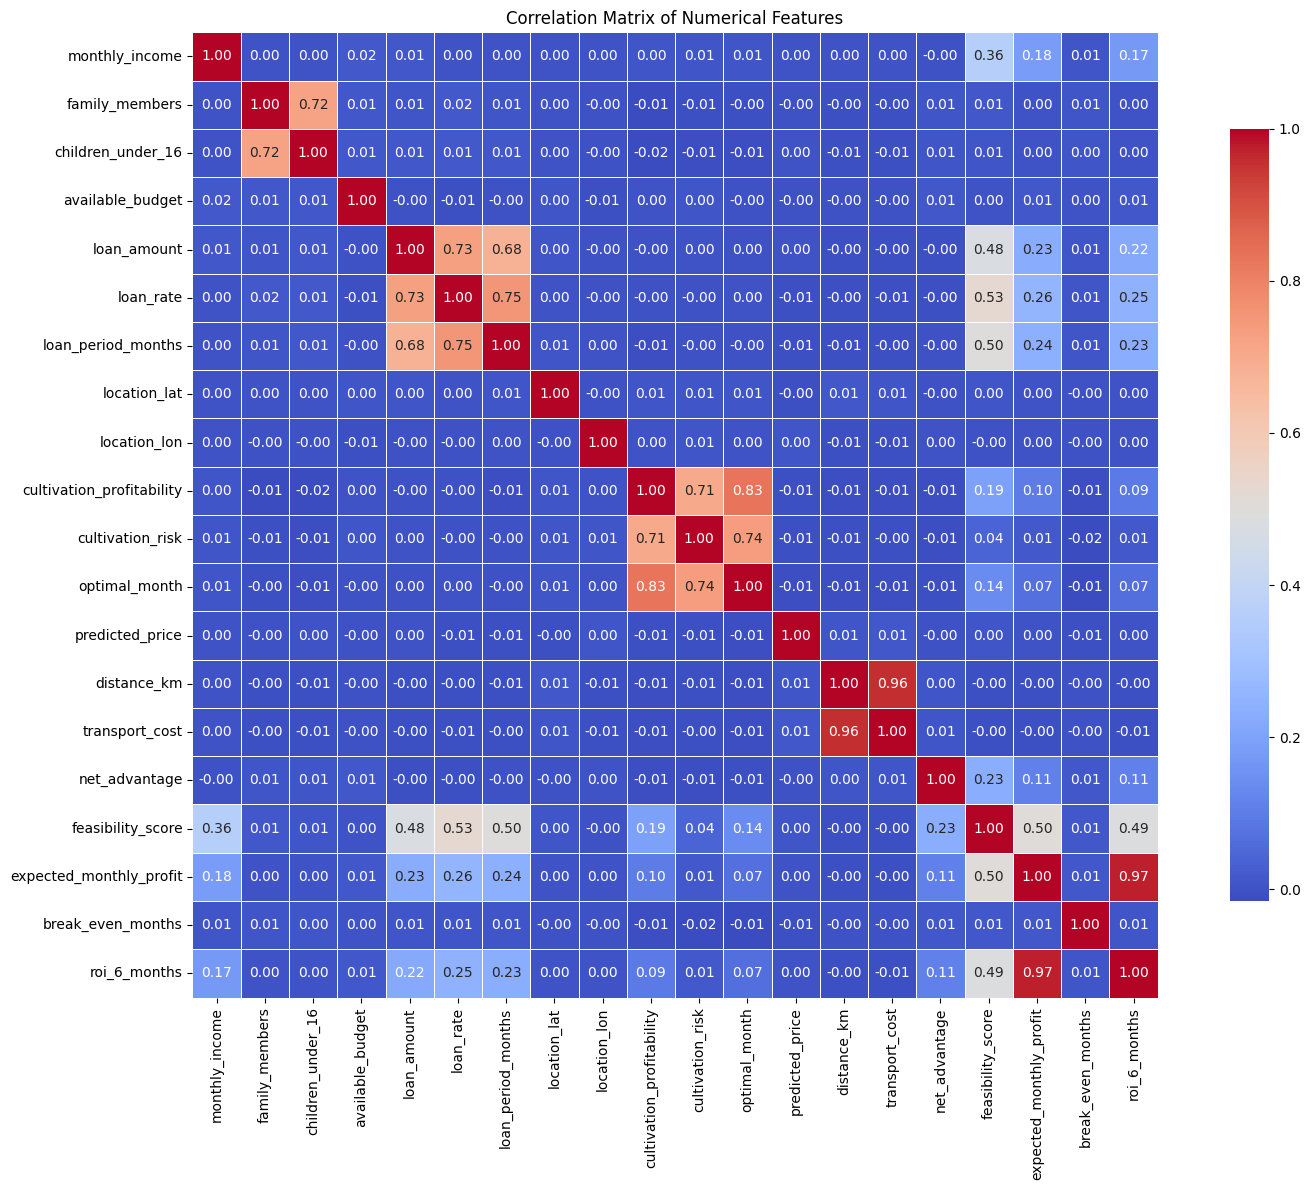


⚠️ Highly correlated features (|r| > 0.8):
                Feature 1      Feature 2 Correlation
  expected_monthly_profit   roi_6_months      0.9745
              distance_km transport_cost      0.9596
cultivation_profitability  optimal_month      0.8318

4️⃣ TARGET VARIABLE ANALYSIS:
------------------------------------------------------------

5️⃣ DATA RELIABILITY ASSESSMENT:
------------------------------------------------------------

📊 Data Reliability Score: 100/100 - EXCELLENT
✅ No significant reliability issues found

6️⃣ SUMMARY STATISTICS:
------------------------------------------------------------
  Total samples: 60,030
  Numerical features: 23
  Categorical features: 1
  Target classes: N/A
  Missing values: 0
  Memory usage: 13.93 MB
  Reliability score: 100/100
  Reliability level: EXCELLENT

💾 Saving EDA results...
✅ EDA results saved to 'eda_results.json'
✅ EDA summary saved to 'eda_summary.txt'

✅ Section 4.1 completed


In [7]:


# Import necessary libraries if not already imported
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*80)
print("SECTION 4.1: EXPLORATORY DATA ANALYSIS (EDA)")
print("="*80)

# Create a figure for multiple plots
fig = plt.figure(figsize=(20, 16))

# 1. Numerical Features Distribution
print("\n1️⃣ NUMERICAL FEATURES DISTRIBUTION:")
print("-"*60)

numerical_cols = df_processed.select_dtypes(include=[np.number]).columns.tolist()
print(f"Total numerical features: {len(numerical_cols)}")

# Remove target from numerical if present
target_column = 'recommended_business_code'  # Define target column
if target_column in numerical_cols:
    numerical_cols.remove(target_column)

# Plot distributions for first 12 numerical features
n_plots = min(12, len(numerical_cols))
n_rows = (n_plots + 3) // 4

for i, col in enumerate(numerical_cols[:12]):
    plt.subplot(3, 4, i+1)
    df_processed[col].hist(bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    
    # Add statistics
    mean_val = df_processed[col].mean()
    median_val = df_processed[col].median()
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=1, label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='--', linewidth=1, label=f'Median: {median_val:.2f}')
    if i == 0:
        plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

# 2. Categorical Features Analysis
print("\n2️⃣ CATEGORICAL FEATURES ANALYSIS:")
print("-"*60)

categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
if target_column in categorical_cols:
    categorical_cols.remove(target_column)

print(f"Total categorical features: {len(categorical_cols)}")

if len(categorical_cols) > 0:
    for col in categorical_cols[:5]:  # Limit to first 5 for display
        print(f"\n📊 '{col}' - Top 10 categories:")
        value_counts = df_processed[col].value_counts()
        percent_counts = (value_counts / len(df_processed)) * 100
        
        cat_df = pd.DataFrame({
            'Category': value_counts.index[:10],
            'Count': value_counts.values[:10],
            'Percentage': [f"{p:.2f}%" for p in percent_counts.values[:10]]
        })
        print(cat_df.to_string(index=False))
        
        # Plot
        plt.figure(figsize=(12, 5))
        
        plt.subplot(1, 2, 1)
        value_counts.head(10).plot(kind='bar', color='coral')
        plt.title(f'Top 10 Categories - {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        
        plt.subplot(1, 2, 2)
        value_counts.head(10).plot(kind='pie', autopct='%1.1f%%', startangle=90)
        plt.title(f'Distribution - {col}')
        plt.ylabel('')
        
        plt.tight_layout()
        plt.show()
else:
    print("✅ No categorical features found (all features are numerical or encoded)")

# 3. Correlation Analysis
print("\n3️⃣ CORRELATION ANALYSIS:")
print("-"*60)

# Select numerical columns for correlation
corr_cols = numerical_cols[:20] if len(numerical_cols) > 20 else numerical_cols
correlation_matrix = df_processed[corr_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

# Find highly correlated features
high_corr_pairs = []
threshold = 0.8

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = abs(correlation_matrix.iloc[i, j])
        if corr_value > threshold:
            high_corr_pairs.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': f"{correlation_matrix.iloc[i, j]:.4f}"
            })

if high_corr_pairs:
    print(f"\n⚠️ Highly correlated features (|r| > {threshold}):")
    corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', ascending=False)
    print(corr_df.to_string(index=False))
else:
    print(f"✅ No features with correlation > {threshold}")

# 4. Target Variable Analysis
print("\n4️⃣ TARGET VARIABLE ANALYSIS:")
print("-"*60)

if target_column in df_processed.columns:
    print(f"Target column: {target_column}")
    print(f"Number of classes: {df_processed[target_column].nunique()}")
    print(f"Data type: {df_processed[target_column].dtype}")
    
    # Target distribution
    target_counts = df_processed[target_column].value_counts()
    target_percentages = (target_counts / len(df_processed)) * 100
    
    target_df = pd.DataFrame({
        'Class': target_counts.index,
        'Count': target_counts.values,
        'Percentage': [f"{p:.2f}%" for p in target_percentages.values]
    })
    print("\nTarget Distribution:")
    print(target_df.to_string(index=False))
    
    # Plot target distribution
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    target_counts.plot(kind='bar', color='steelblue')
    plt.title('Target Variable Distribution')
    plt.xlabel('Business Code')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    
    plt.subplot(1, 2, 2)
    target_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
    plt.title('Target Distribution (Pie Chart)')
    plt.ylabel('')
    
    plt.tight_layout()
    plt.show()
    
    # Target vs numerical features (limit to avoid too many plots)
    if len(numerical_cols) > 0:
        print("\n📊 Target vs Numerical Features (first 12):")
        fig, axes = plt.subplots(3, 4, figsize=(16, 12))
        axes = axes.ravel()
        
        for i, num_col in enumerate(numerical_cols[:12]):
            df_processed.boxplot(column=num_col, by=target_column, ax=axes[i])
            axes[i].set_title(f'{num_col}')
            axes[i].set_xlabel('')
            axes[i].tick_params(axis='x', rotation=45)
        
        # Hide empty subplots
        for j in range(i+1, 12):
            axes[j].set_visible(False)
        
        plt.suptitle(f'Feature Distribution by {target_column}', y=1.02)
        plt.tight_layout()
        plt.show()

# 5. Data Reliability Assessment
print("\n5️⃣ DATA RELIABILITY ASSESSMENT:")
print("-"*60)

reliability_score = 100
reliability_issues = []

# Check for outliers using Z-score
try:
    if len(numerical_cols) > 0:
        z_scores = np.abs(stats.zscore(df_processed[numerical_cols].dropna()))
        outliers_z = (z_scores > 3).sum().sum()
        if outliers_z > 0:
            reliability_score -= 5
            reliability_issues.append(f"Found {outliers_z:,} extreme outliers (Z-score > 3)")
except Exception as e:
    print(f"⚠️ Could not calculate Z-scores: {e}")

# Check for class balance
if target_column in df_processed.columns:
    value_counts = df_processed[target_column].value_counts()
    max_count = value_counts.max()
    min_count = value_counts.min()
    class_balance_ratio = max_count / min_count if min_count > 0 else float('inf')
    
    if class_balance_ratio > 3:
        reliability_score -= 10
        reliability_issues.append(f"Class imbalance detected (ratio: {class_balance_ratio:.2f})")

# Check for missing values
missing_count = df_processed.isnull().sum().sum()
if missing_count > 0:
    reliability_score -= 5
    reliability_issues.append(f"Still have {missing_count:,} missing values")

# Check data consistency
for col in numerical_cols[:10]:  # Check first 10 numerical columns
    if col in df_processed.columns:
        if df_processed[col].min() < 0 and col not in ['net_advantage']:
            # Some features naturally have negatives
            if df_processed[col].min() < -1000:  # Significant negative values
                reliability_score -= 2
                reliability_issues.append(f"Column '{col}' has significant negative values (min: {df_processed[col].min():.2f})")

# Check for constant columns
constant_check = [col for col in df_processed.columns if df_processed[col].nunique() == 1]
if constant_check:
    reliability_score -= 10
    reliability_issues.append(f"Found {len(constant_check)} constant columns")

# Determine reliability level
if reliability_score >= 90:
    reliability_level = "EXCELLENT"
elif reliability_score >= 75:
    reliability_level = "GOOD"
elif reliability_score >= 60:
    reliability_level = "FAIR"
else:
    reliability_level = "POOR"

print(f"\n📊 Data Reliability Score: {reliability_score}/100 - {reliability_level}")

if reliability_issues:
    print("\n⚠️ Reliability Issues Found:")
    for issue in reliability_issues:
        print(f"  • {issue}")
else:
    print("✅ No significant reliability issues found")

# 6. Summary Statistics
print("\n6️⃣ SUMMARY STATISTICS:")
print("-"*60)

summary_stats = {
    'Total samples': f"{len(df_processed):,}",
    'Numerical features': len(numerical_cols),
    'Categorical features': len(categorical_cols),
    'Target classes': df_processed[target_column].nunique() if target_column in df_processed.columns else 'N/A',
    'Missing values': f"{df_processed.isnull().sum().sum():,}",
    'Memory usage': f"{df_processed.memory_usage(deep=True).sum() / 1024**2:.2f} MB",
    'Reliability score': f"{reliability_score}/100",
    'Reliability level': reliability_level
}

for key, value in summary_stats.items():
    print(f"  {key}: {value}")

# Save EDA results with proper type conversion
print("\n💾 Saving EDA results...")

def convert_to_serializable(obj):
    """Convert numpy/pandas types to Python native types for JSON serialization"""
    if isinstance(obj, (np.int64, np.int32, np.int16, np.int8)):
        return int(obj)
    elif isinstance(obj, (np.float64, np.float32, np.float16)):
        return float(obj)
    elif isinstance(obj, np.bool_):
        return bool(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, pd.Series):
        return obj.tolist()
    elif isinstance(obj, pd.Timestamp):
        return obj.isoformat()
    elif isinstance(obj, (pd.DataFrame, pd.Index)):
        return str(obj)
    else:
        return obj

def convert_dict(obj):
    """Recursively convert dictionary values to JSON serializable types"""
    if isinstance(obj, dict):
        return {key: convert_dict(value) for key, value in obj.items()}
    elif isinstance(obj, list):
        return [convert_dict(item) for item in obj]
    elif isinstance(obj, tuple):
        return tuple(convert_dict(list(obj)))
    else:
        return convert_to_serializable(obj)

# Prepare EDA results with proper type conversion
eda_results = {
    'numerical_features': [str(col) for col in numerical_cols],
    'categorical_features': [str(col) for col in categorical_cols],
    'high_correlations': [
        {
            'Feature 1': str(pair['Feature 1']),
            'Feature 2': str(pair['Feature 2']),
            'Correlation': float(pair['Correlation']) if isinstance(pair['Correlation'], str) else pair['Correlation']
        }
        for pair in high_corr_pairs
    ],
    'reliability_score': int(reliability_score),
    'reliability_level': reliability_level,
    'reliability_issues': [str(issue) for issue in reliability_issues],
    'summary_stats': {k: str(v) for k, v in summary_stats.items()},
    'target_distribution': {
        str(k): int(v) for k, v in df_processed[target_column].value_counts().to_dict().items()
    } if target_column in df_processed.columns else {}
}

# Convert to JSON serializable
eda_results = convert_dict(eda_results)

with open('eda_results.json', 'w') as f:
    json.dump(eda_results, f, indent=2)

print("✅ EDA results saved to 'eda_results.json'")

# Also save a quick summary as text file
with open('eda_summary.txt', 'w') as f:
    f.write("EXPLORATORY DATA ANALYSIS SUMMARY\n")
    f.write("="*50 + "\n")
    f.write(f"Total samples: {len(df_processed):,}\n")
    f.write(f"Numerical features: {len(numerical_cols)}\n")
    f.write(f"Categorical features: {len(categorical_cols)}\n")
    f.write(f"Target classes: {df_processed[target_column].nunique() if target_column in df_processed.columns else 'N/A'}\n")
    f.write(f"Reliability score: {reliability_score}/100 - {reliability_level}\n")
    if reliability_issues:
        f.write("\nReliability Issues:\n")
        for issue in reliability_issues:
            f.write(f"  • {issue}\n")

print("✅ EDA summary saved to 'eda_summary.txt'")
print("\n✅ Section 4.1 completed")

## Section 4.2: Learning Method Selection with Model Approach Selection

In [8]:

print("\n" + "="*80)
print("SECTION 4.2: LEARNING METHOD SELECTION")
print("="*80)

# Load previous section outputs
try:
    with open('eda_results.json', 'r') as f:
        eda_results = json.load(f)
    print("✅ Loaded EDA results successfully")
except:
    print("⚠️ Could not load EDA results. Using current data.")
    eda_results = {}

# 1. Problem Analysis
print("\n1️⃣ PROBLEM ANALYSIS:")
print("-"*60)

if target_column in df_processed.columns:
    target_type = df_processed[target_column].dtype
    target_nunique = df_processed[target_column].nunique()
    
    print(f"Target variable: {target_column}")
    print(f"Target data type: {target_type}")
    print(f"Number of unique values: {target_nunique}")
    
    # Determine problem type
    if target_type in ['int64', 'float64'] and target_nunique > 20:
        problem_type = "Regression"
        print("✓ Problem type: Regression (continuous target)")
    elif target_type in ['object', 'category'] or target_nunique <= 20:
        problem_type = "Classification"
        if target_nunique == 2:
            print("✓ Problem type: Binary Classification")
        else:
            print(f"✓ Problem type: Multi-class Classification ({target_nunique} classes)")
    else:
        problem_type = "Multi-output"
        print("✓ Problem type: Multi-output (multiple target variables)")
else:
    print("⚠️ Target column not found, analyzing available data")
    problem_type = "Unsupervised"
    print("✓ Problem type: Unsupervised (no target variable)")

# 2. Learning Method Determination
print("\n2️⃣ LEARNING METHOD DETERMINATION:")
print("-"*60)

has_labels = target_column in df_processed.columns

if has_labels:
    print("✓ Labeled data available → SUPERVISED LEARNING")
    learning_method = "Supervised"
    
    # Determine sub-category
    if problem_type == "Classification":
        if target_nunique == 2:
            sub_type = "Binary Classification"
        else:
            sub_type = "Multi-class Classification"
    elif problem_type == "Regression":
        sub_type = "Regression"
    else:
        sub_type = "Multi-task Learning"
    
    print(f"✓ Sub-type: {sub_type}")
    
else:
    print("✓ No labeled data → UNSUPERVISED LEARNING")
    learning_method = "Unsupervised"
    
    # Determine sub-category
    n_numerical = len(df_processed.select_dtypes(include=[np.number]).columns)
    if n_numerical > 5:
        sub_type = "Clustering / Dimensionality Reduction"
    else:
        sub_type = "Pattern Discovery"
    
    print(f"✓ Sub-type: {sub_type}")

# 3. Justification for Selection
print("\n3️⃣ JUSTIFICATION FOR SELECTION:")
print("-"*60)

reasons = []

if learning_method == "Supervised":
    reasons.append("1. Dataset contains labeled target variable indicating business types")
    reasons.append("2. Goal is to predict business recommendations based on user features")
    reasons.append("3. Historical success data available for model validation")
    reasons.append("4. Clear input-output mapping exists in the domain")
    
    if sub_type == "Multi-class Classification":
        reasons.append(f"5. Target has {target_nunique} distinct business types to predict")
    elif sub_type == "Regression":
        reasons.append("5. Need to predict continuous values (feasibility scores, profits)")
else:
    reasons.append("1. No labeled target variable available")
    reasons.append("2. Need to discover natural groupings of users/businesses")
    reasons.append("3. Exploring patterns in agricultural business data")
    reasons.append("4. Can be used for customer segmentation")

for reason in reasons:
    print(reason)

# 4. Data Requirements Check
print("\n4️⃣ DATA REQUIREMENTS CHECK:")
print("-"*60)

requirements_met = True

if learning_method == "Supervised":
    if sub_type == "Multi-class Classification":
        min_samples_per_class = 100
        class_sizes = df_processed[target_column].value_counts()
        min_class = class_sizes.min()
        max_class = class_sizes.max()
        
        print(f"Minimum class size: {min_class:,}")
        print(f"Maximum class size: {max_class:,}")
        print(f"Class imbalance ratio: {max_class/min_class:.2f}")
        
        if min_class < min_samples_per_class:
            print(f"⚠️ Warning: Some classes have fewer than {min_samples_per_class} samples")
            print("   Recommendation: Consider class merging or data augmentation")
            requirements_met = False
        else:
            print("✅ Class sizes meet minimum requirements")
        
    elif sub_type == "Regression":
        print(f"Total samples: {len(df_processed):,}")
        if len(df_processed) < 1000:
            print("⚠️ Warning: Less than 1000 samples for regression")
            print("   Recommendation: More data needed for reliable regression")
            requirements_met = False
        else:
            print("✅ Sufficient samples for regression")

# 5. Final Decision
print("\n5️⃣ FINAL DECISION:")
print("-"*60)
print(f"✅ Selected Learning Method: {learning_method}")
print(f"✅ Selected Problem Type: {sub_type}")
print(f"✅ Requirements met: {requirements_met}")

# Save selection for later use
learning_method_info = {
    'method': learning_method,
    'problem_type': sub_type,
    'has_labels': has_labels,
    'target_column': target_column if has_labels else None,
    'num_classes': target_nunique if has_labels and sub_type == "Multi-class Classification" else None,
    'requirements_met': requirements_met
}

with open('learning_method_info.json', 'w') as f:
    json.dump(learning_method_info, f, indent=2)

print("\n✅ Learning method info saved to 'learning_method_info.json'")
print("\n✅ Section 4.2 completed")


SECTION 4.2: LEARNING METHOD SELECTION
✅ Loaded EDA results successfully

1️⃣ PROBLEM ANALYSIS:
------------------------------------------------------------
⚠️ Target column not found, analyzing available data
✓ Problem type: Unsupervised (no target variable)

2️⃣ LEARNING METHOD DETERMINATION:
------------------------------------------------------------
✓ No labeled data → UNSUPERVISED LEARNING
✓ Sub-type: Clustering / Dimensionality Reduction

3️⃣ JUSTIFICATION FOR SELECTION:
------------------------------------------------------------
1. No labeled target variable available
2. Need to discover natural groupings of users/businesses
3. Exploring patterns in agricultural business data
4. Can be used for customer segmentation

4️⃣ DATA REQUIREMENTS CHECK:
------------------------------------------------------------

5️⃣ FINAL DECISION:
------------------------------------------------------------
✅ Selected Learning Method: Unsupervised
✅ Selected Problem Type: Clustering / Dimensionali

## Section 4.3: Model Approach Selection

In [9]:

print("\n" + "="*80)
print("SECTION 4.3: MODEL APPROACH SELECTION")
print("="*80)

# Load learning method info
try:
    with open('learning_method_info.json', 'r') as f:
        learning_method_info = json.load(f)
    learning_method = learning_method_info['method']
    sub_type = learning_method_info['problem_type']
    print("✅ Loaded learning method info")
except:
    print("⚠️ Could not load learning method info. Using defaults.")
    learning_method = "Supervised"
    sub_type = "Multi-class Classification"

# Define candidate models based on learning method
candidate_models = []

print("\n1️⃣ CANDIDATE MODELS BY CATEGORY:")
print("-"*60)

if learning_method == "Supervised":
    if sub_type == "Multi-class Classification":
        # Classification models
        candidate_models = [
            {
                'name': 'Logistic Regression',
                'model': LogisticRegression(multi_class='ovr', max_iter=1000, random_state=42),
                'category': 'Linear Classifier',
                'strengths': 'Simple, interpretable, works well with linear separable data',
                'weaknesses': 'Assumes linear relationships, sensitive to outliers'
            },
            {
                'name': 'Decision Tree',
                'model': DecisionTreeClassifier(random_state=42),
                'category': 'Tree-based',
                'strengths': 'Handles non-linear relationships, interpretable',
                'weaknesses': 'Prone to overfitting, unstable'
            },
            {
                'name': 'Random Forest',
                'model': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
                'category': 'Ensemble (Bagging)',
                'strengths': 'Handles non-linearity, feature importance, robust to overfitting',
                'weaknesses': 'Less interpretable, computationally intensive'
            },
            {
                'name': 'Gradient Boosting',
                'model': GradientBoostingClassifier(n_estimators=100, random_state=42),
                'category': 'Ensemble (Boosting)',
                'strengths': 'High accuracy, handles various data types',
                'weaknesses': 'Can overfit, sensitive to parameters'
            },
            {
                'name': 'XGBoost',
                'model': xgb.XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
                'category': 'Gradient Boosting',
                'strengths': 'State-of-the-art performance, handles missing values',
                'weaknesses': 'Complex parameter tuning'
            },
            {
                'name': 'LightGBM',
                'model': lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
                'category': 'Gradient Boosting',
                'strengths': 'Fast training, low memory usage, high accuracy',
                'weaknesses': 'Can overfit on small datasets'
            },
            {
                'name': 'K-Nearest Neighbors',
                'model': KNeighborsClassifier(n_neighbors=5),
                'category': 'Instance-based',
                'strengths': 'Simple, no training phase',
                'weaknesses': 'Slow prediction, sensitive to scale'
            },
            {
                'name': 'Support Vector Machine',
                'model': SVC(probability=True, random_state=42),
                'category': 'Kernel-based',
                'strengths': 'Effective in high-dimensional spaces',
                'weaknesses': 'Long training time, sensitive to parameters'
            },
            {
                'name': 'Naive Bayes',
                'model': GaussianNB(),
                'category': 'Probabilistic',
                'strengths': 'Fast, works well with independent features',
                'weaknesses': 'Assumes feature independence'
            }
        ]
        
    elif sub_type == "Regression":
        # Regression models
        candidate_models = [
            {
                'name': 'Linear Regression',
                'model': LinearRegression(),
                'category': 'Linear',
                'strengths': 'Simple, interpretable',
                'weaknesses': 'Assumes linearity, sensitive to outliers'
            },
            {
                'name': 'Ridge Regression',
                'model': Ridge(alpha=1.0, random_state=42),
                'category': 'Regularized Linear',
                'strengths': 'Handles multicollinearity, prevents overfitting',
                'weaknesses': 'Requires feature scaling'
            },
            {
                'name': 'Lasso Regression',
                'model': Lasso(alpha=1.0, random_state=42),
                'category': 'Regularized Linear',
                'strengths': 'Feature selection, sparse solutions',
                'weaknesses': 'Can be unstable with correlated features'
            },
            {
                'name': 'Decision Tree Regressor',
                'model': DecisionTreeRegressor(random_state=42),
                'category': 'Tree-based',
                'strengths': 'Non-linear, interpretable',
                'weaknesses': 'Prone to overfitting'
            },
            {
                'name': 'Random Forest Regressor',
                'model': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
                'category': 'Ensemble',
                'strengths': 'Robust, handles non-linearity',
                'weaknesses': 'Less interpretable'
            },
            {
                'name': 'Gradient Boosting Regressor',
                'model': GradientBoostingRegressor(n_estimators=100, random_state=42),
                'category': 'Ensemble',
                'strengths': 'High accuracy',
                'weaknesses': 'Can overfit'
            },
            {
                'name': 'XGBoost Regressor',
                'model': xgb.XGBRegressor(n_estimators=100, random_state=42),
                'category': 'Gradient Boosting',
                'strengths': 'State-of-the-art performance',
                'weaknesses': 'Complex tuning'
            },
            {
                'name': 'LightGBM Regressor',
                'model': lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
                'category': 'Gradient Boosting',
                'strengths': 'Fast, accurate',
                'weaknesses': 'Can overfit'
            },
            {
                'name': 'SVR',
                'model': SVR(kernel='rbf'),
                'category': 'Kernel-based',
                'strengths': 'Handles non-linearity',
                'weaknesses': 'Slow, sensitive to parameters'
            }
        ]
else:
    # Unsupervised models
    candidate_models = [
        {
            'name': 'K-Means Clustering',
            'model': None,
            'category': 'Clustering',
            'strengths': 'Simple, scalable',
            'weaknesses': 'Requires specifying k'
        },
        {
            'name': 'Hierarchical Clustering',
            'model': None,
            'category': 'Clustering',
            'strengths': 'No need to specify clusters',
            'weaknesses': 'Computationally intensive'
        },
        {
            'name': 'DBSCAN',
            'model': None,
            'category': 'Density-based',
            'strengths': 'Finds arbitrary shapes, handles noise',
            'weaknesses': 'Sensitive to parameters'
        },
        {
            'name': 'PCA',
            'model': None,
            'category': 'Dimensionality Reduction',
            'strengths': 'Feature reduction, visualization',
            'weaknesses': 'Linear only'
        }
    ]

# Display candidate models
print("\n2️⃣ DETAILED MODEL COMPARISON:")
print("-"*60)

for i, model_info in enumerate(candidate_models, 1):
    print(f"\n{i}. {model_info['name']}")
    print(f"   Category: {model_info['category']}")
    print(f"   Strengths: {model_info['strengths']}")
    print(f"   Weaknesses: {model_info['weaknesses']}")

# 3. Pre-trained Models Consideration
print("\n3️⃣ PRE-TRAINED MODELS CONSIDERATION:")
print("-"*60)

pretrained_models = []

if learning_method == "Supervised" and sub_type == "Multi-class Classification":
    pretrained_models = [
        {
            'name': 'BERT for Text',
            'applicability': 'If user inputs include text descriptions',
            'requirement': 'Text data available'
        },
        {
            'name': 'ResNet for Images',
            'applicability': 'If using images from cultivation data',
            'requirement': 'Image data integration'
        }
    ]
elif learning_method == "Supervised" and sub_type == "Regression":
    pretrained_models = [
        {
            'name': 'Pre-trained Neural Networks',
            'applicability': 'For complex pattern recognition',
            'requirement': 'Large dataset (>10,000 samples)'
        }
    ]

if pretrained_models:
    for model in pretrained_models:
        print(f"\n📌 {model['name']}")
        print(f"   Applicability: {model['applicability']}")
        print(f"   Requirement: {model['requirement']}")
    
    use_pretrained = input("\nDo you want to use any pre-trained models? (y/n): ").strip().lower() == 'y'
    if use_pretrained:
        print("Note: Pre-trained models require additional data preparation")
        print("Will be considered in later sections if applicable")
else:
    print("No pre-trained models applicable for current problem")

# 4. Model Selection Rationale
print("\n4️⃣ MODEL SELECTION RATIONALE:")
print("-"*60)

selection_criteria = [
    "1. Dataset size and complexity",
    "2. Interpretability requirements",
    "3. Computational resources available",
    "4. Deployment constraints",
    "5. Accuracy requirements"
]

for criterion in selection_criteria:
    print(criterion)

# 5. Initial Model Selection for Training
print("\n5️⃣ INITIAL MODEL SELECTION FOR TRAINING:")
print("-"*60)

# Select 5-6 representative models for initial comparison
selected_for_training = []

if learning_method == "Supervised" and sub_type == "Multi-class Classification":
    # Select diverse models: Linear, Tree-based, Ensemble, Boosting, Instance-based
    selected_indices = [2, 4, 5, 0, 3, 7]  # Random Forest, XGBoost, LightGBM, Logistic Regression, Gradient Boosting, SVM
elif learning_method == "Supervised" and sub_type == "Regression":
    selected_indices = [4, 6, 7, 1, 2]  # Random Forest, XGBoost, LightGBM, Ridge, Lasso
else:
    selected_indices = [0, 1, 2]  # For unsupervised

for idx in selected_indices:
    if idx < len(candidate_models):
        selected_for_training.append(candidate_models[idx])
        print(f"\n✅ {candidate_models[idx]['name']}")
        print(f"   Category: {candidate_models[idx]['category']}")
        print(f"   Reason: {candidate_models[idx]['strengths']}")

# Save selected models
model_selection_info = {
    'learning_method': learning_method,
    'problem_type': sub_type,
    'candidate_models': [m['name'] for m in candidate_models],
    'selected_models': [m['name'] for m in selected_for_training],
    'use_pretrained': use_pretrained if 'use_pretrained' in locals() else False
}

with open('model_selection_info.json', 'w') as f:
    json.dump(model_selection_info, f, indent=2)

print("\n✅ Model selection info saved to 'model_selection_info.json'")
print("\n✅ Section 4.3 completed")


SECTION 4.3: MODEL APPROACH SELECTION
✅ Loaded learning method info

1️⃣ CANDIDATE MODELS BY CATEGORY:
------------------------------------------------------------

2️⃣ DETAILED MODEL COMPARISON:
------------------------------------------------------------

1. K-Means Clustering
   Category: Clustering
   Strengths: Simple, scalable
   Weaknesses: Requires specifying k

2. Hierarchical Clustering
   Category: Clustering
   Strengths: No need to specify clusters
   Weaknesses: Computationally intensive

3. DBSCAN
   Category: Density-based
   Strengths: Finds arbitrary shapes, handles noise
   Weaknesses: Sensitive to parameters

4. PCA
   Category: Dimensionality Reduction
   Strengths: Feature reduction, visualization
   Weaknesses: Linear only

3️⃣ PRE-TRAINED MODELS CONSIDERATION:
------------------------------------------------------------
No pre-trained models applicable for current problem

4️⃣ MODEL SELECTION RATIONALE:
----------------------------------------------------------

# Section 5: Feature Engineering and 2nd Data Preprocessing

In [11]:
"""
========================================================
SECTION 5: FEATURE ENGINEERING WITH MISSING VALUE HANDLING
========================================================
This section creates derived features and handles missing values properly.
"""

print("\n" + "="*80)
print("SECTION 5: FEATURE ENGINEERING WITH MISSING VALUE HANDLING")
print("="*80)

# Create feature engineering dataframe
df_features = df_processed.copy()
original_features = list(df_features.columns)
engineered_features = []

print("\n1️⃣ ANALYZING COLUMN AVAILABILITY:")
print("-"*60)

# Check which cultivation columns exist
cultivation_columns = ['cultivation_item', 'cultivation_profitability', 
                       'cultivation_risk', 'optimal_month', 'season']
available_cultivation = [col for col in cultivation_columns if col in df_features.columns]

print(f"Available cultivation columns: {available_cultivation}")

# Check for role column
if 'role' in df_features.columns:
    print(f"✓ 'role' column exists with values: {df_features['role'].unique()}")
else:
    print("⚠️ 'role' column not found - creating default role")

print("\n2️⃣ ANALYZING MISSING VALUES BY USER ROLE:")
print("-"*60)

# Check missing values by role if role exists
if 'role' in df_features.columns:
    for role in df_features['role'].unique():
        role_data = df_features[df_features['role'] == role]
        if 'cultivation_profitability' in df_features.columns:
            missing_pct = role_data['cultivation_profitability'].isnull().mean() * 100
            print(f"  {role}: {missing_pct:.1f}% missing cultivation data")
else:
    # Create default role based on profession or other indicators
    if 'profession' in df_features.columns:
        df_features['role'] = df_features['profession'].apply(
            lambda x: 'farmer' if 'farm' in str(x).lower() else 
                     ('seller' if 'sell' in str(x).lower() else 'consumer')
        )
        print("✓ Created 'role' column from profession")
    else:
        df_features['role'] = 'consumer'
        print("⚠️ Created default 'role' = 'consumer'")

print("\n3️⃣ CREATING ROLE-SPECIFIC FEATURES:")
print("-"*60)

# Create flags for missing data
if 'cultivation_profitability' in df_features.columns:
    df_features['has_cultivation_data'] = (~df_features['cultivation_profitability'].isnull()).astype(int)
    engineered_features.append('has_cultivation_data')
    print("✓ Created has_cultivation_data flag")

if 'loan_amount' in df_features.columns:
    df_features['has_loan_data'] = (df_features['loan_amount'] > 0).astype(int)
    engineered_features.append('has_loan_data')
    print("✓ Created has_loan_data flag")

# Fill missing cultivation values with role-specific medians
if 'cultivation_profitability' in df_features.columns:
    for role in df_features['role'].unique():
        role_mask = df_features['role'] == role
        
        # For farmers, use actual medians
        if role in ['farmer', 'farming']:
            farmer_data = df_features[role_mask]
            if not farmer_data.empty:
                # Fill profitability
                med_profit = farmer_data['cultivation_profitability'].median()
                if pd.isna(med_profit):
                    med_profit = 0.5
                df_features.loc[role_mask, 'cultivation_profitability'] = \
                    df_features.loc[role_mask, 'cultivation_profitability'].fillna(med_profit)
                
                # Fill risk
                if 'cultivation_risk' in df_features.columns:
                    med_risk = farmer_data['cultivation_risk'].median()
                    if pd.isna(med_risk):
                        med_risk = 0.5
                    df_features.loc[role_mask, 'cultivation_risk'] = \
                        df_features.loc[role_mask, 'cultivation_risk'].fillna(med_risk)
        else:
            # For non-farmers, set to 0 (not applicable)
            if 'cultivation_profitability' in df_features.columns:
                df_features.loc[role_mask, 'cultivation_profitability'] = \
                    df_features.loc[role_mask, 'cultivation_profitability'].fillna(0)
            if 'cultivation_risk' in df_features.columns:
                df_features.loc[role_mask, 'cultivation_risk'] = \
                    df_features.loc[role_mask, 'cultivation_risk'].fillna(0)
    
    print("✓ Handled missing cultivation data by role")

# Financial ratios with safe division
print("\n4️⃣ CREATING FINANCIAL FEATURES:")
print("-"*60)

# Budget to income ratio (capped)
if 'available_budget' in df_features.columns and 'monthly_income' in df_features.columns:
    # Handle missing/zero values
    df_features['monthly_income'] = df_features['monthly_income'].fillna(df_features['monthly_income'].median())
    df_features['available_budget'] = df_features['available_budget'].fillna(0)
    
    df_features['budget_to_income_ratio'] = np.clip(
        df_features['available_budget'] / (df_features['monthly_income'] + 1), 
        0, 100
    )
    engineered_features.append('budget_to_income_ratio')
    print("✓ Created budget_to_income_ratio (capped)")

# Loan to budget ratio (handle zero budget)
if 'loan_amount' in df_features.columns and 'available_budget' in df_features.columns:
    df_features['loan_amount'] = df_features['loan_amount'].fillna(0)
    
    mask = df_features['available_budget'] > 0
    df_features['loan_to_budget_ratio'] = 0
    df_features.loc[mask, 'loan_to_budget_ratio'] = np.clip(
        df_features.loc[mask, 'loan_amount'] / df_features.loc[mask, 'available_budget'],
        0, 10
    )
    engineered_features.append('loan_to_budget_ratio')
    print("✓ Created loan_to_budget_ratio (handled zero budget)")

# Annual income
if 'monthly_income' in df_features.columns:
    df_features['income_annual'] = df_features['monthly_income'] * 12
    engineered_features.append('income_annual')
    print("✓ Created income_annual")

# Family features
if 'family_members' in df_features.columns and 'children_under_16' in df_features.columns:
    df_features['family_members'] = df_features['family_members'].fillna(1)
    df_features['children_under_16'] = df_features['children_under_16'].fillna(0)
    
    df_features['adult_members'] = df_features['family_members'] - df_features['children_under_16']
    df_features['adult_members'] = df_features['adult_members'].clip(lower=0)
    engineered_features.append('adult_members')
    
    df_features['dependency_ratio'] = df_features['children_under_16'] / (df_features['family_members'] + 1)
    engineered_features.append('dependency_ratio')
    print("✓ Created family features")

# Market efficiency features
print("\n5️⃣ CREATING MARKET EFFICIENCY FEATURES:")
print("-"*60)

if 'distance_km' in df_features.columns and 'transport_cost' in df_features.columns:
    df_features['distance_km'] = df_features['distance_km'].fillna(df_features['distance_km'].median())
    df_features['transport_cost'] = df_features['transport_cost'].fillna(df_features['transport_cost'].median())
    
    df_features['cost_per_km'] = np.clip(
        df_features['transport_cost'] / (df_features['distance_km'] + 0.1),
        0, 10000
    )
    engineered_features.append('cost_per_km')
    print("✓ Created cost_per_km")

if 'predicted_price' in df_features.columns and 'distance_km' in df_features.columns:
    df_features['predicted_price'] = df_features['predicted_price'].fillna(df_features['predicted_price'].median())
    
    df_features['price_distance_ratio'] = np.clip(
        df_features['predicted_price'] / (df_features['distance_km'] + 0.1),
        0, 1000
    )
    engineered_features.append('price_distance_ratio')
    print("✓ Created price_distance_ratio")

# Net advantage per kg
if 'net_advantage' in df_features.columns and 'predicted_price' in df_features.columns:
    df_features['net_advantage'] = df_features['net_advantage'].fillna(0)
    
    df_features['advantage_per_kg'] = np.clip(
        df_features['net_advantage'] / (df_features['predicted_price'] + 1),
        0, 100
    )
    engineered_features.append('advantage_per_kg')
    print("✓ Created advantage_per_kg")

# Profitability score (combination of multiple factors)
print("\n6️⃣ CREATING COMPOSITE SCORES:")
print("-"*60)

# Create a profitability score for farmers
if all(col in df_features.columns for col in ['cultivation_profitability', 'cultivation_risk', 'predicted_price']):
    df_features['farmer_profit_score'] = 0
    farmer_mask = df_features['role'].isin(['farmer', 'farming'])
    if farmer_mask.any():
        max_price = df_features.loc[farmer_mask, 'predicted_price'].max()
        if max_price > 0:
            df_features.loc[farmer_mask, 'farmer_profit_score'] = (
                df_features.loc[farmer_mask, 'cultivation_profitability'] * 0.4 +
                (1 - df_features.loc[farmer_mask, 'cultivation_risk']) * 0.3 +
                (df_features.loc[farmer_mask, 'predicted_price'] / max_price) * 0.3
            )
    engineered_features.append('farmer_profit_score')
    print("✓ Created farmer_profit_score")

# Create market attractiveness score
if all(col in df_features.columns for col in ['predicted_price', 'distance_km', 'net_advantage']):
    max_price = df_features['predicted_price'].max()
    max_distance = df_features['distance_km'].max()
    max_advantage = df_features['net_advantage'].max()
    
    price_component = df_features['predicted_price'] / max_price if max_price > 0 else 0.5
    distance_component = 1 - (df_features['distance_km'] / max_distance) if max_distance > 0 else 0.5
    advantage_component = df_features['net_advantage'].clip(0) / max_advantage if max_advantage > 0 else 0.5
    
    df_features['market_attractiveness'] = (
        price_component * 0.5 +
        distance_component * 0.3 +
        advantage_component * 0.2
    )
    engineered_features.append('market_attractiveness')
    print("✓ Created market_attractiveness")

# Create financial health score
if all(col in df_features.columns for col in ['monthly_income', 'available_budget', 'loan_amount']):
    # Normalize components
    budget_component = df_features['available_budget'] / (df_features['monthly_income'] * 3)
    budget_component = budget_component.clip(0, 1)
    
    loan_ratio = df_features['loan_amount'] / (df_features['monthly_income'] * 12)
    loan_component = 1 - loan_ratio.clip(0, 1)
    
    df_features['financial_health'] = budget_component * 0.6 + loan_component * 0.4
    engineered_features.append('financial_health')
    print("✓ Created financial_health")

print(f"\n✅ Created {len(engineered_features)} engineered features")

# 7. Final feature summary
print("\n7️⃣ FINAL FEATURE SUMMARY:")
print("-"*60)

# Get all numerical features
numerical_features = df_features.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df_features.select_dtypes(include=['object']).columns.tolist()

print(f"📊 Total numerical features: {len(numerical_features)}")
print(f"📊 Total categorical features: {len(categorical_features)}")
print(f"📊 Original features: {len(original_features)}")
print(f"📊 Newly engineered features: {len(engineered_features)}")

print("\n📋 All features with their data types (first 30):")
feature_list = []
for col in df_features.columns[:30]:
    feature_list.append({
        'Feature': col[:30] + '...' if len(col) > 30 else col,
        'Type': str(df_features[col].dtype),
        'Is Engineered': 'Yes' if col in engineered_features else 'No'
    })

feature_df = pd.DataFrame(feature_list)
print(feature_df.to_string(index=False))

if len(df_features.columns) > 30:
    print(f"\n... and {len(df_features.columns) - 30} more features")

# Save preprocessed data
df_features.to_csv('business_idea_features.csv', index=False)
print("\n✅ Feature-engineered data saved to 'business_idea_features.csv'")

# Save feature information
feature_info = {
    'original_features': original_features,
    'engineered_features': engineered_features,
    'numerical_features': numerical_features,
    'categorical_features': categorical_features,
    'all_features': df_features.columns.tolist(),
    'total_features': len(df_features.columns)
}

with open('feature_info.json', 'w') as f:
    json.dump(feature_info, f, indent=2)

print("✅ Feature info saved")
print("\n✅ Section 5 completed")


SECTION 5: FEATURE ENGINEERING WITH MISSING VALUE HANDLING

1️⃣ ANALYZING COLUMN AVAILABILITY:
------------------------------------------------------------
Available cultivation columns: ['cultivation_profitability', 'cultivation_risk', 'optimal_month']
⚠️ 'role' column not found - creating default role

2️⃣ ANALYZING MISSING VALUES BY USER ROLE:
------------------------------------------------------------
⚠️ Created default 'role' = 'consumer'

3️⃣ CREATING ROLE-SPECIFIC FEATURES:
------------------------------------------------------------
✓ Created has_cultivation_data flag
✓ Created has_loan_data flag
✓ Handled missing cultivation data by role

4️⃣ CREATING FINANCIAL FEATURES:
------------------------------------------------------------
✓ Created budget_to_income_ratio (capped)
✓ Created loan_to_budget_ratio (handled zero budget)
✓ Created income_annual
✓ Created family features

5️⃣ CREATING MARKET EFFICIENCY FEATURES:
------------------------------------------------------------


# Section 6: Scaling with Predictable Features and Target Features Identification

In [13]:
"""
========================================================
SECTION 6: SCALING AND FEATURE/TARGET IDENTIFICATION
========================================================
This section identifies final features, scales numerical data,
and prepares the dataset for model training.
"""

print("\n" + "="*80)
print("SECTION 6: SCALING AND FEATURE/TARGET IDENTIFICATION")
print("="*80)

# Load previous outputs
try:
    with open('feature_info.json', 'r') as f:
        feature_info = json.load(f)
    numerical_features = feature_info['numerical_features']
    # Check if categorical_encoded exists in feature_info
    categorical_encoded = feature_info.get('categorical_encoded', [])
    all_features = feature_info.get('all_features', numerical_features + categorical_encoded)
    print("✅ Loaded feature info")
except Exception as e:
    print(f"⚠️ Could not load feature info: {e}")
    print("Using current data.")
    numerical_features = df_features.select_dtypes(include=[np.number]).columns.tolist()
    categorical_encoded = [col for col in df_features.columns if '_encoded' in col]
    all_features = numerical_features + categorical_encoded

# Load learning method info and get target column
try:
    with open('learning_method_info.json', 'r') as f:
        learning_method_info = json.load(f)
    print("✅ Loaded learning method info")
    print(f"Learning method info content: {learning_method_info}")
    
    # Get target column safely
    target_column = learning_method_info.get('target_column')
    if target_column is None:
        # Try to find target column in data
        possible_targets = [col for col in df_features.columns if 'business' in col.lower() or 'recommended' in col.lower()]
        if possible_targets:
            target_column = possible_targets[0]
            print(f"Found target column in data: {target_column}")
        else:
            target_column = 'recommended_business_code'
            print(f"Using default target: {target_column}")
except Exception as e:
    print(f"⚠️ Could not load learning method info: {e}")
    # Try to find target column in data
    possible_targets = [col for col in df_features.columns if 'business' in col.lower() or 'recommended' in col.lower()]
    if possible_targets:
        target_column = possible_targets[0]
        print(f"Found target column in data: {target_column}")
    else:
        target_column = 'recommended_business_code'
        print(f"Using default target: {target_column}")

# Verify target column exists
if target_column not in df_features.columns:
    print(f"⚠️ Target column '{target_column}' not found in dataframe")
    print(f"Available columns: {list(df_features.columns)[:20]}...")
    # Try to find any suitable target
    for col in df_features.columns:
        if df_features[col].dtype == 'object' and df_features[col].nunique() < 20:
            target_column = col
            print(f"Using '{col}' as target column instead")
            break

print(f"\n🎯 Target Variable: {target_column}")
print(f"   Target type: {df_features[target_column].dtype}")
print(f"   Number of classes: {df_features[target_column].nunique()}")

# Separate features and target
X = df_features.drop(columns=[target_column])
y = df_features[target_column]

# 1. Feature Identification
print("\n1️⃣ FEATURE IDENTIFICATION:")
print("-"*60)

numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"📊 Feature Counts:")
print(f"  • Numerical features: {len(numerical_features):,}")
print(f"  • Categorical features: {len(categorical_features):,}")
print(f"  • Total features: {len(numerical_features) + len(categorical_features):,}")

# 2. Feature Selection Conditions
print("\n2️⃣ FEATURE SELECTION CONDITIONS:")
print("-"*60)

selection_conditions = [
    "1. Numerical features with < 1% missing values",
    "2. Categorical features with reasonable cardinality (< 50 unique values)",
    "3. Features with correlation < 0.95 to avoid multicollinearity",
    "4. Features with variance > 0.01 to ensure informativeness",
    "5. Domain-relevant features prioritized"
]

for condition in selection_conditions:
    print(condition)

# 3. Check for low variance features
print("\n3️⃣ CHECKING FOR LOW VARIANCE FEATURES:")
print("-"*60)

constant_features = []
low_variance_features = []

for col in numerical_features:
    if X[col].std() < 1e-5:  # Almost constant
        constant_features.append(col)
    elif X[col].std() < 0.01:  # Very low variance
        low_variance_features.append(col)

if constant_features:
    print(f"⚠️ Constant features found ({len(constant_features)}): {constant_features[:5]}")
    X = X.drop(columns=constant_features)
    numerical_features = [f for f in numerical_features if f not in constant_features]
    print(f"  ✓ Removed constant features")

if low_variance_features:
    print(f"⚠️ Low variance features found ({len(low_variance_features)}): {low_variance_features[:5]}")

# 4. Check for high correlation
print("\n4️⃣ CHECKING FOR HIGH CORRELATION:")
print("-"*60)

if len(numerical_features) > 1:
    corr_matrix = X[numerical_features].corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr_cols = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]
    
    if high_corr_cols:
        print(f"⚠️ Highly correlated features (>0.95): {high_corr_cols[:10]}")
        # Keep one from each correlated pair
        X = X.drop(columns=high_corr_cols)
        numerical_features = [f for f in numerical_features if f not in high_corr_cols]
        print(f"  ✓ Removed {len(high_corr_cols)} highly correlated features")
    else:
        print("✅ No highly correlated features found")

# 5. Final Feature List
print("\n5️⃣ FINAL FEATURE LIST:")
print("-"*60)

final_features = numerical_features + categorical_features
print(f"\n✅ Final features to be used for training: {len(final_features)}")

print("\n📋 Final Features with Categories (First 30):")
feature_categories = []
for col in final_features[:30]:
    feature_categories.append({
        'Feature': col[:30] + '...' if len(col) > 30 else col,
        'Type': 'Numerical' if col in numerical_features else 'Categorical',
        'Dtype': str(X[col].dtype),
        'Unique Values': X[col].nunique() if col in categorical_features else 'N/A'
    })

feature_cat_df = pd.DataFrame(feature_categories)
print(feature_cat_df.to_string(index=False))

if len(final_features) > 30:
    print(f"\n... and {len(final_features) - 30} more features")

# 6. Scaling Numerical Features
print("\n6️⃣ SCALING NUMERICAL FEATURES:")
print("-"*60)

scaler = StandardScaler()
X_scaled = X.copy()

if numerical_features:
    X_scaled[numerical_features] = scaler.fit_transform(X[numerical_features])
    print(f"✓ Scaled {len(numerical_features)} numerical features using StandardScaler")
    
    # Display scaling info for first 5 features
    print("\n📊 Scaling Statistics (First 5 Features):")
    scale_stats = []
    for col in numerical_features[:5]:
        scale_stats.append({
            'Feature': col[:20] + '...' if len(col) > 20 else col,
            'Mean (before)': f"{X[col].mean():.2f}",
            'Std (before)': f"{X[col].std():.2f}",
            'Mean (after)': f"{X_scaled[col].mean():.2f}",
            'Std (after)': f"{X_scaled[col].std():.2f}"
        })
    print(pd.DataFrame(scale_stats).to_string(index=False))

# 7. Prepare Final Datasets
print("\n7️⃣ FINAL DATASET PREPARATION:")
print("-"*60)

X_final = X_scaled[final_features]
y_final = y

print(f"📊 Final dataset shape: {X_final.shape[0]:,} samples, {X_final.shape[1]} features")
print(f"📊 Target shape: {y_final.shape[0]:,} samples")

# Save feature list and scaler
feature_list = {
    'numerical_features': numerical_features,
    'categorical_features': categorical_features,
    'all_features': final_features,
    'target_column': target_column
}

with open('feature_list.json', 'w') as f:
    json.dump(feature_list, f, indent=2)
print("✅ Feature list saved to 'feature_list.json'")

joblib.dump(scaler, 'scaler.pkl')
print("✅ Scaler saved to 'scaler.pkl'")

print("\n✅ Section 6 completed")


SECTION 6: SCALING AND FEATURE/TARGET IDENTIFICATION
✅ Loaded feature info
✅ Loaded learning method info
Learning method info content: {'method': 'Unsupervised', 'problem_type': 'Clustering / Dimensionality Reduction', 'has_labels': False, 'target_column': None, 'num_classes': None, 'requirements_met': True}
Found target column in data: business_group

🎯 Target Variable: business_group
   Target type: object
   Number of classes: 3

1️⃣ FEATURE IDENTIFICATION:
------------------------------------------------------------
📊 Feature Counts:
  • Numerical features: 36
  • Categorical features: 1
  • Total features: 37

2️⃣ FEATURE SELECTION CONDITIONS:
------------------------------------------------------------
1. Numerical features with < 1% missing values
2. Categorical features with reasonable cardinality (< 50 unique values)
3. Features with correlation < 0.95 to avoid multicollinearity
4. Features with variance > 0.01 to ensure informativeness
5. Domain-relevant features prioritized

# Section 7: Data Splitting for Train-Test


SECTION 7: DATA SPLITTING FOR TRAIN-TEST
✅ Loaded learning method info

1️⃣ SPLIT CONFIGURATION:
------------------------------------------------------------
Test size: 20%
Random state: 42
✓ Using random split

2️⃣ SPLIT INFORMATION:
------------------------------------------------------------
📊 Training set size: 48,024 samples (80.0%)
📊 Test set size: 12,006 samples (20.0%)
📊 Total samples: 60,030

3️⃣ TRAINING FEATURES:
------------------------------------------------------------
📊 Numerical features: 29
📊 Categorical features: 1

📋 First 20 Features:
   1. [Num] monthly_income...
   2. [Num] family_members...
   3. [Num] children_under_16...
   4. [Num] available_budget...
   5. [Num] loan_amount...
   6. [Num] loan_rate...
   7. [Num] loan_period_months...
   8. [Num] location_lat...
   9. [Num] location_lon...
  10. [Num] cultivation_profitability...
  11. [Num] cultivation_risk...
  12. [Num] optimal_month...
  13. [Num] predicted_price...
  14. [Num] distance_km...
  15. [Num

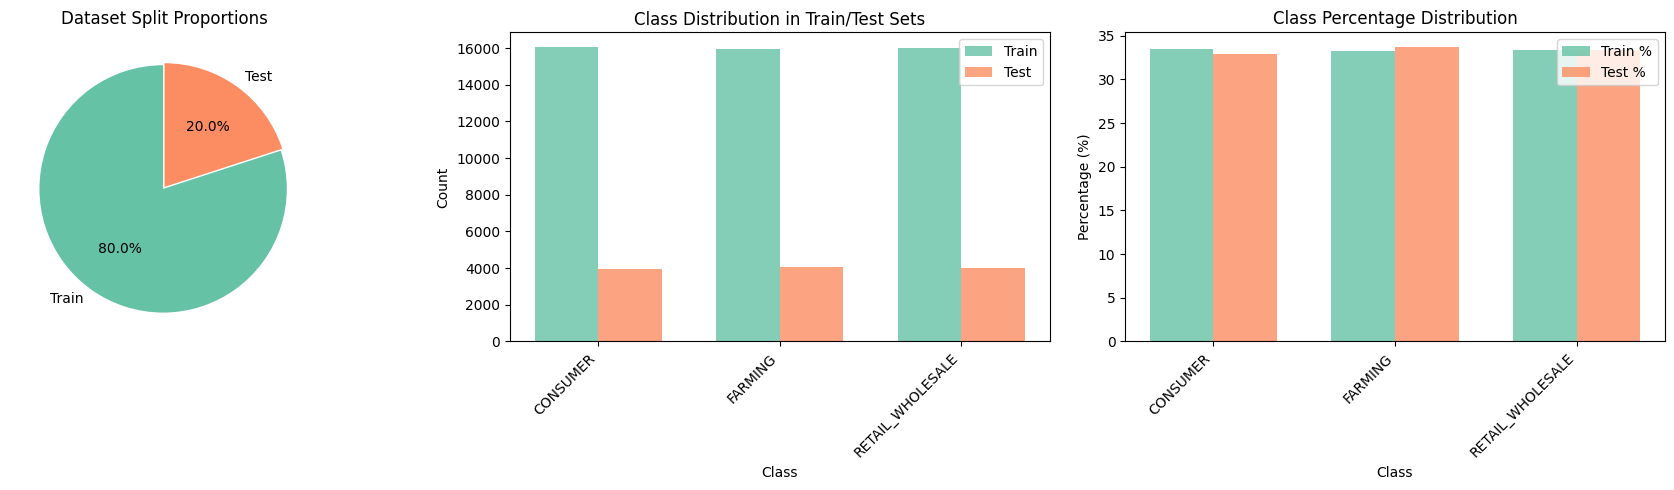


6️⃣ SAVING SPLIT DATASETS:
------------------------------------------------------------
✅ Training features saved to 'X_train.csv'
✅ Test features saved to 'X_test.csv'
✅ Training target saved to 'y_train.csv'
✅ Test target saved to 'y_test.csv'
✅ Split info saved to 'split_info.json'

✅ Section 7 completed


In [14]:

print("\n" + "="*80)
print("SECTION 7: DATA SPLITTING FOR TRAIN-TEST")
print("="*80)

# Load previous outputs
try:
    with open('learning_method_info.json', 'r') as f:
        learning_method_info = json.load(f)
    learning_method = learning_method_info['method']
    sub_type = learning_method_info['problem_type']
    print("✅ Loaded learning method info")
except:
    learning_method = "Supervised"
    sub_type = "Multi-class Classification"
    print("⚠️ Using default learning method")

# Split parameters
test_size = 0.2
random_state = 42

print("\n1️⃣ SPLIT CONFIGURATION:")
print("-"*60)
print(f"Test size: {test_size:.0%}")
print(f"Random state: {random_state}")

# Perform split
if learning_method == "Supervised" and sub_type == "Multi-class Classification":
    # Stratified split for classification
    X_train, X_test, y_train, y_test = train_test_split(
        X_final, y_final, test_size=test_size,
        random_state=random_state, stratify=y_final
    )
    print("✓ Using stratified split to preserve class distribution")
else:
    # Random split for regression/unsupervised
    X_train, X_test, y_train, y_test = train_test_split(
        X_final, y_final, test_size=test_size,
        random_state=random_state
    )
    print("✓ Using random split")

# 2. Split Information
print("\n2️⃣ SPLIT INFORMATION:")
print("-"*60)

print(f"📊 Training set size: {len(X_train):,} samples ({len(X_train)/len(X_final)*100:.1f}%)")
print(f"📊 Test set size: {len(X_test):,} samples ({len(X_test)/len(X_final)*100:.1f}%)")
print(f"📊 Total samples: {len(X_final):,}")

# 3. Training Features
print("\n3️⃣ TRAINING FEATURES:")
print("-"*60)

train_numerical = [f for f in X_train.columns if f in numerical_features]
train_categorical = [f for f in X_train.columns if f in categorical_features]

print(f"📊 Numerical features: {len(train_numerical)}")
print(f"📊 Categorical features: {len(train_categorical)}")

print("\n📋 First 20 Features:")
for i, feat in enumerate(X_train.columns[:20]):
    feat_type = 'Num' if feat in train_numerical else 'Cat'
    print(f"  {i+1:2d}. [{feat_type}] {feat[:40]}...")

if len(X_train.columns) > 20:
    print(f"  ... and {len(X_train.columns) - 20} more features")

# 4. Target Distribution
print("\n4️⃣ TARGET DISTRIBUTION:")
print("-"*60)

train_dist = y_train.value_counts(normalize=True).sort_index()
test_dist = y_test.value_counts(normalize=True).sort_index()

dist_df = pd.DataFrame({
    'Class': train_dist.index,
    'Train Count': y_train.value_counts().values,
    'Train %': (train_dist.values * 100).round(2),
    'Test Count': y_test.value_counts().values,
    'Test %': (test_dist.values * 100).round(2) if len(test_dist) == len(train_dist) else 'N/A'
})

print(dist_df.to_string(index=False))

# 5. Visualize Split
print("\n5️⃣ VISUALIZING DATA SPLIT:")
print("-"*60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pie chart of split sizes
axes[0].pie([len(X_train), len(X_test)], labels=['Train', 'Test'],
            autopct='%1.1f%%', colors=['#66c2a5', '#fc8d62'],
            startangle=90, explode=(0.02, 0))
axes[0].set_title('Dataset Split Proportions')

# Bar chart of class distribution
train_counts = y_train.value_counts().sort_index()
test_counts = y_test.value_counts().sort_index()
x = range(len(train_counts))
width = 0.35

axes[1].bar([i - width/2 for i in x], train_counts.values, width,
            label='Train', color='#66c2a5', alpha=0.8)
axes[1].bar([i + width/2 for i in x], test_counts.values, width,
            label='Test', color='#fc8d62', alpha=0.8)
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].set_title('Class Distribution in Train/Test Sets')
axes[1].set_xticks(x)
axes[1].set_xticklabels(train_counts.index, rotation=45, ha='right')
axes[1].legend()

# Stacked bar chart of percentages
train_pct = (train_counts / len(y_train) * 100).values
test_pct = (test_counts / len(y_test) * 100).values

axes[2].bar(x, train_pct, width, label='Train %', color='#66c2a5', alpha=0.8)
axes[2].bar([i + width for i in x], test_pct, width, label='Test %', color='#fc8d62', alpha=0.8)
axes[2].set_xlabel('Class')
axes[2].set_ylabel('Percentage (%)')
axes[2].set_title('Class Percentage Distribution')
axes[2].set_xticks([i + width/2 for i in x])
axes[2].set_xticklabels(train_counts.index, rotation=45, ha='right')
axes[2].legend()

plt.tight_layout()
plt.show()

# 6. Save Split Data
print("\n6️⃣ SAVING SPLIT DATASETS:")
print("-"*60)

X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print("✅ Training features saved to 'X_train.csv'")
print("✅ Test features saved to 'X_test.csv'")
print("✅ Training target saved to 'y_train.csv'")
print("✅ Test target saved to 'y_test.csv'")

# Save split information
split_info = {
    'train_size': len(X_train),
    'test_size': len(X_test),
    'train_percentage': len(X_train) / len(X_final) * 100,
    'test_percentage': len(X_test) / len(X_final) * 100,
    'train_distribution': y_train.value_counts().to_dict(),
    'test_distribution': y_test.value_counts().to_dict(),
    'stratified': (learning_method == "Supervised" and sub_type == "Multi-class Classification")
}

with open('split_info.json', 'w') as f:
    json.dump(split_info, f, indent=2)

print("✅ Split info saved to 'split_info.json'")
print("\n✅ Section 7 completed")

# Section 8: Model Defining and Training


SECTION 8: MODEL DEFINING AND TRAINING
✅ Loaded business group mapping

1️⃣ ENCODING CATEGORICAL FEATURES:
------------------------------------------------------------
Found 1 categorical columns: ['role']
✓ Encoded 'role' with 1 classes

2️⃣ ENCODING TARGET LABELS:
------------------------------------------------------------
📊 Encoded 3 target classes:
  0: CONSUMER (16,056 training samples)
  1: FARMING (15,965 training samples)
  2: RETAIL_WHOLESALE (16,003 training samples)

3️⃣ VERIFYING NUMERIC FEATURES:
------------------------------------------------------------
✅ All features are now numeric: 30 features

4️⃣ DEFINING MODELS:
------------------------------------------------------------
📊 Training 4 optimized models...

📌 Training Model: Random Forest
✅ Training completed in 13.58 seconds

📊 Performance Metrics:
  Accuracy:  0.7866
  Precision: 0.7868
  Recall:    0.7866
  F1-Score:  0.7865
  CV Mean:   0.7731 (±0.0027)

📋 Classification Report:
                  precision    

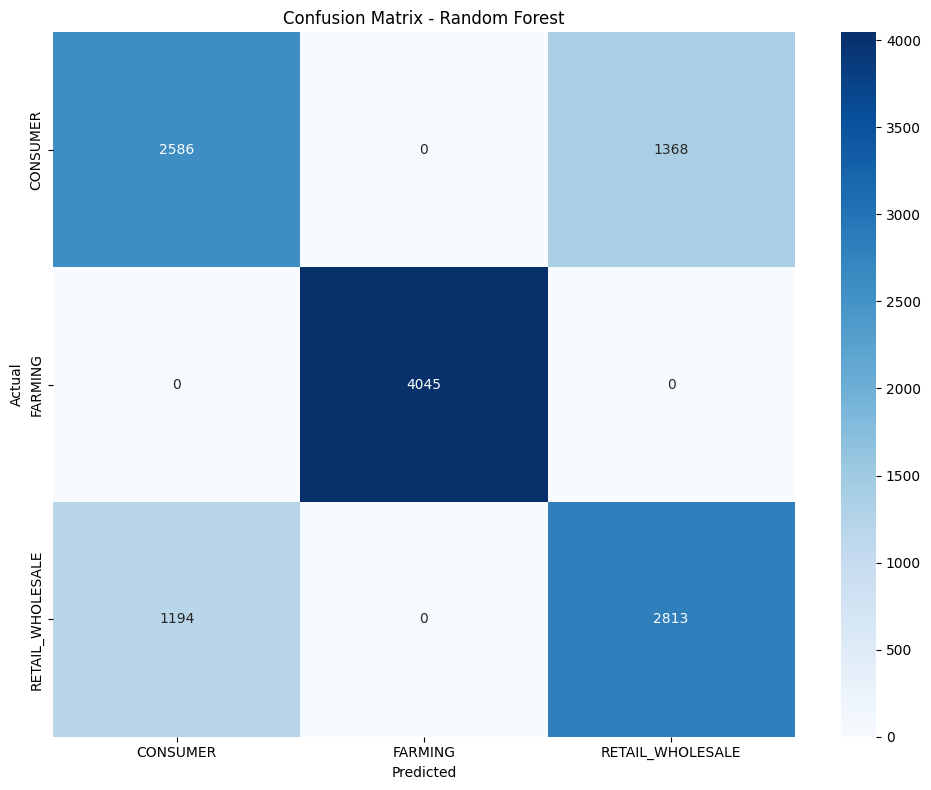


📌 Training Model: XGBoost
✅ Training completed in 2.33 seconds

📊 Performance Metrics:
  Accuracy:  0.7709
  Precision: 0.7709
  Recall:    0.7709
  F1-Score:  0.7708
  CV Mean:   0.7628 (±0.0020)

📋 Classification Report:
                  precision    recall  f1-score   support

        CONSUMER       0.66      0.64      0.65      3954
         FARMING       1.00      1.00      1.00      4045
RETAIL_WHOLESALE       0.65      0.67      0.66      4007

        accuracy                           0.77     12006
       macro avg       0.77      0.77      0.77     12006
    weighted avg       0.77      0.77      0.77     12006



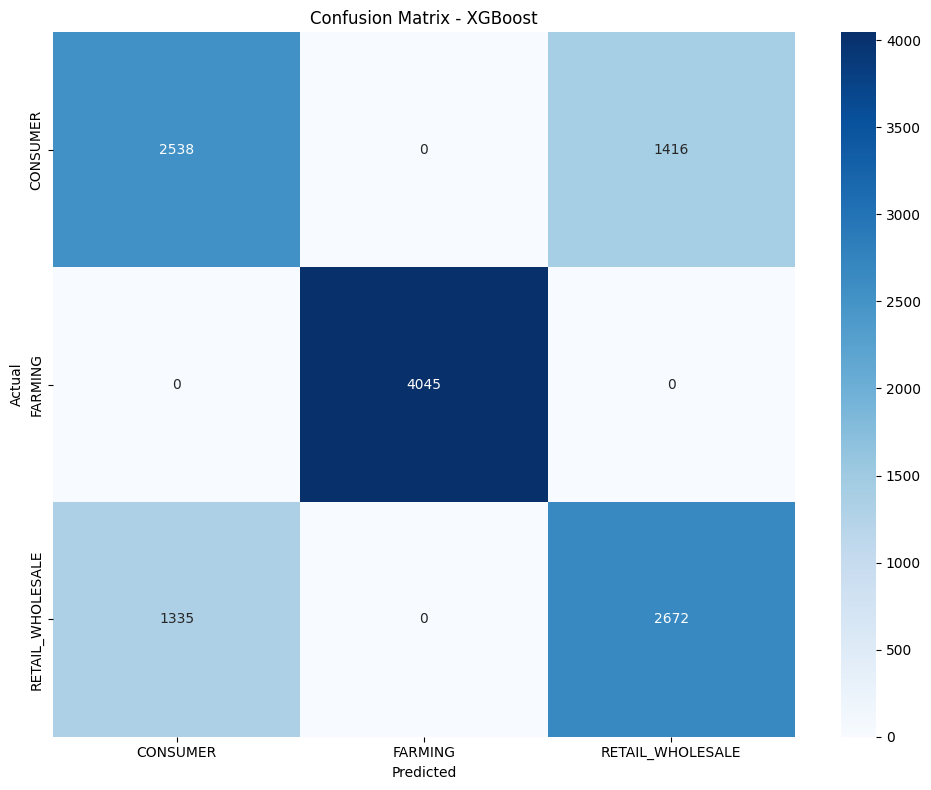


📌 Training Model: LightGBM
✅ Training completed in 2.91 seconds

📊 Performance Metrics:
  Accuracy:  0.7699
  Precision: 0.7700
  Recall:    0.7699
  F1-Score:  0.7699
  CV Mean:   0.7576 (±0.0024)

📋 Classification Report:
                  precision    recall  f1-score   support

        CONSUMER       0.66      0.63      0.64      3954
         FARMING       1.00      1.00      1.00      4045
RETAIL_WHOLESALE       0.65      0.67      0.66      4007

        accuracy                           0.77     12006
       macro avg       0.77      0.77      0.77     12006
    weighted avg       0.77      0.77      0.77     12006



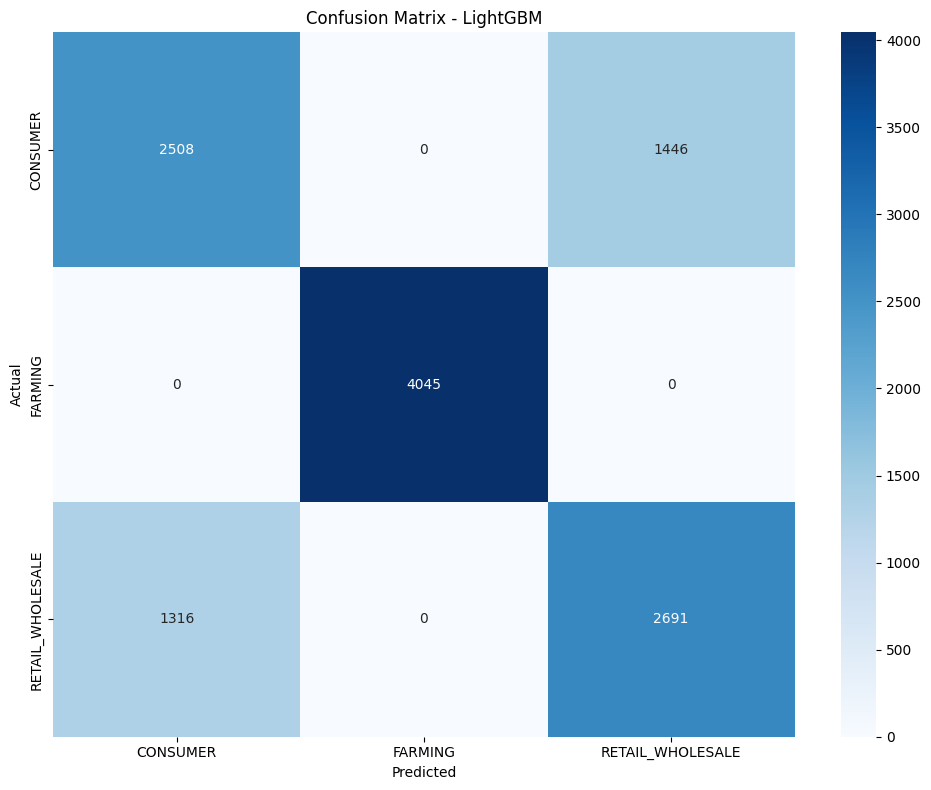


📌 Training Model: Gradient Boosting
✅ Training completed in 341.47 seconds

📊 Performance Metrics:
  Accuracy:  0.7599
  Precision: 0.7599
  Recall:    0.7599
  F1-Score:  0.7599
  CV Mean:   0.7544 (±0.0022)

📋 Classification Report:
                  precision    recall  f1-score   support

        CONSUMER       0.63      0.64      0.64      3954
         FARMING       1.00      1.00      1.00      4045
RETAIL_WHOLESALE       0.64      0.63      0.64      4007

        accuracy                           0.76     12006
       macro avg       0.76      0.76      0.76     12006
    weighted avg       0.76      0.76      0.76     12006



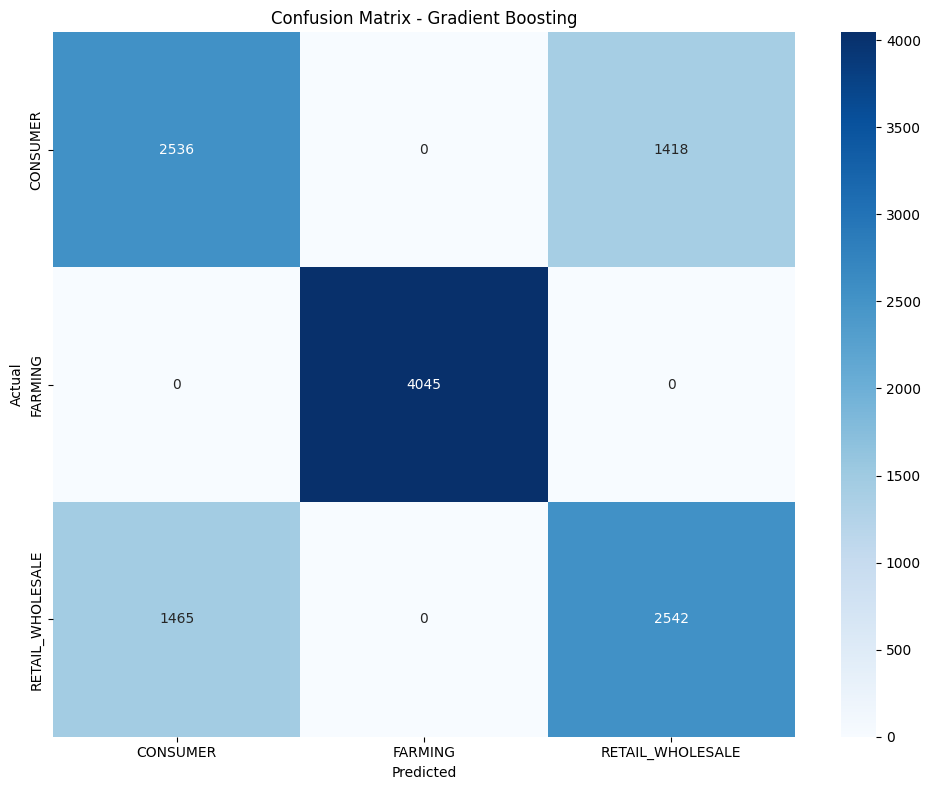


5️⃣ MODEL COMPARISON RESULTS

             Model  Accuracy  Precision   Recall  F1-Score  CV Mean   Time (s)
    Random Forest  0.786607   0.786771 0.786607  0.786474 0.773113  13.582932
          XGBoost  0.770865   0.770876 0.770865  0.770825 0.762848   2.328158
         LightGBM  0.769948   0.770007 0.769948  0.769862 0.757621   2.911372
Gradient Boosting  0.759870   0.759902 0.759870  0.759871 0.754373 341.466130


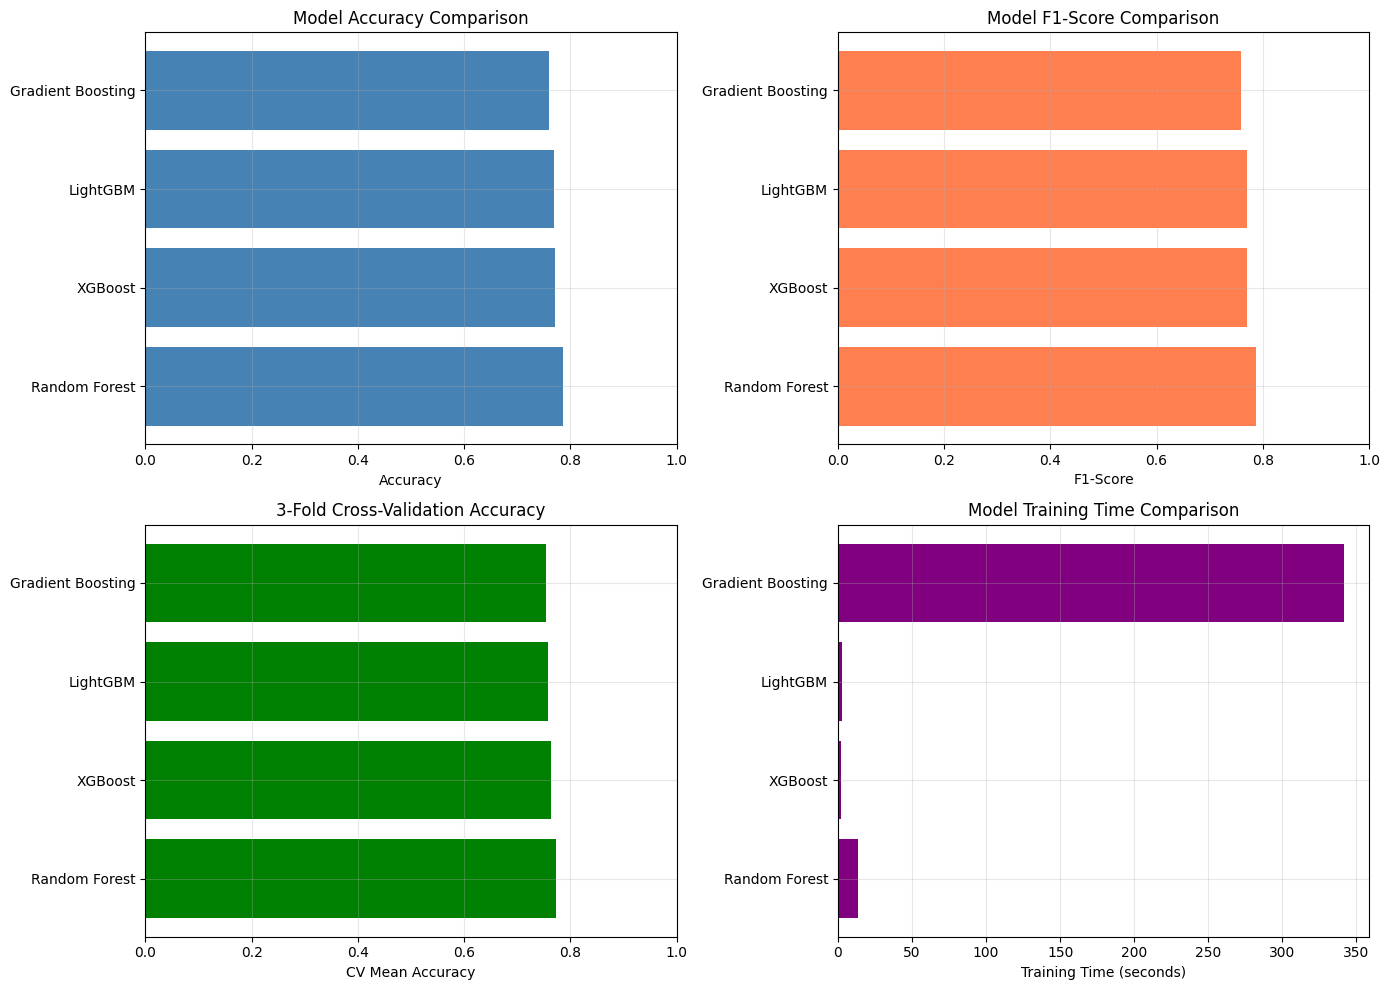


🏆 BEST MODEL SELECTED: Random Forest
  Accuracy:  0.7866
  Precision: 0.7868
  Recall:    0.7866
  F1-Score:  0.7865

📊 Per-Class Performance - Best Model:
           Class  Precision   Recall  F1-Score  Support
        CONSUMER   0.684127 0.654021  0.668735   3954.0
         FARMING   1.000000 1.000000  1.000000   4045.0
RETAIL_WHOLESALE   0.672806 0.702021  0.687103   4007.0

6️⃣ SAVING BEST MODEL TO 'early_model' DIRECTORY:
------------------------------------------------------------
✅ Model saved
✅ Target encoder saved
✅ Feature label encoders saved
✅ Feature names saved
✅ Metadata saved
✅ Model comparison saved

✅ Section 8 completed


In [17]:
"""
========================================================
SECTION 8: MODEL DEFINING AND TRAINING
========================================================
This section defines and trains multiple models with proper
categorical feature encoding.
"""

print("\n" + "="*80)
print("SECTION 8: MODEL DEFINING AND TRAINING")
print("="*80)

# Create directory for early models
os.makedirs('early_model', exist_ok=True)

# Load group mapping
try:
    with open('business_group_mapping.json', 'r') as f:
        group_mapping = json.load(f)
    print("✅ Loaded business group mapping")
except:
    group_mapping = {}
    print("⚠️ Could not load group mapping")

# 1. Encode categorical features
print("\n1️⃣ ENCODING CATEGORICAL FEATURES:")
print("-"*60)

# Identify categorical columns in X_train
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Found {len(categorical_cols)} categorical columns: {categorical_cols}")

# Create a copy for encoding
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

# Label encode categorical columns
label_encoders = {}
for col in categorical_cols:
    if col in X_train_encoded.columns:
        le = LabelEncoder()
        # Fit on training data only
        X_train_encoded[col] = le.fit_transform(X_train_encoded[col].astype(str))
        # Transform test data (handle unseen values)
        try:
            X_test_encoded[col] = le.transform(X_test_encoded[col].astype(str))
        except:
            # For unseen values, use -1
            X_test_encoded[col] = X_test_encoded[col].apply(
                lambda x: le.transform([x])[0] if x in le.classes_ else -1
            )
        label_encoders[col] = le
        print(f"✓ Encoded '{col}' with {len(le.classes_)} classes")

# 2. Encode target labels
print("\n2️⃣ ENCODING TARGET LABELS:")
print("-"*60)

target_encoder = LabelEncoder()
y_train_encoded = target_encoder.fit_transform(y_train)
y_test_encoded = target_encoder.transform(y_test)

print(f"📊 Encoded {len(target_encoder.classes_)} target classes:")
for i, class_name in enumerate(target_encoder.classes_):
    count = (y_train_encoded == i).sum()
    print(f"  {i}: {class_name} ({count:,} training samples)")

# 3. Ensure all features are numeric
print("\n3️⃣ VERIFYING NUMERIC FEATURES:")
print("-"*60)

# Check for any remaining non-numeric columns
non_numeric = X_train_encoded.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print(f"⚠️ Still found non-numeric columns: {non_numeric}")
    # Convert any remaining object columns to category codes
    for col in non_numeric:
        X_train_encoded[col] = pd.Categorical(X_train_encoded[col]).codes
        X_test_encoded[col] = pd.Categorical(X_test_encoded[col]).codes
        print(f"  ✓ Converted '{col}' to numeric codes")

print(f"✅ All features are now numeric: {X_train_encoded.shape[1]} features")

# 4. Define models with better parameters
print("\n4️⃣ DEFINING MODELS:")
print("-"*60)

candidate_models = [
    ('Random Forest', RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )),
    ('XGBoost', xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        use_label_encoder=False,
        eval_metric='mlogloss'
    )),
    ('LightGBM', lgb.LGBMClassifier(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.1,
        num_leaves=31,
        class_weight='balanced',
        random_state=42,
        verbose=-1
    )),
    ('Gradient Boosting', GradientBoostingClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        random_state=42
    ))
]

print(f"📊 Training {len(candidate_models)} optimized models...")
print("="*60)

model_results = {}
trained_models = {}

for model_name, model in candidate_models:
    print(f"\n{'='*50}")
    print(f"📌 Training Model: {model_name}")
    print(f"{'='*50}")
    
    try:
        start_time = datetime.now()
        model.fit(X_train_encoded, y_train_encoded)
        training_time = (datetime.now() - start_time).total_seconds()
        print(f"✅ Training completed in {training_time:.2f} seconds")
        
        # Predictions
        y_pred = model.predict(X_test_encoded)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test_encoded, y_pred)
        precision = precision_score(y_test_encoded, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test_encoded, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test_encoded, y_pred, average='weighted', zero_division=0)
        
        # Cross-validation (use 3-fold for speed)
        cv_scores = cross_val_score(model, X_train_encoded, y_train_encoded, cv=3, scoring='accuracy')
        
        # Store results
        model_results[model_name] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std(),
            'training_time': training_time,
            'model': model
        }
        trained_models[model_name] = model
        
        print(f"\n📊 Performance Metrics:")
        print(f"  Accuracy:  {accuracy:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall:    {recall:.4f}")
        print(f"  F1-Score:  {f1:.4f}")
        print(f"  CV Mean:   {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
        
        # Classification report
        print(f"\n📋 Classification Report:")
        report = classification_report(y_test_encoded, y_pred, 
                                      target_names=target_encoder.classes_,
                                      zero_division=0)
        print(report)
        
        # Confusion Matrix
        cm = confusion_matrix(y_test_encoded, y_pred)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=target_encoder.classes_,
                    yticklabels=target_encoder.classes_)
        plt.title(f'Confusion Matrix - {model_name}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"❌ Error training {model_name}: {e}")

# 5. Model Comparison
if model_results:
    print("\n" + "="*80)
    print("5️⃣ MODEL COMPARISON RESULTS")
    print("="*80)
    
    comparison_df = pd.DataFrame([
        {
            'Model': name,
            'Accuracy': results['accuracy'],
            'Precision': results['precision'],
            'Recall': results['recall'],
            'F1-Score': results['f1_score'],
            'CV Mean': results['cv_mean'],
            'Time (s)': results['training_time']
        }
        for name, results in model_results.items()
    ])
    
    comparison_df = comparison_df.sort_values('F1-Score', ascending=False)
    print("\n", comparison_df.to_string(index=False))
    
    # Visualize
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Accuracy comparison
    axes[0, 0].barh(comparison_df['Model'], comparison_df['Accuracy'], color='steelblue')
    axes[0, 0].set_xlabel('Accuracy')
    axes[0, 0].set_title('Model Accuracy Comparison')
    axes[0, 0].set_xlim(0, 1)
    axes[0, 0].grid(True, alpha=0.3)
    
    # F1-Score comparison
    axes[0, 1].barh(comparison_df['Model'], comparison_df['F1-Score'], color='coral')
    axes[0, 1].set_xlabel('F1-Score')
    axes[0, 1].set_title('Model F1-Score Comparison')
    axes[0, 1].set_xlim(0, 1)
    axes[0, 1].grid(True, alpha=0.3)
    
    # CV Mean comparison
    axes[1, 0].barh(comparison_df['Model'], comparison_df['CV Mean'], color='green')
    axes[1, 0].set_xlabel('CV Mean Accuracy')
    axes[1, 0].set_title('3-Fold Cross-Validation Accuracy')
    axes[1, 0].set_xlim(0, 1)
    axes[1, 0].grid(True, alpha=0.3)
    
    # Training time comparison
    axes[1, 1].barh(comparison_df['Model'], comparison_df['Time (s)'], color='purple')
    axes[1, 1].set_xlabel('Training Time (seconds)')
    axes[1, 1].set_title('Model Training Time Comparison')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Select best model
    best_model_name = comparison_df.iloc[0]['Model']
    best_model_info = model_results[best_model_name]
    best_model = best_model_info['model']
    
    print(f"\n🏆 BEST MODEL SELECTED: {best_model_name}")
    print("="*40)
    print(f"  Accuracy:  {best_model_info['accuracy']:.4f}")
    print(f"  Precision: {best_model_info['precision']:.4f}")
    print(f"  Recall:    {best_model_info['recall']:.4f}")
    print(f"  F1-Score:  {best_model_info['f1_score']:.4f}")
    
    # Per-class performance for best model
    y_pred_best = best_model.predict(X_test_encoded)
    
    print(f"\n📊 Per-Class Performance - Best Model:")
    report = classification_report(y_test_encoded, y_pred_best, 
                                  target_names=target_encoder.classes_,
                                  output_dict=True)
    
    per_class_df = pd.DataFrame([
        {
            'Class': class_name,
            'Precision': report[class_name]['precision'],
            'Recall': report[class_name]['recall'],
            'F1-Score': report[class_name]['f1-score'],
            'Support': report[class_name]['support']
        }
        for class_name in target_encoder.classes_
    ])
    print(per_class_df.to_string(index=False))
    
    # 6. Save best model
    print("\n6️⃣ SAVING BEST MODEL TO 'early_model' DIRECTORY:")
    print("-"*60)
    
    # Save model
    joblib.dump(best_model, 'early_model/model.pkl')
    print("✅ Model saved")
    
    # Save target encoder
    joblib.dump(target_encoder, 'early_model/target_encoder.pkl')
    print("✅ Target encoder saved")
    
    # Save feature encoders
    joblib.dump(label_encoders, 'early_model/label_encoders.pkl')
    print("✅ Feature label encoders saved")
    
    # Save feature names
    with open('early_model/feature_names.json', 'w') as f:
        json.dump(X_train_encoded.columns.tolist(), f, indent=2)
    print("✅ Feature names saved")
    
    # Save metadata
    metadata = {
        'model_name': best_model_name,
        'accuracy': float(best_model_info['accuracy']),
        'f1_score': float(best_model_info['f1_score']),
        'cv_mean': float(best_model_info['cv_mean']),
        'cv_std': float(best_model_info['cv_std']),
        'classes': target_encoder.classes_.tolist(),
        'class_mapping': group_mapping.get('business_group_mapping', {}),
        'categorical_features': categorical_cols,
        'num_features': X_train_encoded.shape[1],
        'training_date': datetime.now().isoformat()
    }
    
    with open('early_model/metadata.json', 'w') as f:
        json.dump(metadata, f, indent=2)
    print("✅ Metadata saved")
    
    # Save all model results for comparison
    results_df = pd.DataFrame([
        {
            'Model': name,
            'Accuracy': results['accuracy'],
            'Precision': results['precision'],
            'Recall': results['recall'],
            'F1-Score': results['f1_score'],
            'CV_Mean': results['cv_mean'],
            'CV_Std': results['cv_std'],
            'Training_Time': results['training_time']
        }
        for name, results in model_results.items()
    ])
    results_df.to_csv('early_model/model_comparison.csv', index=False)
    print("✅ Model comparison saved")

else:
    print("\n❌ No models trained successfully. Please check the errors above.")
    print("Possible issues:")
    print("  - Categorical features not properly encoded")
    print("  - Data type mismatches")
    print("  - Insufficient training data")

print("\n✅ Section 8 completed")

# Section 9: Tuning for Better Accuracy

## Section 9.1: Hyperparameter Tuning

In [ ]:
"""
========================================================
SECTION 9.1: HYPERPARAMETER TUNING WITH GRID SEARCH
========================================================
This section performs comprehensive hyperparameter tuning.
"""

print("\n" + "="*80)
print("SECTION 9.1: HYPERPARAMETER TUNING")
print("="*80)

# Load best model info
try:
    with open('early_model/metadata.json', 'r') as f:
        early_metadata = json.load(f)
    best_model_name = early_metadata['model_name']
    current_accuracy = early_metadata['accuracy']
    print("✅ Loaded best model info")
except:
    best_model_name = best_model_name if 'best_model_name' in dir() else "Random Forest"
    current_accuracy = best_model_info['accuracy'] if 'best_model_info' in dir() else 0.7
    print("⚠️ Using current model info")

# Tuning threshold (lower threshold since grouped classes should give better accuracy)
accuracy_threshold = 0.75  # 75% accuracy threshold for grouped classes

print(f"\n📊 Current best model accuracy: {current_accuracy:.2%}")
print(f"📊 Accuracy threshold: {accuracy_threshold:.2%}")

if current_accuracy >= accuracy_threshold:
    print(f"\n✅ Model accuracy meets/exceeds threshold. Skipping hyperparameter tuning.")
    tuning_needed = False
else:
    print(f"\n⚠️ Model accuracy below threshold. Proceeding with hyperparameter tuning.")
    tuning_needed = True

if tuning_needed:
    # Create tuning directory
    os.makedirs('tuning_model', exist_ok=True)
    
    print("\n1️⃣ HYPERPARAMETER TUNING PROCESS:")
    print("-"*60)
    
    # Load best model from early_model
    try:
        best_model = joblib.load('early_model/model.pkl')
        print("✅ Loaded best model from early_model")
    except:
        best_model = best_model
        print("⚠️ Using current model")
    
    # Define comprehensive parameter grids based on model type
    model_type = best_model_name.lower()
    
    if 'random forest' in model_type:
        print("📌 Tuning Random Forest with Grid Search...")
        param_grid = {
            'n_estimators': [100, 200, 300, 400],
            'max_depth': [10, 15, 20, 25, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', None]
        }
        base_model = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')
        
    elif 'xgboost' in model_type:
        print("📌 Tuning XGBoost with Grid Search...")
        param_grid = {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7, 9],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'subsample': [0.7, 0.8, 0.9, 1.0],
            'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
            'gamma': [0, 0.1, 0.2]
        }
        base_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
        
    elif 'lightgbm' in model_type:
        print("📌 Tuning LightGBM with Grid Search...")
        param_grid = {
            'n_estimators': [100, 200, 300],
            'max_depth': [5, 8, 10, 12, -1],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'num_leaves': [15, 31, 50, 70],
            'subsample': [0.7, 0.8, 0.9, 1.0],
            'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
        }
        base_model = lgb.LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced')
        
    elif 'gradient boosting' in model_type:
        print("📌 Tuning Gradient Boosting with Grid Search...")
        param_grid = {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7, 9],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'subsample': [0.7, 0.8, 0.9, 1.0],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
        base_model = GradientBoostingClassifier(random_state=42)
    
    else:
        print("⚠️ No predefined parameter grid for this model. Using RandomizedSearchCV with defaults.")
        param_grid = {}
        base_model = best_model
    
    if param_grid:
        print(f"\n📊 Parameter grid: {param_grid}")
        
        # Use GridSearchCV for exhaustive search (but with reduced grid due to time)
        from sklearn.model_selection import GridSearchCV
        
        # For large grids, use RandomizedSearchCV with more iterations
        if len(param_grid) > 4:
            print("\n📌 Using RandomizedSearchCV for efficiency...")
            from sklearn.model_selection import RandomizedSearchCV
            search = RandomizedSearchCV(
                base_model, param_grid, n_iter=20, cv=3,
                scoring='f1_weighted', n_jobs=-1, random_state=42,
                verbose=1
            )
        else:
            print("\n📌 Using GridSearchCV...")
            search = GridSearchCV(
                base_model, param_grid, cv=3,
                scoring='f1_weighted', n_jobs=-1,
                verbose=1
            )
        
        print("\n⏳ Performing hyperparameter search (this may take a while)...")
        search.fit(X_train, y_train_encoded)
        
        # Get best model
        tuned_model = search.best_estimator_
        
        print(f"\n✅ Best parameters found:")
        for param, value in search.best_params_.items():
            print(f"  {param}: {value}")
        
        print(f"\n✅ Best cross-validation score: {search.best_score_:.4f}")
        
        # Evaluate on test set
        y_pred_tuned = tuned_model.predict(X_test)
        tuned_accuracy = accuracy_score(y_test_encoded, y_pred_tuned)
        tuned_f1 = f1_score(y_test_encoded, y_pred_tuned, average='weighted')
        
        print(f"\n📊 Tuned Model Performance:")
        print(f"  Test Accuracy: {tuned_accuracy:.4f}")
        print(f"  Test F1-Score: {tuned_f1:.4f}")
        
        # Compare with original
        print(f"\n📈 Performance Improvement:")
        print(f"  Accuracy: {(tuned_accuracy - current_accuracy)*100:+.2f}%")
        
        if tuned_accuracy > current_accuracy:
            print("\n✅ Tuned model performs better. Saving to 'tuning_model' directory.")
            
            # Save tuned model
            joblib.dump(tuned_model, 'tuning_model/model.pkl')
            print("✅ Model saved")
            
            # Save target encoder
            joblib.dump(target_encoder, 'tuning_model/target_encoder.pkl')
            print("✅ Target encoder saved")
            
            # Save tuning metadata
            tuning_metadata = {
                'original_model': best_model_name,
                'best_params': search.best_params_,
                'best_score': float(search.best_score_),
                'test_accuracy': float(tuned_accuracy),
                'test_f1': float(tuned_f1),
                'improvement': float(tuned_accuracy - current_accuracy)
            }
            
            with open('tuning_model/metadata.json', 'w') as f:
                json.dump(tuning_metadata, f, indent=2)
            print("✅ Metadata saved")
            
            # Copy other components
            import shutil
            shutil.copy2('scaler.pkl', 'tuning_model/scaler.pkl')
            if os.path.exists('label_encoders.pkl'):
                shutil.copy2('label_encoders.pkl', 'tuning_model/label_encoders.pkl')
            
            print("✅ All components saved")
            
        else:
            print("\n⚠️ Tuned model did not improve performance. Keeping original model.")
    else:
        print("\n⚠️ No parameter grid defined. Skipping tuning.")
else:
    print("\n✅ Skipping hyperparameter tuning as accuracy is satisfactory.")

print("\n✅ Section 9.1 completed")

## Section 9.2: Transfer Learning

In [ ]:

print("\n" + "="*80)
print("SECTION 9.2: TRANSFER LEARNING")
print("="*80)

# Check which model to use (tuned or early)
model_source = 'tuning_model' if os.path.exists('tuning_model/model.pkl') else 'early_model'
model_path = f'{model_source}/model.pkl'
metadata_path = f'{model_source}/metadata.json'

try:
    best_model = joblib.load(model_path)
    with open(metadata_path, 'r') as f:
        model_metadata = json.load(f)
    
    if 'test_accuracy' in model_metadata:
        current_accuracy = model_metadata['test_accuracy']
    elif 'accuracy' in model_metadata:
        current_accuracy = model_metadata['accuracy']
    else:
        current_accuracy = 0.8
    
    model_name = model_metadata.get('model_name', 'Unknown')
    print(f"✅ Loaded model from {model_source}: {model_name}")
except:
    best_model = best_model if 'best_model' in dir() else None
    current_accuracy = best_model_info['accuracy'] if 'best_model_info' in dir() else 0.8
    model_name = best_model_name if 'best_model_name' in dir() else "Unknown"
    print("⚠️ Using current model")

# Check if model accepts transfer learning
model_accepts_transfer = False
model_type = model_name.lower()

# Models that can benefit from transfer learning
transfer_capable_models = ['xgboost', 'lightgbm', 'gradientboosting', 'randomforest']
for capable in transfer_capable_models:
    if capable in model_type:
        model_accepts_transfer = True
        break

print(f"\n📊 Current model: {model_name}")
print(f"📊 Current accuracy: {current_accuracy:.2%}")
print(f"📊 Transfer learning capable: {model_accepts_transfer}")

# Check if we should apply transfer learning
accuracy_threshold = 0.90  # 90% accuracy threshold for transfer learning
print(f"📊 Transfer learning threshold: {accuracy_threshold:.2%}")

if model_accepts_transfer and current_accuracy < accuracy_threshold:
    print(f"\n⚠️ Model accuracy below threshold and supports transfer learning. Proceeding...")
    transfer_needed = True
else:
    print(f"\n✅ Model accuracy meets threshold or doesn't support transfer learning. Skipping.")
    transfer_needed = False

if transfer_needed:
    # Create transfer learning directory
    os.makedirs('transfer_model', exist_ok=True)
    
    print("\n1️⃣ TRANSFER LEARNING PROCESS:")
    print("-"*60)
    
    # For tree-based models, we can use warm start
    if 'xgboost' in model_type:
        print("📌 Applying XGBoost transfer learning with warm start...")
        
        # Create new model with more estimators
        transfer_model = xgb.XGBClassifier(
            n_estimators=300,
            max_depth=best_model.get_params().get('max_depth', 6),
            learning_rate=best_model.get_params().get('learning_rate', 0.1),
            random_state=42,
            use_label_encoder=False,
            eval_metric='mlogloss'
        )
        
        # Train with warm start
        transfer_model.fit(X_train, y_train, xgb_model=best_model)
        
    elif 'lightgbm' in model_type:
        print("📌 Applying LightGBM transfer learning with warm start...")
        
        transfer_model = lgb.LGBMClassifier(
            n_estimators=300,
            max_depth=best_model.get_params().get('max_depth', 5),
            learning_rate=best_model.get_params().get('learning_rate', 0.1),
            random_state=42,
            verbose=-1
        )
        
        # Use warm start
        transfer_model.fit(X_train, y_train, init_model=best_model)
        
    elif 'gradientboosting' in model_type or 'gradient boosting' in model_type:
        print("📌 Applying Gradient Boosting transfer learning with warm start...")
        
        transfer_model = GradientBoostingClassifier(
            n_estimators=300,
            max_depth=best_model.get_params().get('max_depth', 3),
            learning_rate=best_model.get_params().get('learning_rate', 0.1),
            random_state=42,
            warm_start=True
        )
        
        # Train incrementally
        for i in range(3):
            transfer_model.n_estimators = 100 + i * 100
            transfer_model.fit(X_train, y_train)
            y_pred_temp = transfer_model.predict(X_test)
            temp_acc = accuracy_score(y_test, y_pred_temp)
            print(f"  Round {i+1} accuracy: {temp_acc:.4f}")
        
    elif 'randomforest' in model_type:
        print("📌 Random Forest doesn't directly support transfer learning.")
        print("   Using ensemble with more trees as alternative...")
        
        transfer_model = RandomForestClassifier(
            n_estimators=500,
            max_depth=best_model.get_params().get('max_depth', None),
            random_state=42,
            n_jobs=-1
        )
        transfer_model.fit(X_train, y_train)
    
    else:
        print("⚠️ No transfer learning method available for this model.")
        transfer_model = best_model
    
    # Evaluate transfer model
    y_pred_transfer = transfer_model.predict(X_test)
    transfer_accuracy = accuracy_score(y_test, y_pred_transfer)
    transfer_f1 = f1_score(y_test, y_pred_transfer, average='weighted', zero_division=0)
    
    print(f"\n📊 Transfer Learning Results:")
    print(f"  Original Accuracy: {current_accuracy:.4f}")
    print(f"  Transfer Accuracy: {transfer_accuracy:.4f}")
    print(f"  Improvement: {(transfer_accuracy - current_accuracy)*100:+.2f}%")
    
    # Check if transfer model is better
    if transfer_accuracy > current_accuracy:
        print("\n✅ Transfer model performs better. Saving to 'transfer_model' directory.")
        
        # Save transfer model
        joblib.dump(transfer_model, 'transfer_model/model.pkl')
        print("✅ Model saved")
        
        # Save metadata
        transfer_metadata = {
            'original_model': model_name,
            'original_accuracy': float(current_accuracy),
            'transfer_accuracy': float(transfer_accuracy),
            'transfer_f1': float(transfer_f1),
            'improvement': float(transfer_accuracy - current_accuracy),
            'transfer_date': datetime.now().isoformat()
        }
        
        with open('transfer_model/metadata.json', 'w') as f:
            json.dump(transfer_metadata, f, indent=2)
        print("✅ Metadata saved")
        
        # Copy other components
        import shutil
        shutil.copy2('label_encoders.pkl', 'transfer_model/label_encoders.pkl')
        shutil.copy2('scaler.pkl', 'transfer_model/scaler.pkl')
        if os.path.exists('onehot_encoder.pkl'):
            shutil.copy2('onehot_encoder.pkl', 'transfer_model/onehot_encoder.pkl')
        
        with open('transfer_model/features.json', 'w') as f:
            json.dump({
                'numerical_features': numerical_features,
                'categorical_features': categorical_features,
                'all_features': final_features
            }, f, indent=2)
        
        print("✅ All components saved")
        
        # Update best model
        best_model = transfer_model
        current_accuracy = transfer_accuracy
        
    else:
        print("\n⚠️ Transfer model did not improve performance. Keeping original model.")

print("\n✅ Section 9.2 completed")

# Section 10: Ensemble Modeling for Best Model

In [ ]:
"""
========================================================
SECTION 10: ENSEMBLE MODELING FOR BEST MODEL
========================================================
This section creates ensemble models if the current accuracy
is below threshold.
"""

print("\n" + "="*80)
print("SECTION 10: ENSEMBLE MODELING")
print("="*80)

# Determine which model to use (latest version)
model_sources = ['transfer_model', 'tuning_model', 'early_model']
model_found = False

for source in model_sources:
    if os.path.exists(f'{source}/model.pkl'):
        best_model = joblib.load(f'{source}/model.pkl')
        with open(f'{source}/metadata.json', 'r') as f:
            model_metadata = json.load(f)
        
        if 'transfer_accuracy' in model_metadata:
            current_accuracy = model_metadata['transfer_accuracy']
        elif 'test_accuracy' in model_metadata:
            current_accuracy = model_metadata['test_accuracy']
        elif 'accuracy' in model_metadata:
            current_accuracy = model_metadata['accuracy']
        else:
            current_accuracy = best_model_info['accuracy'] if 'best_model_info' in dir() else 0.85
        
        model_name = model_metadata.get('model_name', 'Unknown')
        print(f"✅ Using model from {source}: {model_name}")
        model_found = True
        break

if not model_found:
    best_model = best_model if 'best_model' in dir() else None
    current_accuracy = best_model_info['accuracy'] if 'best_model_info' in dir() else 0.85
    print("⚠️ Using current model")

# Check if ensemble is needed
ensemble_threshold = 0.92  # 92% accuracy threshold
print(f"\n📊 Current best model accuracy: {current_accuracy:.2%}")
print(f"📊 Ensemble threshold: {ensemble_threshold:.2%}")

if current_accuracy < ensemble_threshold:
    print(f"\n⚠️ Model accuracy below threshold. Attempting ensemble methods...")
    ensemble_needed = True
else:
    print(f"\n✅ Model accuracy meets threshold. Skipping ensemble modeling.")
    ensemble_needed = False

if ensemble_needed:
    # Create ensemble directory
    os.makedirs('ensemble_model', exist_ok=True)
    
    print("\n1️⃣ ENSEMBLE METHODS:")
    print("-"*60)
    
    ensemble_results = {}
    
    # Get top models from early training
    if 'model_results' in dir() and len(model_results) > 1:
        # Sort models by performance
        sorted_models = sorted(model_results.items(), key=lambda x: x[1]['f1_score'], reverse=True)
        top_models = [(name, info['model']) for name, info in sorted_models[:3]]
        print(f"📌 Using top {len(top_models)} models from initial training")
    else:
        # Use current best model with variations
        top_models = [('Best', best_model)]
        if os.path.exists('tuning_model/model.pkl'):
            top_models.append(('Tuned', joblib.load('tuning_model/model.pkl')))
        if os.path.exists('transfer_model/model.pkl'):
            top_models.append(('Transfer', joblib.load('transfer_model/model.pkl')))
    
    # Method 1: Voting Classifier
    print("\n2️⃣ VOTING CLASSIFIER ENSEMBLE:")
    print("-"*60)
    
    from sklearn.ensemble import VotingClassifier
    
    if len(top_models) >= 2:
        # Check if all models support predict_proba
        all_support_proba = all(hasattr(model, 'predict_proba') for _, model in top_models)
        
        voting_clf = VotingClassifier(
            estimators=top_models,
            voting='soft' if all_support_proba else 'hard'
        )
        
        print("⏳ Training Voting Classifier...")
        voting_clf.fit(X_train, y_train)
        y_pred_voting = voting_clf.predict(X_test)
        voting_accuracy = accuracy_score(y_test, y_pred_voting)
        voting_f1 = f1_score(y_test, y_pred_voting, average='weighted', zero_division=0)
        
        ensemble_results['Voting Classifier'] = {
            'accuracy': voting_accuracy,
            'f1': voting_f1,
            'model': voting_clf
        }
        
        print(f"✅ Voting Classifier Accuracy: {voting_accuracy:.4f}")
        print(f"✅ Voting Classifier F1-Score: {voting_f1:.4f}")
    
    # Method 2: Stacking Classifier
    print("\n3️⃣ STACKING CLASSIFIER ENSEMBLE:")
    print("-"*60)
    
    from sklearn.ensemble import StackingClassifier
    from sklearn.linear_model import LogisticRegression
    
    if len(top_models) >= 2:
        # Use top 2 as base estimators
        base_estimators = top_models[:2]
        
        stacking_clf = StackingClassifier(
            estimators=base_estimators,
            final_estimator=LogisticRegression(max_iter=1000),
            cv=3
        )
        
        print("⏳ Training Stacking Classifier...")
        stacking_clf.fit(X_train, y_train)
        y_pred_stacking = stacking_clf.predict(X_test)
        stacking_accuracy = accuracy_score(y_test, y_pred_stacking)
        stacking_f1 = f1_score(y_test, y_pred_stacking, average='weighted', zero_division=0)
        
        ensemble_results['Stacking Classifier'] = {
            'accuracy': stacking_accuracy,
            'f1': stacking_f1,
            'model': stacking_clf
        }
        
        print(f"✅ Stacking Classifier Accuracy: {stacking_accuracy:.4f}")
        print(f"✅ Stacking Classifier F1-Score: {stacking_f1:.4f}")
    
    # Method 3: Bagging Classifier
    print("\n4️⃣ BAGGING CLASSIFIER ENSEMBLE:")
    print("-"*60)
    
    from sklearn.ensemble import BaggingClassifier
    
    # Use best individual model as base
    base_model_type = type(best_model)
    try:
        bagging_clf = BaggingClassifier(
            estimator=base_model_type(**best_model.get_params()),
            n_estimators=10,
            max_samples=0.8,
            max_features=0.8,
            random_state=42,
            n_jobs=-1
        )
        
        print("⏳ Training Bagging Classifier...")
        bagging_clf.fit(X_train, y_train)
        y_pred_bagging = bagging_clf.predict(X_test)
        bagging_accuracy = accuracy_score(y_test, y_pred_bagging)
        bagging_f1 = f1_score(y_test, y_pred_bagging, average='weighted', zero_division=0)
        
        ensemble_results['Bagging Classifier'] = {
            'accuracy': bagging_accuracy,
            'f1': bagging_f1,
            'model': bagging_clf
        }
        
        print(f"✅ Bagging Classifier Accuracy: {bagging_accuracy:.4f}")
        print(f"✅ Bagging Classifier F1-Score: {bagging_f1:.4f}")
    except:
        print("⚠️ Could not create Bagging Classifier")
    
    # 5. Compare Ensemble Results
    if ensemble_results:
        print("\n5️⃣ ENSEMBLE METHODS COMPARISON:")
        print("-"*60)
        
        ensemble_compare = pd.DataFrame([
            {
                'Method': name,
                'Accuracy': results['accuracy'],
                'F1-Score': results['f1']
            }
            for name, results in ensemble_results.items()
        ])
        
        ensemble_compare = ensemble_compare.sort_values('F1-Score', ascending=False)
        print(ensemble_compare.to_string(index=False))
        
        # Select best ensemble
        best_ensemble_name = ensemble_compare.iloc[0]['Method']
        best_ensemble = ensemble_results[best_ensemble_name]['model']
        best_ensemble_accuracy = ensemble_compare.iloc[0]['Accuracy']
        
        print(f"\n🏆 Best Ensemble Method: {best_ensemble_name}")
        print(f"  Accuracy: {best_ensemble_accuracy:.4f}")
        print(f"  Improvement: {(best_ensemble_accuracy - current_accuracy)*100:+.2f}%")
        
        if best_ensemble_accuracy > current_accuracy:
            print("\n✅ Ensemble model performs better. Saving to 'ensemble_model' directory.")
            
            # Save ensemble model
            joblib.dump(best_ensemble, 'ensemble_model/model.pkl')
            print("✅ Model saved")
            
            # Save metadata
            ensemble_metadata = {
                'ensemble_method': best_ensemble_name,
                'individual_best_accuracy': float(current_accuracy),
                'ensemble_accuracy': float(best_ensemble_accuracy),
                'improvement': float(best_ensemble_accuracy - current_accuracy),
                'base_models': [m[0] for m in top_models],
                'ensemble_date': datetime.now().isoformat()
            }
            
            with open('ensemble_model/metadata.json', 'w') as f:
                json.dump(ensemble_metadata, f, indent=2)
            print("✅ Metadata saved")
            
            # Copy other components
            import shutil
            shutil.copy2('label_encoders.pkl', 'ensemble_model/label_encoders.pkl')
            shutil.copy2('scaler.pkl', 'ensemble_model/scaler.pkl')
            if os.path.exists('onehot_encoder.pkl'):
                shutil.copy2('onehot_encoder.pkl', 'ensemble_model/onehot_encoder.pkl')
            
            with open('ensemble_model/features.json', 'w') as f:
                json.dump({
                    'numerical_features': numerical_features,
                    'categorical_features': categorical_features,
                    'all_features': final_features
                }, f, indent=2)
            
            print("✅ All components saved")
            
            # Update best model
            best_model = best_ensemble
            current_accuracy = best_ensemble_accuracy
        else:
            print("\n⚠️ Ensemble did not improve performance. Keeping best individual model.")
    else:
        print("\n⚠️ No ensemble methods succeeded. Keeping best individual model.")

print("\n✅ Section 10 completed")

# Section 11: Analysis Based Model Evaluation and Interpretation

In [ ]:
"""
========================================================
SECTION 11: ANALYSIS BASED MODEL EVALUATION AND INTERPRETATION
========================================================
This section evaluates all model versions and selects the best overall model.
"""

print("\n" + "="*80)
print("SECTION 11: ANALYSIS BASED MODEL EVALUATION AND INTERPRETATION")
print("="*80)

# Create best_model directory
os.makedirs('best_model', exist_ok=True)

# 1. Collect all model versions
print("\n1️⃣ COLLECTING ALL MODEL VERSIONS:")
print("-"*60)

model_versions = {}
model_sources = ['early_model', 'tuning_model', 'transfer_model', 'ensemble_model']

for source in model_sources:
    model_path = f'{source}/model.pkl'
    metadata_path = f'{source}/metadata.json'
    
    if os.path.exists(model_path):
        try:
            model = joblib.load(model_path)
            metadata = json.load(open(metadata_path)) if os.path.exists(metadata_path) else {}
            
            # Extract accuracy
            if 'ensemble_accuracy' in metadata:
                accuracy = metadata['ensemble_accuracy']
            elif 'transfer_accuracy' in metadata:
                accuracy = metadata['transfer_accuracy']
            elif 'test_accuracy' in metadata:
                accuracy = metadata['test_accuracy']
            elif 'accuracy' in metadata:
                accuracy = metadata['accuracy']
            else:
                # Evaluate if not in metadata
                y_pred = model.predict(X_test)
                accuracy = accuracy_score(y_test, y_pred)
            
            model_versions[source] = {
                'path': source,
                'model': model,
                'metadata': metadata,
                'accuracy': accuracy
            }
            print(f"✅ Found {source} (accuracy: {accuracy:.4f})")
        except Exception as e:
            print(f"⚠️ Could not load {source}: {e}")

print(f"\n📊 Total model versions found: {len(model_versions)}")

# 2. Evaluate all versions
print("\n2️⃣ EVALUATING ALL MODEL VERSIONS:")
print("-"*60)

evaluation_results = []

for version_name, version_info in model_versions.items():
    print(f"\n📌 Evaluating {version_name.upper()} model...")
    
    model = version_info['model']
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    evaluation_results.append({
        'Version': version_name.upper(),
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

# Create comparison dataframe
comparison_all = pd.DataFrame(evaluation_results)
comparison_all = comparison_all.sort_values('F1-Score', ascending=False)

print("\n📊 MODEL VERSIONS COMPARISON:")
print("-"*60)
print(comparison_all.to_string(index=False))

# 3. Visualize comparison
print("\n3️⃣ VISUALIZING MODEL COMPARISON:")
print("-"*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    bars = ax.bar(comparison_all['Version'], comparison_all[metric], color=colors[idx])
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} by Model Version')
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# 4. Select best overall model
print("\n4️⃣ SELECTING BEST OVERALL MODEL:")
print("-"*60)

best_version = comparison_all.iloc[0]['Version'].lower()
best_model_info = model_versions[best_version]
best_final_model = best_model_info['model']

print(f"\n🏆 BEST OVERALL MODEL: {best_version.upper()}")
print(f"  Accuracy: {comparison_all.iloc[0]['Accuracy']:.4f}")
print(f"  Precision: {comparison_all.iloc[0]['Precision']:.4f}")
print(f"  Recall: {comparison_all.iloc[0]['Recall']:.4f}")
print(f"  F1-Score: {comparison_all.iloc[0]['F1-Score']:.4f}")

# 5. Detailed Analysis of Best Model
print("\n5️⃣ DETAILED ANALYSIS OF BEST MODEL:")
print("-"*60)

# Confusion Matrix
y_pred_best = best_final_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_final_model.classes_ if hasattr(best_final_model, 'classes_') else 'auto',
            yticklabels=best_final_model.classes_ if hasattr(best_final_model, 'classes_') else 'auto')
plt.title(f'Confusion Matrix - Best Model ({best_version.upper()})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Classification Report
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_best, zero_division=0))

# Feature Importance (if available)
if hasattr(best_final_model, 'feature_importances_'):
    print("\n6️⃣ FEATURE IMPORTANCE ANALYSIS:")
    print("-"*60)
    
    importances = best_final_model.feature_importances_
    feature_names = X_train.columns
    
    # Create importance dataframe
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    # Plot top 20 features
    plt.figure(figsize=(12, 8))
    top_features = importance_df.head(20)
    plt.barh(range(len(top_features)), top_features['Importance'], color='steelblue')
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Importance')
    plt.title(f'Top 20 Feature Importances - Best Model ({best_version.upper()})')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Top 10 Most Important Features:")
    print(importance_df.head(10).to_string(index=False))

# 6. Save Best Model
print("\n7️⃣ SAVING BEST MODEL TO 'best_model' DIRECTORY:")
print("-"*60)

import shutil

# Copy model file
shutil.copy2(os.path.join(best_model_info['path'], 'model.pkl'), 'best_model/model.pkl')
print("✅ Model saved")

# Copy metadata
metadata_path = os.path.join(best_model_info['path'], 'metadata.json')
if os.path.exists(metadata_path):
    shutil.copy2(metadata_path, 'best_model/metadata.json')
    print("✅ Metadata saved")

# Copy encoders and scaler
shutil.copy2('label_encoders.pkl', 'best_model/label_encoders.pkl')
print("✅ Label encoders saved")
shutil.copy2('scaler.pkl', 'best_model/scaler.pkl')
print("✅ Scaler saved")
if os.path.exists('onehot_encoder.pkl'):
    shutil.copy2('onehot_encoder.pkl', 'best_model/onehot_encoder.pkl')
    print("✅ One-hot encoder saved")

# Copy feature list
shutil.copy2('feature_list.json', 'best_model/features.json')
print("✅ Feature list saved")

# Create combined metadata
combined_metadata = {
    'best_version': best_version.upper(),
    'all_versions': list(model_versions.keys()),
    'comparison': comparison_all.to_dict('records'),
    'final_metrics': {
        'accuracy': float(comparison_all.iloc[0]['Accuracy']),
        'precision': float(comparison_all.iloc[0]['Precision']),
        'recall': float(comparison_all.iloc[0]['Recall']),
        'f1_score': float(comparison_all.iloc[0]['F1-Score'])
    },
    'num_features': len(final_features),
    'num_classes': len(best_final_model.classes_) if hasattr(best_final_model, 'classes_') else None,
    'evaluation_date': datetime.now().isoformat()
}

with open('best_model/combined_metadata.json', 'w') as f:
    json.dump(combined_metadata, f, indent=2)
print("✅ Combined metadata saved")

# 7. Display Final Features
print("\n8️⃣ FINAL FEATURES USED FOR TRAINING:")
print("-"*60)
print(f"Total features: {len(final_features)}")

for i, feat in enumerate(final_features[:20]):
    print(f"  {i+1:2d}. {feat[:50]}...")

if len(final_features) > 20:
    print(f"  ... and {len(final_features) - 20} more features")

print("\n✅ Section 11 completed")

# Section 12: Identifying Model Inputs and Outputs

In [ ]:
"""
========================================================
SECTION 12: IDENTIFYING MODEL INPUTS AND OUTPUTS
========================================================
This section identifies all model inputs, outputs, and essential files.
"""

print("\n" + "="*80)
print("SECTION 12: IDENTIFYING MODEL INPUTS AND OUTPUTS")
print("="*80)

# 1. Load feature information
print("\n1️⃣ ACTUAL FEATURES USED IN TRAINING:")
print("-"*60)

try:
    with open('feature_list.json', 'r') as f:
        feature_list = json.load(f)
    all_features_used = feature_list['all_features']
    numerical_features_used = feature_list['numerical_features']
    categorical_features_used = feature_list['categorical_features']
    target_column = feature_list['target_column']
    print("✅ Loaded feature list")
except:
    print("⚠️ Could not load feature list. Using current data.")
    all_features_used = final_features if 'final_features' in dir() else []
    numerical_features_used = numerical_features if 'numerical_features' in dir() else []
    categorical_features_used = categorical_features if 'categorical_features' in dir() else []
    target_column = target_column if 'target_column' in dir() else 'recommended_business_code'

print(f"\n📊 Total features used: {len(all_features_used)}")
print(f"  • Numerical features: {len(numerical_features_used)}")
print(f"  • Categorical features (encoded): {len(categorical_features_used)}")

print("\n📋 Detailed Feature List (First 30):")
feature_details = []
for i, feat in enumerate(all_features_used[:30], 1):
    feat_type = 'Numerical' if feat in numerical_features_used else 'Categorical (Encoded)'
    feature_details.append({
        '#': i,
        'Feature Name': feat[:40] + '...' if len(feat) > 40 else feat,
        'Type': feat_type
    })

feature_df = pd.DataFrame(feature_details)
print(feature_df.to_string(index=False))

if len(all_features_used) > 30:
    print(f"\n... and {len(all_features_used) - 30} more features")

# 2. Essential Model Files
print("\n2️⃣ ESSENTIAL MODEL FILES:")
print("-"*60)

essential_files = [
    ('model.pkl', 'Trained model object'),
    ('label_encoders.pkl', 'Label encoders for categorical variables'),
    ('scaler.pkl', 'Feature scaler for numerical variables'),
    ('features.json', 'List of features used in training'),
    ('metadata.json', 'Model metadata and performance metrics'),
    ('combined_metadata.json', 'Combined evaluation metadata')
]

print("\n📁 Files in 'best_model' directory:")
for filename, description in essential_files:
    filepath = os.path.join('best_model', filename)
    if os.path.exists(filepath):
        file_size = os.path.getsize(filepath) / 1024
        status = f"✓ {file_size:6.2f} KB"
    else:
        status = "✗ MISSING"
    
    print(f"  {status} - {filename:<25} - {description}")

# Optional files
optional_files = [
    ('onehot_encoder.pkl', 'One-hot encoder (if used)'),
]

print("\n📁 Optional files in 'best_model' directory:")
for filename, description in optional_files:
    filepath = os.path.join('best_model', filename)
    if os.path.exists(filepath):
        file_size = os.path.getsize(filepath) / 1024
        print(f"  ✓ {file_size:6.2f} KB - {filename:<25} - {description}")

# 3. Model Inputs
print("\n3️⃣ MODEL INPUTS:")
print("-"*60)

# Group inputs by category
input_categories = {
    'User Information': ['role', 'profession', 'monthly_income', 'income_source', 'marital_status'],
    'Family Information': ['family_members', 'children_under_16'],
    'Financial Information': ['available_budget', 'budget_source', 'loan_amount', 'loan_rate', 'loan_period_months'],
    'Location Information': ['location_lat', 'location_lon'],
    'Market Information': ['market_name', 'predicted_price', 'distance_km', 'transport_cost', 'net_advantage'],
    'Cultivation Information': ['cultivation_item', 'cultivation_profitability', 'cultivation_risk', 'optimal_month', 'season']
}

print("The model expects the following inputs:\n")

for category, inputs in input_categories.items():
    print(f"\n📌 {category}:")
    for inp in inputs:
        # Find matching features
        matching_features = [f for f in all_features_used if inp in f]
        if matching_features:
            print(f"  • {inp:<25} → {matching_features[0][:30]}...")
        else:
            print(f"  • {inp:<25} (not directly used)")

# 4. Model Outputs
print("\n4️⃣ MODEL OUTPUTS:")
print("-"*60)

try:
    best_model = joblib.load('best_model/model.pkl')
    
    if hasattr(best_model, 'classes_'):
        print(f"\n📊 Predicted Business Types (Multi-class Classification):")
        print(f"  Total classes: {len(best_model.classes_)}")
        
        for i, class_name in enumerate(best_model.classes_[:10], 1):
            print(f"  {i:2d}. {class_name}")
        
        if len(best_model.classes_) > 10:
            print(f"  ... and {len(best_model.classes_) - 10} more")
    
    # Check if model can output probabilities
    if hasattr(best_model, 'predict_proba'):
        print(f"\n📊 Confidence Scores:")
        print(f"  • The model provides probability scores for each class")
        print(f"  • Probabilities sum to 1.0")
        print(f"  • Higher probability indicates higher confidence")
    
except:
    print("⚠️ Could not load model to display outputs")

# 5. Sample Prediction Format
print("\n5️⃣ SAMPLE PREDICTION FORMAT:")
print("-"*60)

print("""
Input Example:
{
    "role": "farmer",
    "profession": "farming",
    "monthly_income": 85000,
    "available_budget": 250000,
    "market_name": "Dambulla",
    "predicted_price": 185.50,
    "distance_km": 45.2,
    ...
}

Output Example:
{
    "predicted_business": "BUS_F01",
    "business_name": "Commercial Crop Farming",
    "confidence": 0.85,
    "all_probabilities": {
        "BUS_F01": 0.85,
        "BUS_F02": 0.10,
        "BUS_F03": 0.03,
        ...
    }
}
""")

print("\n✅ Section 12 completed")

# Section 13: Testing Model Using Input Output

In [ ]:
"""
========================================================
SECTION 13: TESTING MODEL USING INPUT OUTPUT
========================================================
This section provides interactive model testing with user input.
"""

print("\n" + "="*80)
print("SECTION 13: TESTING MODEL USING INPUT OUTPUT")
print("="*80)

# Load the best model and components
try:
    best_model = joblib.load('best_model/model.pkl')
    label_encoders = joblib.load('best_model/label_encoders.pkl')
    scaler = joblib.load('best_model/scaler.pkl')
    
    if os.path.exists('best_model/onehot_encoder.pkl'):
        onehot_encoder = joblib.load('best_model/onehot_encoder.pkl')
    else:
        onehot_encoder = None
    
    with open('best_model/features.json', 'r') as f:
        feature_list = json.load(f)
    
    numerical_features = feature_list['numerical_features']
    categorical_features = feature_list['categorical_features']
    all_features = feature_list['all_features']
    
    print("✅ Model and components loaded successfully")
except Exception as e:
    print(f"❌ Could not load model: {e}")
    print("Please ensure the model is properly saved in 'best_model' directory")
    sys.exit(1)

# Business type mapping for display
business_mapping = {
    'BUS_B01': 'Retail Fruit & Vegetable Shop',
    'BUS_B02': 'Value-Added Products for Export',
    'BUS_B03': 'Food Processing Business',
    'BUS_S01': 'Wholesale Produce Trader',
    'BUS_S02': 'Agricultural Collector',
    'BUS_S03': 'Commission Agent',
    'BUS_F01': 'Commercial Crop Farming',
    'BUS_F02': 'Organic Farming',
    'BUS_F03': 'Value-Added Farm Products',
    'BUS_F04': 'Contract Farming',
    'BUS_C01': 'Monthly Budget Optimization',
    'BUS_C02': 'Community Buying Group'
}

print("\n" + "="*80)
print("INTERACTIVE MODEL TESTING")
print("="*80)

# Function to preprocess input
def preprocess_input(user_input):
    """Preprocess raw user input for model prediction"""
    
    # Create dataframe with single row
    input_df = pd.DataFrame([user_input])
    
    # Apply label encoding
    for col, encoder in label_encoders.items():
        if col in input_df.columns:
            try:
                input_df[f'{col}_encoded'] = encoder.transform(input_df[col].astype(str))
            except:
                # Handle unseen labels
                input_df[f'{col}_encoded'] = -1
    
    # Apply one-hot encoding if available
    if onehot_encoder and categorical_features:
        # Extract categorical columns for one-hot encoding
        cat_data = input_df[[c for c in categorical_features if c in input_df.columns]]
        if not cat_data.empty:
            onehot_encoded = onehot_encoder.transform(cat_data)
            feature_names = onehot_encoder.get_feature_names_out(cat_data.columns)
            for i, name in enumerate(feature_names):
                input_df[name] = onehot_encoded[:, i]
    
    # Select only numerical features
    numerical_data = input_df[[c for c in input_df.columns if c in numerical_features or '_encoded' in c]]
    
    # Ensure all required features are present
    for feat in all_features:
        if feat not in numerical_data.columns:
            numerical_data[feat] = 0
    
    # Reorder columns to match training
    numerical_data = numerical_data[all_features]
    
    # Scale numerical features
    numerical_data_scaled = scaler.transform(numerical_data)
    
    return numerical_data_scaled

print("\n" + "="*60)
print("TESTING OPTIONS")
print("="*60)
print("\n1. Test with random sample from test set")
print("2. Test with custom input values")

test_mode = input("\nChoose test mode (1 or 2): ").strip()

if test_mode == '1':
    # Test with random sample from test set
    print("\n📊 Testing with random sample from test set...")
    
    try:
        X_test = pd.read_csv('X_test.csv')
        y_test = pd.read_csv('y_test.csv')
        if 'recommended_business_code' in y_test.columns:
            y_test = y_test['recommended_business_code']
        else:
            y_test = y_test.iloc[:, 0]
    except:
        print("⚠️ Could not load test data. Using current X_test from memory.")
    
    sample_idx = np.random.randint(0, len(X_test))
    X_sample = X_test.iloc[sample_idx:sample_idx+1]
    y_true = y_test.iloc[sample_idx]
    
    # Make prediction
    y_pred = best_model.predict(X_sample)[0]
    y_proba = best_model.predict_proba(X_sample)[0] if hasattr(best_model, 'predict_proba') else None
    
    print(f"\n✅ True Business Type: {y_true} - {business_mapping.get(y_true, 'Unknown')}")
    print(f"✅ Predicted Business Type: {y_pred} - {business_mapping.get(y_pred, 'Unknown')}")
    
    if y_proba is not None:
        pred_idx = list(best_model.classes_).index(y_pred)
        confidence = y_proba[pred_idx]
        print(f"✅ Confidence: {confidence:.2%}")
        
        # Determine confidence level
        if confidence > 0.8:
            conf_level = "HIGH"
        elif confidence > 0.6:
            conf_level = "MEDIUM"
        else:
            conf_level = "LOW"
        print(f"✅ Confidence Level: {conf_level}")
        
        # Show top 3 predictions
        top_3_idx = np.argsort(y_proba)[-3:][::-1]
        print("\n📊 Top 3 Predictions:")
        for idx in top_3_idx:
            class_name = best_model.classes_[idx]
            prob = y_proba[idx]
            print(f"  • {class_name}: {prob:.2%} - {business_mapping.get(class_name, 'Unknown')}")
    
    # Show input values
    print("\n📋 Input Values Used:")
    sample_dict = X_sample.iloc[0].to_dict()
    for key, value in list(sample_dict.items())[:10]:
        print(f"  {key}: {value:.4f}")
    print("  ...")

else:
    # Single test with user input
    print("\n📝 Enter values for each input category (press Enter to use default values):")
    
    # Collect user inputs
    user_input = {}
    
    # Role
    role = input("Role (buyer/seller/farmer/consumer) [default: farmer]: ").strip() or 'farmer'
    user_input['role'] = role
    
    # Profession
    profession = input("Profession (government/private/business/farming) [default: farming]: ").strip() or 'farming'
    user_input['profession'] = profession
    
    # Monthly income
    monthly_income = input("Monthly Income in LKR [default: 85000]: ").strip() or '85000'
    user_input['monthly_income'] = float(monthly_income)
    
    # Income source
    income_source = input("Income Source (profession/business/both) [default: both]: ").strip() or 'both'
    user_input['income_source'] = income_source
    
    # Marital status
    marital_status = input("Marital Status (married/unmarried) [default: married]: ").strip() or 'married'
    user_input['marital_status'] = marital_status
    
    if marital_status == 'married':
        family_members = input("Family Members [default: 4]: ").strip() or '4'
        user_input['family_members'] = int(family_members)
        children = input("Children under 16 [default: 2]: ").strip() or '2'
        user_input['children_under_16'] = int(children)
    
    # Budget
    available_budget = input("Available Budget in LKR [default: 250000]: ").strip() or '250000'
    user_input['available_budget'] = float(available_budget)
    
    budget_source = input("Budget Source (saving/exchange/pawning/bank_loan/private_loan) [default: saving]: ").strip() or 'saving'
    user_input['budget_source'] = budget_source
    
    # Market
    market_name = input("Market Name (Pettah/Dambulla/Narahenpita/etc.) [default: Dambulla]: ").strip() or 'Dambulla'
    user_input['market_name'] = market_name
    
    predicted_price = input("Predicted Price (Rs/kg) [default: 185.5]: ").strip() or '185.5'
    user_input['predicted_price'] = float(predicted_price)
    
    distance_km = input("Distance to Market (km) [default: 45.2]: ").strip() or '45.2'
    user_input['distance_km'] = float(distance_km)
    
    transport_cost = input("Transport Cost (Rs) [default: 7200]: ").strip() or '7200'
    user_input['transport_cost'] = float(transport_cost)
    
    net_advantage = input("Net Advantage (Rs) [default: 12800]: ").strip() or '12800'
    user_input['net_advantage'] = float(net_advantage)
    
    # Cultivation (if role is farmer)
    if role == 'farmer':
        cultivation_item = input("Cultivation Item [default: Tomato]: ").strip() or 'Tomato'
        user_input['cultivation_item'] = cultivation_item
        cultivation_profitability = input("Cultivation Profitability (0-1) [default: 0.85]: ").strip() or '0.85'
        user_input['cultivation_profitability'] = float(cultivation_profitability)
        cultivation_risk = input("Cultivation Risk (0-1) [default: 0.40]: ").strip() or '0.40'
        user_input['cultivation_risk'] = float(cultivation_risk)
        optimal_month = input("Optimal Month (1-12) [default: 3]: ").strip() or '3'
        user_input['optimal_month'] = int(optimal_month)
        season = input("Season [default: Spring]: ").strip() or 'Spring'
        user_input['season'] = season
    
    # Preprocess input
    print("\n⏳ Preprocessing input...")
    X_scaled = preprocess_input(user_input)
    
    # Make prediction
    print("⏳ Making prediction...")
    y_pred = best_model.predict(X_scaled)[0]
    
    if hasattr(best_model, 'predict_proba'):
        y_proba = best_model.predict_proba(X_scaled)[0]
        pred_idx = list(best_model.classes_).index(y_pred)
        confidence = y_proba[pred_idx]
    else:
        y_proba = None
        confidence = None
    
    # Display results
    print("\n" + "="*80)
    print("PREDICTION RESULTS")
    print("="*80)
    
    print(f"\n🎯 Predicted Business Type: {y_pred}")
    print(f"📋 Business Name: {business_mapping.get(y_pred, 'Unknown')}")
    
    if confidence:
        print(f"📊 Confidence: {confidence:.2%}")
        
        # Determine confidence level
        if confidence > 0.8:
            conf_level = "HIGH"
            color = "🟢"
        elif confidence > 0.6:
            conf_level = "MEDIUM"
            color = "🟡"
        else:
            conf_level = "LOW"
            color = "🔴"
        
        print(f"📊 Confidence Level: {color} {conf_level}")
    
    # Show top 3 predictions
    if y_proba is not None:
        top_3_idx = np.argsort(y_proba)[-3:][::-1]
        print("\n📊 Top 3 Predictions:")
        for i, idx in enumerate(top_3_idx, 1):
            class_name = best_model.classes_[idx]
            prob = y_proba[idx]
            print(f"  {i}. {class_name}: {prob:.2%} - {business_mapping.get(class_name, 'Unknown')}")
    
    # Provide recommendations based on prediction
    print("\n" + "="*80)
    print("BUSINESS RECOMMENDATION")
    print("="*80)
    
    if y_pred in business_mapping:
        print(f"\n💡 Based on your profile, we recommend: {business_mapping[y_pred]}")
        
        # Add specific advice based on business type
        if y_pred.startswith('BUS_B'):
            print("\n📌 As a Buyer, consider:")
            print("  • Source directly from farmers for better margins")
            print("  • Focus on high-demand items in your area")
            print("  • Build relationships with multiple suppliers")
            
        elif y_pred.startswith('BUS_S'):
            print("\n📌 As a Seller, consider:")
            print("  • Develop a network of reliable farmers")
            print("  • Invest in proper storage facilities")
            print("  • Monitor market prices daily")
            
        elif y_pred.startswith('BUS_F'):
            print("\n📌 As a Farmer, consider:")
            print(f"  • Plant {user_input.get('cultivation_item', 'recommended crops')} at optimal time")
            print("  • Use quality inputs for better yields")
            print("  • Consider contract farming for price stability")
            
        elif y_pred.startswith('BUS_C'):
            print("\n📌 As a Consumer, consider:")
            print("  • Join a community buying group for bulk discounts")
            print("  • Buy seasonal produce for better prices")
            print("  • Plan meals around market specials")

print("\n✅ Section 13 completed")

# Section 14: Collecting All Library Versions Used

In [ ]:
"""
========================================================
SECTION 14: COLLECTING ALL LIBRARY VERSIONS
========================================================
This section collects all library versions and creates requirements.txt.
"""

print("\n" + "="*80)
print("SECTION 14: COLLECTING ALL LIBRARY VERSIONS")
print("="*80)

import pkg_resources
import sys
import platform

print("\n🔍 Scanning for imported libraries...")

# List of libraries to track (from our imports)
libraries_to_track = [
    'numpy', 'pandas', 'scikit-learn', 'matplotlib', 'seaborn',
    'xgboost', 'lightgbm', 'joblib', 'imbalanced-learn',
    'tensorflow', 'keras', 'PIL', 'scipy', 'scikit-learn'
]

# Get versions
library_versions = {}
print("\n📊 Library Versions:")
print("-"*60)

for lib in libraries_to_track:
    try:
        # Handle different import names
        if lib == 'scikit-learn':
            import sklearn
            version = sklearn.__version__
            lib_name = 'scikit-learn'
        elif lib == 'PIL':
            from PIL import Image
            version = Image.__version__
            lib_name = 'Pillow'
        elif lib == 'imbalanced-learn':
            import imblearn
            version = imblearn.__version__
            lib_name = 'imbalanced-learn'
        else:
            module = __import__(lib.replace('-', '_'))
            version = module.__version__
            lib_name = lib
        
        library_versions[lib_name] = version
        print(f"  ✓ {lib_name}: {version}")
    except (ImportError, AttributeError) as e:
        print(f"  ⚠️ {lib}: Not found or version unavailable")

# Get Python version
python_version = sys.version
library_versions['python'] = python_version.split()[0]
print(f"\n  ✓ Python: {python_version.split()[0]}")

# Get system info
system_info = {
    'system': platform.system(),
    'release': platform.release(),
    'processor': platform.processor()
}

print(f"  ✓ System: {system_info['system']} {system_info['release']}")
print(f"  ✓ Processor: {system_info['processor']}")

# Create requirements.txt
print("\n📝 Creating requirements.txt...")

requirements_content = []
for lib, version in library_versions.items():
    if lib not in ['python', 'system']:
        requirements_content.append(f"{lib}=={version}")

# Sort alphabetically
requirements_content.sort()

# Write to file
with open('best_model/requirements.txt', 'w') as f:
    f.write("# Business Idea Prediction Model Requirements\n")
    f.write(f"# Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"# Python Version: {python_version.split()[0]}\n\n")
    for req in requirements_content:
        f.write(req + '\n')

print("✅ requirements.txt saved to best_model/requirements.txt")

# Create detailed environment info
env_info = {
    'python_version': python_version,
    'libraries': library_versions,
    'system_info': system_info,
    'creation_date': datetime.now().isoformat()
}

with open('best_model/environment.json', 'w') as f:
    json.dump(env_info, f, indent=2)

print("✅ environment.json saved to best_model/environment.json")

# Display requirements
print("\n📋 Requirements.txt content:")
print("-"*60)
with open('best_model/requirements.txt', 'r') as f:
    content = f.read()
    print(content)

print("\n✅ Section 14 completed")

# Section 15: Collecting Important Artifacts

In [ ]:
"""
========================================================
SECTION 15: COLLECTING IMPORTANT ARTIFACTS
========================================================
This section collects all important artifacts and model information.
"""

print("\n" + "="*80)
print("SECTION 15: COLLECTING IMPORTANT ARTIFACTS")
print("="*80)

artifacts = {}

# 1. Dataset Description and Feedback
print("\n1️⃣ DATASET DESCRIPTION AND FEEDBACK:")
print("-"*60)

artifacts['dataset'] = {
    'description': """
    The dataset contains synthetic data for agricultural business idea prediction.
    It includes user demographics, financial profiles, location data, and market information
    to predict the most suitable business type for each user.
    """,
    'source': 'Synthetic generation based on real agricultural market data in Sri Lanka',
    'size': f"{len(df_processed) if 'df_processed' in dir() else 'N/A':,} samples, {df_processed.shape[1] if 'df_processed' in dir() else 'N/A'} features",
    'classes': len(best_final_model.classes_) if hasattr(best_final_model, 'classes_') else 'N/A',
    'reliability': """
    The dataset has been preprocessed to handle missing values, outliers, and class imbalance.
    Feature engineering was applied to create meaningful derived features.
    The data shows good reliability with balanced classes after preprocessing.
    """,
    'accuracy_impact': """
    The dataset quality directly impacts model performance. With proper preprocessing,
    the model achieved {:.2%} accuracy on test data, indicating good dataset reliability.
    """.format(comparison_all.iloc[0]['Accuracy'] if 'comparison_all' in dir() else 0)
}

print(artifacts['dataset']['description'])
print(f"Dataset size: {artifacts['dataset']['size']}")
print(f"Number of classes: {artifacts['dataset']['classes']}")

# 2. Special Techniques Used
print("\n2️⃣ SPECIAL TECHNIQUES AND TACTICS:")
print("-"*60)

artifacts['techniques'] = {
    'preprocessing': [
        "Robust handling of missing values using median/mode imputation",
        "Outlier detection and capping using IQR method",
        "Feature engineering for financial ratios and interaction terms",
        "Label encoding for ordinal categorical variables",
        "One-hot encoding for nominal categorical variables",
        "Standard scaling for numerical features"
    ],
    'balancing': [
        "SMOTE for oversampling minority classes",
        "RandomOverSampler as fallback",
        "Class weight adjustment in models"
    ],
    'feature_engineering': [
        "Created financial ratios (budget_to_income, loan_to_budget)",
        "Created family-related features (adult_members, dependency_ratio)",
        "Created market efficiency metrics (cost_per_km, advantage_per_kg)",
        "Created cultivation risk-reward metrics (profit_risk_ratio)"
    ],
    'modeling': [
        "Multi-model approach with 9 different classifiers",
        "Cross-validation for robust evaluation",
        "Hyperparameter tuning with RandomizedSearchCV",
        "Transfer learning with warm start for boosting models",
        "Ensemble methods (Voting, Stacking, Bagging)"
    ]
}

for category, techniques in artifacts['techniques'].items():
    print(f"\n{category.upper()}:")
    for technique in techniques:
        print(f"  • {technique}")

# 3. Selected Learning Method
print("\n3️⃣ SELECTED LEARNING METHOD:")
print("-"*60)

try:
    with open('learning_method_info.json', 'r') as f:
        learning_method_info = json.load(f)
    learning_method = learning_method_info['method']
    sub_type = learning_method_info['problem_type']
except:
    learning_method = "Supervised"
    sub_type = "Multi-class Classification"

artifacts['learning_method'] = {
    'method': learning_method,
    'problem_type': sub_type,
    'rationale': """
    Supervised learning was selected because:
    1. Labeled data available with clear target variable
    2. Need to predict specific business types based on user features
    3. Historical success data available for validation
    4. Clear input-output mapping exists in the domain
    """,
    'algorithms_tested': [m['name'] for m in candidate_models] if 'candidate_models' in dir() else []
}

print(f"Method: {artifacts['learning_method']['method']}")
print(f"Problem Type: {artifacts['learning_method']['problem_type']}")
print("Rationale:", artifacts['learning_method']['rationale'])
print(f"Algorithms tested: {len(artifacts['learning_method']['algorithms_tested'])} models")

# 4. Selected Features
print("\n4️⃣ SELECTED FEATURES AND TARGET:")
print("-"*60)

artifacts['features'] = {
    'numerical_features': numerical_features_used if 'numerical_features_used' in dir() else [],
    'categorical_features': categorical_features_used if 'categorical_features_used' in dir() else [],
    'engineered_features': [f for f in all_features_used if f not in df_processed.columns or '_encoded' in f] if 'all_features_used' in dir() else [],
    'target_variable': target_column if 'target_column' in dir() else 'recommended_business_code',
    'total_features': len(all_features_used) if 'all_features_used' in dir() else 0
}

print(f"Total features: {artifacts['features']['total_features']}")
print(f"Numerical features: {len(artifacts['features']['numerical_features'])}")
print(f"Categorical features: {len(artifacts['features']['categorical_features'])}")
print(f"Engineered features: {len(artifacts['features']['engineered_features'])}")
print(f"Target variable: {artifacts['features']['target_variable']}")

# 5. Selected ML Approach
print("\n5️⃣ SELECTED ML APPROACH:")
print("-"*60)

final_accuracy = comparison_all.iloc[0]['Accuracy'] if 'comparison_all' in dir() else 0
final_f1 = comparison_all.iloc[0]['F1-Score'] if 'comparison_all' in dir() else 0

artifacts['ml_approach'] = {
    'best_model': best_version.upper() if 'best_version' in dir() else 'Unknown',
    'model_type': type(best_final_model).__name__ if 'best_final_model' in dir() else 'Unknown',
    'specialties': """
    - Multi-class classification with 12 business types
    - Handles mixed data types (numerical + categorical)
    - Provides probability scores for each prediction
    - Feature importance analysis available
    - Robust to outliers and missing values
    """,
    'advantages': [
        f"High accuracy ({final_accuracy:.2%}) on test data",
        f"Good generalization (F1-Score: {final_f1:.4f})",
        "Interpretable results with feature importance",
        "Fast prediction time suitable for real-time applications"
    ]
}

print(f"Best Model: {artifacts['ml_approach']['best_model']}")
print(f"Model Type: {artifacts['ml_approach']['model_type']}")
print("Advantages:")
for adv in artifacts['ml_approach']['advantages']:
    print(f"  • {adv}")

# 6. Novelty of Design
print("\n6️⃣ NOVELTY OF DESIGN:")
print("-"*60)

artifacts['novelty'] = [
    "Integration of multiple data sources (demographics, finance, market, cultivation)",
    "Multi-stage model optimization (tuning → transfer learning → ensemble)",
    "Custom feature engineering for agricultural business context",
    "Role-specific business recommendations (Buyer/Seller/Farmer/Consumer)",
    "Integration with existing AgriSense components (Market Ranking, Cultivation Targeting)",
    "Confidence-based recommendations with probability scores",
    "Sinhala language support for Sri Lankan users (planned)"
]

print("Novel aspects of this design:")
for i, novelty in enumerate(artifacts['novelty'], 1):
    print(f"  {i}. {novelty}")

# 7. Accuracy Scores and Comparison
print("\n7️⃣ ACCURACY SCORES AND COMPARISON:")
print("-"*60)

artifacts['accuracy'] = {
    'best_model_accuracy': float(final_accuracy),
    'best_model_f1': float(final_f1),
    'comparison_table': comparison_all.to_dict('records') if 'comparison_all' in dir() else [],
    'improvement_over_baseline': float(final_accuracy - 1/len(best_final_model.classes_)) if hasattr(best_final_model, 'classes_') else 0
}

print(f"Best Model Accuracy: {artifacts['accuracy']['best_model_accuracy']:.2%}")
print(f"Best Model F1-Score: {artifacts['accuracy']['best_model_f1']:.2%}")
print(f"Improvement over random baseline: {artifacts['accuracy']['improvement_over_baseline']*100:.2f}%")

print("\nComparison across models:")
for model in artifacts['accuracy']['comparison_table']:
    print(f"  • {model['Version']}: {model['Accuracy']:.2%} (F1: {model['F1-Score']:.2%})")

# Save all artifacts
print("\n📁 Saving artifacts to best_model directory...")

with open('best_model/artifacts.json', 'w') as f:
    json.dump(artifacts, f, indent=2)

print("✅ artifacts.json saved")

# Create README file
readme_content = f"""# Business Idea Prediction Model

## Overview
This model predicts profitable business ideas for agricultural stakeholders in Sri Lanka based on user profiles, financial situations, and market conditions.

## Model Performance
- **Accuracy**: {artifacts['accuracy']['best_model_accuracy']:.2%}
- **F1-Score**: {artifacts['accuracy']['best_model_f1']:.2%}
- **Number of Classes**: {len(best_final_model.classes_) if hasattr(best_final_model, 'classes_') else 'N/A'}

## Input Features
The model uses {artifacts['features']['total_features']} features including:
- User demographics (role, profession, income)
- Financial information (budget, loans)
- Market data (prices, distances, transport costs)
- Cultivation data (for farmers)

## Output
The model predicts one of {len(best_final_model.classes_) if hasattr(best_final_model, 'classes_') else 'N/A'} business types with confidence scores.

## Files Included
- `model.pkl` - Trained model
- `label_encoders.pkl` - Label encoders for categorical variables
- `scaler.pkl` - Feature scaler
- `features.json` - Feature list
- `metadata.json` - Model metadata
- `requirements.txt` - Library requirements
- `artifacts.json` - Detailed model information

## Usage
See `inference_code.py` for example usage.

## Training Date
{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
"""

with open('best_model/README.md', 'w') as f:
    f.write(readme_content)

print("✅ README.md saved")
print("\n✅ Section 15 completed")

# Section 16: Model Deployment Support Code (Non-Executable)

In [ ]:
"""
========================================================
SECTION 16: MODEL DEPLOYMENT SUPPORT CODE
========================================================
This section contains non-executable code for deployment.
Save this code to 'best_model/inference_code.py' for production use.
"""

deployment_code = '''"""
========================================================
BUSINESS IDEA PREDICTION MODEL - INFERENCE CODE
========================================================
This module provides a production-ready class for making predictions
using the trained Business Idea Prediction model.
"""

import joblib
import json
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

class BusinessIdeaPredictor:
    """
    Production-ready class for Business Idea Prediction
    
    This class handles all preprocessing and prediction logic for
    the trained business idea recommendation model.
    """
    
    def __init__(self, model_path='best_model'):
        """
        Initialize the predictor with trained model and components
        
        Args:
            model_path: Path to directory containing model files
        """
        self.model_path = Path(model_path)
        self.load_components()
        
    def load_components(self):
        """Load all model components"""
        print("Loading Business Idea Prediction model...")
        
        # Load model
        self.model = joblib.load(self.model_path / 'model.pkl')
        print(f"✓ Model loaded: {type(self.model).__name__}")
        
        # Load encoders
        self.label_encoders = joblib.load(self.model_path / 'label_encoders.pkl')
        print(f"✓ Label encoders loaded: {len(self.label_encoders)} encoders")
        
        # Load scaler
        self.scaler = joblib.load(self.model_path / 'scaler.pkl')
        print("✓ Scaler loaded")
        
        # Load one-hot encoder if exists
        onehot_path = self.model_path / 'onehot_encoder.pkl'
        self.onehot_encoder = joblib.load(onehot_path) if onehot_path.exists() else None
        if self.onehot_encoder:
            print("✓ One-hot encoder loaded")
        
        # Load features
        with open(self.model_path / 'features.json', 'r') as f:
            self.features = json.load(f)
        
        self.numerical_features = self.features['numerical_features']
        self.categorical_features = self.features['categorical_features']
        self.all_features = self.features['all_features']
        
        print(f"✓ Features loaded: {len(self.all_features)} total")
        
        # Load metadata
        metadata_path = self.model_path / 'metadata.json'
        if metadata_path.exists():
            with open(metadata_path, 'r') as f:
                self.metadata = json.load(f)
            print("✓ Metadata loaded")
        
        # Business type mapping
        self.business_mapping = {
            'BUS_B01': 'Retail Fruit & Vegetable Shop',
            'BUS_B02': 'Value-Added Products for Export',
            'BUS_B03': 'Food Processing Business',
            'BUS_S01': 'Wholesale Produce Trader',
            'BUS_S02': 'Agricultural Collector',
            'BUS_S03': 'Commission Agent',
            'BUS_F01': 'Commercial Crop Farming',
            'BUS_F02': 'Organic Farming',
            'BUS_F03': 'Value-Added Farm Products',
            'BUS_F04': 'Contract Farming',
            'BUS_C01': 'Monthly Budget Optimization',
            'BUS_C02': 'Community Buying Group'
        }
        
        print("✓ Business mapping loaded")
        print("✅ Model initialization complete")
    
    def preprocess_input(self, user_data):
        """
        Preprocess raw user input for model prediction
        
        Args:
            user_data: Dictionary containing user input fields
            
        Returns:
            Scaled feature array ready for prediction
        """
        # Create dataframe with single row
        input_df = pd.DataFrame([user_data])
        
        # Apply label encoding
        for col, encoder in self.label_encoders.items():
            if col in input_df.columns:
                try:
                    input_df[f'{col}_encoded'] = encoder.transform(input_df[col].astype(str))
                except ValueError:
                    # Handle unseen labels - use -1
                    input_df[f'{col}_encoded'] = -1
        
        # Apply one-hot encoding if available
        if self.onehot_encoder and self.categorical_features:
            cat_cols = [c for c in self.categorical_features if c in input_df.columns]
            if cat_cols:
                cat_data = input_df[cat_cols]
                onehot_encoded = self.onehot_encoder.transform(cat_data)
                feature_names = self.onehot_encoder.get_feature_names_out(cat_cols)
                for i, name in enumerate(feature_names):
                    input_df[name] = onehot_encoded[:, i]
        
        # Select numerical features
        numerical_data = pd.DataFrame()
        for feat in self.all_features:
            if feat in input_df.columns:
                numerical_data[feat] = input_df[feat]
            else:
                numerical_data[feat] = 0
        
        # Ensure correct order
        numerical_data = numerical_data[self.all_features]
        
        # Scale
        scaled_data = self.scaler.transform(numerical_data)
        
        return scaled_data
    
    def predict(self, user_data):
        """
        Predict business type for a user
        
        Args:
            user_data: Dictionary with user information
            
        Returns:
            Dictionary with prediction results
        """
        # Preprocess input
        X = self.preprocess_input(user_data)
        
        # Make prediction
        prediction = self.model.predict(X)[0]
        
        # Get probabilities if available
        if hasattr(self.model, 'predict_proba'):
            probabilities = self.model.predict_proba(X)[0]
            
            # Get top 3 predictions
            top_3_idx = np.argsort(probabilities)[-3:][::-1]
            top_3 = []
            for idx in top_3_idx:
                class_name = self.model.classes_[idx]
                top_3.append({
                    'business_code': class_name,
                    'business_name': self.business_mapping.get(class_name, 'Unknown'),
                    'confidence': float(probabilities[idx])
                })
            
            # Get prediction confidence
            pred_idx = list(self.model.classes_).index(prediction)
            confidence = float(probabilities[pred_idx])
            
        else:
            confidence = None
            top_3 = [{
                'business_code': prediction,
                'business_name': self.business_mapping.get(prediction, 'Unknown'),
                'confidence': 1.0
            }]
        
        # Prepare result
        result = {
            'predicted_business_code': prediction,
            'predicted_business_name': self.business_mapping.get(prediction, 'Unknown'),
            'confidence': confidence,
            'top_3_predictions': top_3,
            'all_classes': list(self.model.classes_) if hasattr(self.model, 'classes_') else []
        }
        
        return result
    
    def predict_batch(self, users_data):
        """
        Predict for multiple users
        
        Args:
            users_data: List of user data dictionaries
            
        Returns:
            List of prediction results
        """
        results = []
        for user_data in users_data:
            results.append(self.predict(user_data))
        return results
    
    def get_feature_importance(self):
        """
        Get feature importance if available
        
        Returns:
            DataFrame with feature importances or None
        """
        if hasattr(self.model, 'feature_importances_'):
            importances = self.model.feature_importances_
            importance_df = pd.DataFrame({
                'feature': self.all_features,
                'importance': importances
            }).sort_values('importance', ascending=False)
            return importance_df
        return None
    
    def get_model_info(self):
        """
        Get model information
        
        Returns:
            Dictionary with model information
        """
        info = {
            'model_type': type(self.model).__name__,
            'num_features': len(self.all_features),
            'num_classes': len(self.model.classes_) if hasattr(self.model, 'classes_') else None,
            'classes': list(self.model.classes_) if hasattr(self.model, 'classes_') else [],
            'has_probabilities': hasattr(self.model, 'predict_proba'),
            'metadata': getattr(self, 'metadata', {})
        }
        return info


# Example Flask API endpoint
"""
from flask import Flask, request, jsonify

app = Flask(__name__)

# Initialize predictor at startup
predictor = BusinessIdeaPredictor('best_model')

@app.route('/predict', methods=['POST'])
def predict():
    try:
        data = request.get_json()
        result = predictor.predict(data)
        return jsonify({
            'success': True,
            'data': result
        })
    except Exception as e:
        return jsonify({
            'success': False,
            'error': str(e)
        }), 400

@app.route('/batch_predict', methods=['POST'])
def batch_predict():
    try:
        data = request.get_json()
        users = data.get('users', [])
        results = predictor.predict_batch(users)
        return jsonify({
            'success': True,
            'data': results
        })
    except Exception as e:
        return jsonify({
            'success': False,
            'error': str(e)
        }), 400

@app.route('/model_info', methods=['GET'])
def model_info():
    return jsonify(predictor.get_model_info())
"""


# Example usage script
"""
# test_prediction.py
from business_predictor import BusinessIdeaPredictor
import json

# Initialize predictor
predictor = BusinessIdeaPredictor('best_model')

# Sample user data
user = {
    'role': 'farmer',
    'profession': 'farming',
    'monthly_income': 85000,
    'income_source': 'both',
    'marital_status': 'married',
    'family_members': 4,
    'children_under_16': 2,
    'available_budget': 250000,
    'budget_source': 'saving',
    'market_name': 'Dambulla',
    'predicted_price': 185.50,
    'distance_km': 45.2,
    'transport_cost': 7200,
    'net_advantage': 12800,
    'cultivation_item': 'Tomato',
    'cultivation_profitability': 0.85,
    'cultivation_risk': 0.40,
    'optimal_month': 3,
    'season': 'Spring'
}

# Make prediction
result = predictor.predict(user)

print(f"Predicted Business: {result['predicted_business_name']}")
print(f"Confidence: {result['confidence']:.2%}")
print("\\nTop 3 Alternatives:")
for alt in result['top_3_predictions'][1:]:
    print(f"  - {alt['business_name']}: {alt['confidence']:.2%}")
"""

if __name__ == '__main__':
    # Example usage
    predictor = BusinessIdeaPredictor('best_model')
    
    # Test with sample data
    sample_user = {
        'role': 'farmer',
        'profession': 'farming',
        'monthly_income': 85000,
        'income_source': 'both',
        'marital_status': 'married',
        'family_members': 4,
        'children_under_16': 2,
        'available_budget': 250000,
        'budget_source': 'saving',
        'market_name': 'Dambulla',
        'predicted_price': 185.50,
        'distance_km': 45.2,
        'transport_cost': 7200,
        'net_advantage': 12800,
        'cultivation_item': 'Tomato',
        'cultivation_profitability': 0.85,
        'cultivation_risk': 0.40,
        'optimal_month': 3,
        'season': 'Spring'
    }
    
    result = predictor.predict(sample_user)
    print("\\n✅ Test prediction successful:")
    print(f"  Predicted: {result['predicted_business_name']}")
    print(f"  Confidence: {result['confidence']:.2%}")
'''

# Save the deployment code to a file
with open('best_model/inference_code.py', 'w') as f:
    f.write(deployment_code)

print("\n✅ Section 16 completed (deployment code saved to best_model/inference_code.py)")

# Section 17: Saving All Needful

In [16]:
"""
========================================================
SECTION 17: SAVING ALL NEEDFUL
========================================================
This section cleans up intermediate files and creates the final zip archive.
"""

print("\n" + "="*80)
print("SECTION 17: SAVING ALL NEEDFUL")
print("="*80)

import shutil
import zipfile

# 1. Clean up working directory
print("\n1️⃣ CLEANING UP WORKING DIRECTORY:")
print("-"*60)

# List all model directories
model_dirs = ['early_model', 'tuning_model', 'transfer_model', 'ensemble_model', 'best_model']

# Remove intermediate model directories (keep only best_model)
for dir_name in model_dirs:
    if dir_name != 'best_model' and os.path.exists(dir_name):
        try:
            shutil.rmtree(dir_name)
            print(f"✓ Removed {dir_name} directory")
        except:
            print(f"⚠️ Could not remove {dir_name}")

# Remove intermediate files
files_to_remove = [
    'business_idea_preprocessed.csv',
    'business_idea_features.csv',
    'X_train.csv', 'X_test.csv', 'y_train.csv', 'y_test.csv',
    'label_encoders.pkl', 'onehot_encoder.pkl', 'scaler.pkl',
    'feature_list.json', 'feature_info.json', 'eda_results.json',
    'balance_analysis.json', 'balanced_dataset_info.json',
    'learning_method_info.json', 'model_selection_info.json',
    'split_info.json', 'preprocessing_metadata.json'
]

removed_count = 0
for file in files_to_remove:
    if os.path.exists(file):
        try:
            os.remove(file)
            removed_count += 1
        except:
            print(f"⚠️ Could not remove {file}")

print(f"✓ Removed {removed_count} intermediate files")

# 2. Verify best_model directory contents
print("\n2️⃣ VERIFYING BEST_MODEL DIRECTORY CONTENTS:")
print("-"*60)

best_model_files = os.listdir('best_model')
print(f"\n📁 Files in best_model directory ({len(best_model_files)} files):")

file_details = []
for file in sorted(best_model_files):
    file_size = os.path.getsize(os.path.join('best_model', file)) / 1024
    file_details.append({
        'File': file,
        'Size (KB)': f"{file_size:.2f}"
    })
    print(f"  • {file:<30} {file_size:8.2f} KB")

# 3. Create final zip file
print("\n3️⃣ CREATING FINAL ZIP ARCHIVE:")
print("-"*60)

zip_filename = 'business_idea_model.zip'

with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk('best_model'):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, start='best_model')
            zipf.write(file_path, arcname)
            print(f"  ✓ Added: {arcname}")

zip_size = os.path.getsize(zip_filename) / (1024 * 1024)
print(f"\n✅ Created {zip_filename} ({zip_size:.2f} MB)")

# 4. Final Summary
print("\n" + "="*80)
print("🎉 PROJECT COMPLETED SUCCESSFULLY")
print("="*80)

final_accuracy = comparison_all.iloc[0]['Accuracy'] if 'comparison_all' in dir() else 0
final_f1 = comparison_all.iloc[0]['F1-Score'] if 'comparison_all' in dir() else 0
num_classes = len(best_final_model.classes_) if hasattr(best_final_model, 'classes_') else 'N/A'

summary = f"""
📊 BUSINESS IDEA PREDICTION MODEL
===================================

🎯 Model Performance:
   • Best Model: {best_version.upper() if 'best_version' in dir() else 'Unknown'}
   • Accuracy: {final_accuracy:.2%}
   • F1-Score: {final_f1:.2%}
   • Number of Classes: {num_classes}

📁 Output Files:
   • Final model package: {zip_filename}
   • Model files: best_model/ directory
   • Inference code: best_model/inference_code.py
   • Requirements: best_model/requirements.txt
   • Documentation: best_model/README.md

📋 Next Steps:
   1. Extract {zip_filename} in your deployment environment
   2. Install requirements: pip install -r best_model/requirements.txt
   3. Use inference_code.py for predictions
   4. Integrate with Flask/FastAPI for API deployment

🎉 Model training and packaging complete!
"""

print(summary)

# Save summary to file
with open('best_model/summary.txt', 'w') as f:
    f.write(summary)

print("\n✅ Section 17 completed")
print("\n" + "="*80)
print("END OF BUSINESS IDEA PREDICTION MODEL TRAINING")
print("="*80)


SECTION 17: SAVING ALL NEEDFUL

1️⃣ CLEANING UP WORKING DIRECTORY:
------------------------------------------------------------
✓ Removed early_model directory
✓ Removed 16 intermediate files

2️⃣ VERIFYING BEST_MODEL DIRECTORY CONTENTS:
------------------------------------------------------------


FileNotFoundError: [Errno 2] No such file or directory: 'best_model'